### **Notebook #3**

# Group 2: Luca Milani, Marta Laskowska, Monika Kaczorowska
## EDA - Stock Price Data + task 4-5-6

Time used: 24 hours (6 of which dedicated to a failed webscraping), difficulty: 8.5/10

### Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import timedelta
import math
import re
import requests
import bs4 as bs
import yfinance as yf
import datetime
from scipy.stats import norm
from collections import Counter
import difflib
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

from ipywidgets import interact, IntSlider, Checkbox
from functools import lru_cache
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option('display.max_colwidth', None)

### Dataset Preparation

In [2]:
def load_excel_sheets_except_request_table(
    file_path: str,
    date_col: str = "Name",
    skip_sheets=("REQUEST_TABLE",)
) -> pd.DataFrame:
    """
    Read all sheets from an Excel file (except specific ones)
    and merge them on a shared key column (e.g. 'Name').

    Adds the sheet name to each column (e.g., 'HSBC - PRICE INDEX (Sheet1)').
    """

    # Read all sheets into a dict: {sheet_name: DataFrame}
    book = pd.read_excel(file_path, sheet_name=None, engine="openpyxl")

    frames = []
    for sheet_name, df in book.items():
        if sheet_name in skip_sheets or df.empty:
            continue

        # Skip if the key column is missing
        if date_col not in df.columns:
            continue

        df = df.copy()

        # Convert the merge key to datetime (if applicable)
        df[date_col] = pd.to_datetime(df[date_col], errors="ignore")

        # Rename columns to include the sheet name (except the merge key)
        df.columns = [
            col if col == date_col else f"{col.strip()} ({sheet_name})"
            for col in df.columns
        ]

        frames.append(df)

    if not frames:
        return pd.DataFrame()  # nothing usable

    # Merge all sheets on the key column (outer join to keep all rows)
    merged_df = frames[0]
    for other_df in frames[1:]:
        merged_df = pd.merge(
            merged_df,
            other_df,
            on=date_col,
            how="outer",
            suffixes=("", "_dup")
        )

    return merged_df

In [3]:
def get_excel_sheet_names(file_path: str, skip_sheets=("REQUEST_TABLE",)) -> list:
    """
    Return a list of sheet names in an Excel file, 
    excluding those specified in 'skip_sheets'.
    """
    # Create ExcelFile object (faster than reading full data)
    excel_book = pd.ExcelFile(file_path, engine="openpyxl")

    # Filter out any skipped sheets (case-insensitive match)
    sheet_names = [
        sheet for sheet in excel_book.sheet_names 
        if sheet not in skip_sheets
    ]

    return sheet_names

In [4]:
banks_ri = load_excel_sheets_except_request_table("banks_data_bocconi/banks_ri.xlsm")
display(banks_ri.head())

/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_7498/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_7498/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_7498/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_7498/3591805812.py:2

,Name,AAREAL BANK - TOT RETURN IND (BD),COMDIRECT BANK - TOT RETURN IND (BD),COMMERZBANK - TOT RETURN IND (BD),DT.PFANDBRIEFBANK - TOT RETURN IND (BD),PROCREDIT HOLDING - TOT RETURN IND (BD),UMWELTBANK - TOT RETURN IND (BD),ALLIANZ - TOT RETURN IND (BD),DEUTSCHE BANK - TOT RETURN IND (BD),BANQUE NATIONALE DE BELGIQUE - TOT RETURN IND (BG),KBC ANCORA - TOT RETURN IND (BG),KBC GROUP - TOT RETURN IND (BG),BANK OF CYPRUS HOLDING - TOT RETURN IND (CP),HELLENIC BANK - TOT RETURN IND (CP),LHV GROUP - TOT RETURN IND (EO),BBV.ARGENTARIA - TOT RETURN IND (ES),BANCO DE SABADELL - TOT RETURN IND (ES),BANCO SANTANDER - TOT RETURN IND (ES),BANKIA - TOT RETURN IND (ES),BANKINTER 'R' - TOT RETURN IND (ES),CAIXABANK - TOT RETURN IND (ES),LIBERBANK - TOT RETURN IND (ES),UNICAJA BANCO - TOT RETURN IND (ES),AKTIA BANK A - TOT RETURN IND (FN),NORDEA BANK - TOT RETURN IND (FN),BNP PARIBAS - TOT RETURN IND (FR),CRCAM ILLE-VIL.CCI - TOT RETURN IND (FR),CRCAM NORD CCI - TOT RETURN IND (FR),CREDIT AGRICOLE - TOT RETURN IND (FR),CREDIT AGRICOLE BRIE PICARDIE - TOT RETURN IND (FR),CREDIT AGR.ILE DE FRANCE - TOT RETURN IND (FR),CREDIT FONCIER DE MONACO - TOT RETURN IND (FR),NATIXIS - TOT RETURN IND (FR),SOCIETE GENERALE - TOT RETURN IND (FR),BANQUE DE SAVOIE DEAD - 01/04/10 - TOT RETURN IND (FR),CREDIT AGRICOLE - TOT RETURN IND.1 (FR),MERSEN (EX LCL) - TOT RETURN IND (FR),ALPHA BANK - TOT RETURN IND (GR),ATTICA BANK - TOT RETURN IND (GR),BANK OF GREECE - TOT RETURN IND (GR),BANK OF PIRAEUS - TOT RETURN IND (GR),EUROBANK HOLDINGS - TOT RETURN IND (GR),NATIONAL BK.OF GREECE - TOT RETURN IND (GR),AIB GROUP - TOT RETURN IND (IR),BANK OF IRELAND GROUP - TOT RETURN IND (IR),PERMANENT TSB GHG. - TOT RETURN IND (IR),BANCA GENERALI - TOT RETURN IND (IT),BANCA MONTE DEI PASCHI - TOT RETURN IND (IT),BCA.PICCOLO CDT.VALTELL - TOT RETURN IND (IT),BANCA PPO.DI SONDRIO - TOT RETURN IND (IT),BANCO BPM - TOT RETURN IND (IT),BNC.DI DESIO E DELB. - TOT RETURN IND (IT),BPER BANCA - TOT RETURN IND (IT),CREDITO EMILIANO - TOT RETURN IND (IT),FINECOBANK SPA - TOT RETURN IND (IT),ILLIMITY BANK - TOT RETURN IND (IT),INTESA SANPAOLO - TOT RETURN IND (IT),UNICREDIT - TOT RETURN IND (IT),UNIONE DI BANCHE ITALIAN - TOT RETURN IND (IT),MEDIOBANCA BC.FIN - TOT RETURN IND (IT),SIAULIU BANKAS - TOT RETURN IND (LN),BANK OF VALLETTA - TOT RETURN IND (MA),FIMBANK - TOT RETURN IND (MA),HSBC BANK MALTA - TOT RETURN IND (MA),LOMBARD BANK - TOT RETURN IND (MA),ABN AMRO BANK - TOT RETURN IND (NL),ING GROEP - TOT RETURN IND (NL),NIBC HOLDING - TOT RETURN IND (NL),VAN LANSCHOT KEMPEN - TOT RETURN IND (NL),ASR NEDERLAND - TOT RETURN IND (NL),AEGON - TOT RETURN IND (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 - TOT RETURN IND (NL),BANK FUR TIROL UND VBG. - TOT RETURN IND (OE),BAWAG GROUP - TOT RETURN IND (OE),BKS BANK - TOT RETURN IND (OE),ERSTE GROUP BANK - TOT RETURN IND (OE),OBERBANK - TOT RETURN IND (OE),OBERBANK PREF. - TOT RETURN IND (OE),RAIFFEISEN BANK INTL. - TOT RETURN IND (OE),BANCO COMR.PORTUGUES 'R' - TOT RETURN IND (PT),NOVA LJUBLJANSKA BANK DD NPV - TOT RETURN IND (SJ),OTP BANKA SLOVENSKO - TOT RETURN IND (SX),OTP BANKA SLOVENSKO2 - TOT RETURN IND (SX),OTP BANKA SLOVENSKO3 - TOT RETURN IND (SX),TATRA BANKA - TOT RETURN IND (SX),TATRA BANKA 2 - TOT RETURN IND (SX),VSEOBECNA UVEROVA BANKA - TOT RETURN IND (SX),BANK OF AMERICA - TOT RETURN IND (US),TRUIST FINANCIAL - TOT RETURN IND (US),BOK FINL. - TOT RETURN IND (US),CIT GROUP - TOT RETURN IND (US),CITIZENS FINANCIAL GROUP - TOT RETURN IND (US),COMERICA - TOT RETURN IND (US),COMMERCE BCSH. - TOT RETURN IND (US),CREDICORP - TOT RETURN IND (US),CULLEN FO.BANKERS - TOT RETURN IND (US),DISCOVER FINANCIAL SVS. - TOT RETURN IND (US),EAST WEST BANCORP - TOT RETURN IND (US),FIFTH THIRD BANCORP - TOT RETURN IND (US),FIRST CTZN.BCSH.A - TOT RETURN IND (US),FIRST FINL.BKSH. - TOT RETURN IND (US),FIRST HORIZON NATIONAL - TOT RETURN IND (US),FIRST REPUBLIC BANK - TOT RETURN IND (US),FNB - TOT RETURN IND (US),HUNTINGTON BCSH. - TOT RETURN IND (US),IBE

In [5]:
missing_summary = pd.DataFrame({
    "Missing Values": banks_ri.isnull().sum(),
    "Percent Missing (%)": (banks_ri.isnull().mean() * 100).round(2)
}).sort_values(by="Percent Missing (%)", ascending=False)
print(len(missing_summary))
missing_summary.head()

159


,Missing Values,Percent Missing (%)
ILLIMITY BANK - TOT RETURN IND (IT),2915,90.64
NOVA LJUBLJANSKA BANK DD NPV - TOT RETURN IND (SJ),2836,88.18
OTP BANKA SLOVENSKO3 - TOT RETURN IND (SX),2791,86.78
TRISTATE CAPITAL HOLDINGS DS - TOT RETURN IND (US),2669,82.99
NIBC HOLDING - TOT RETURN IND (NL),2668,82.96


In [6]:
bank_ri_scand = load_excel_sheets_except_request_table("banks_data_bocconi/scandinavian_banks_ri.xlsm")
display(bank_ri_scand.head())

/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_7498/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_7498/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_7498/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")


,Name,BANQUE CANTON.DE GENEVE - TOT RETURN IND (SW),BANQUE CANTONALE VAUDOISE - TOT RETURN IND (SW),BASELLANDSCHAFTLICH E KANTONALBANK - TOT RETURN IND (SW),BERNER KANTONALBANK - TOT RETURN IND (SW),CEMBRA MONEY BANK N ORD - TOT RETURN IND (SW),EFG INTERNATIONAL N - TOT RETURN IND (SW),GRAUB KB 'P' - TOT RETURN IND (SW),LIECHTENSTEINISCHE LANDESBANK - TOT RETURN IND (SW),LUZERNER KANTONALBANK - TOT RETURN IND (SW),SCHWEIZERISCHE NAT.BK. - TOT RETURN IND (SW),ST GALLER KANTONALBANK - TOT RETURN IND (SW),THURGAUER KANTONALBANK - TOT RETURN IND (SW),VALIANT 'R' - TOT RETURN IND (SW),VONTOBEL HOLDING - TOT RETURN IND (SW),VP BANK - TOT RETURN IND (SW),WALLISER KANTONALBANK - TOT RETURN IND (SW),ZUGER KANTONALBANK - TOT RETURN IND (SW),DNB - TOT RETURN IND (NW),MYBANK - TOT RETURN IND (NW),NORWEGIAN FINANS HOLDING - TOT RETURN IND (NW),SPAREBANK 1 OSTLANDET - TOT RETURN IND (NW),SPAREBANK 1 SMN ORDS - TOT RETURN IND (NW),SPAREBANK 1 SR-BANK - TOT RETURN IND (NW),AVANZA BANK HOLDING - TOT RETURN IND (SD),SKANDINAVISKA ENSKILDA BANKEN A - TOT RETURN IND (SD),SVENSKA HANDELSBANKEN A - TOT RETURN IND (SD),SWEDBANK A - TOT RETURN IND (SD)
0,2008-01-01,112.58,588.28,821.00,211.61,NaN,115.53,823.96,436.23,549.11,504.42,386.38,NaN,545.87,330.42,1055.58,253.42,417.08,1755.09,NaN,NaN,NaN,1038.09,1345.10,2221.74,4647.10,7051.14,718.48
1,2008-01-02,112.58,588.28,821.09,211.61,NaN,115.53,824.05,436.23,549.11,504.42,386.38,NaN,545.87,330.42,1055.72,253.42,417.08,1776.23,NaN,NaN,NaN,1041.68,1340.02,2242.24,4604.98,6983.02,714.55
2,2008-01-03,111.39,577.42,822.03,211.61,NaN,112.74,829.13,429.43,544.92,504.42,387.55,NaN,545.87,319.86,1021.02,253.42,413.35,1738.17,NaN,NaN,NaN,1048.86,1329.87,2229.94,4647.10,6914.89,716.52
3,2008-01-04,111.39,565.97,822.12,212.61,NaN,103.85,834.21,429.65,542.30,504.42,376.30,NaN,545.25,313.52,989.14,251.86,414.59,1721.26,NaN,NaN,NaN,1052.46,1340.02,2127.46,4534.79,6795.66,696.89
4,2008-01-07,112.58,541.31,822.21,211.12,NaN,92.81,829.30,418.69,541.78,504.42,369.70,NaN,546.49,300.25,990.23,253.68,418.33,1721.26,NaN,NaN,NaN,1041.68,1314.64,2045.48,4506.71,6846.76,692.96


In [7]:
missing_summary_scand = pd.DataFrame({
    "Missing Values": bank_ri_scand.isnull().sum(),
    "Percent Missing (%)": (bank_ri_scand.isnull().mean() * 100).round(2)
}).sort_values(by="Percent Missing (%)", ascending=False)

missing_summary_scand.head()

,Missing Values,Percent Missing (%)
SPAREBANK 1 OSTLANDET - TOT RETURN IND (NW),2465,73.30
MYBANK - TOT RETURN IND (NW),2368,70.41
NORWEGIAN FINANS HOLDING - TOT RETURN IND (NW),2208,65.66
THURGAUER KANTONALBANK - TOT RETURN IND (SW),1634,48.59
CEMBRA MONEY BANK N ORD - TOT RETURN IND (SW),1521,45.23


In [8]:
banks_pi = load_excel_sheets_except_request_table("banks_data_bocconi/banks_pi.xlsm")
display(banks_pi.head())

/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_7498/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_7498/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_7498/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_7498/3591805812.py:2

,Name,AAREAL BANK - PRICE INDEX (BD),COMDIRECT BANK - PRICE INDEX (BD),COMMERZBANK - PRICE INDEX (BD),DT.PFANDBRIEFBANK - PRICE INDEX (BD),PROCREDIT HOLDING - PRICE INDEX (BD),UMWELTBANK - PRICE INDEX (BD),ALLIANZ - PRICE INDEX (BD),DEUTSCHE BANK - PRICE INDEX (BD),BANQUE NATIONALE DE BELGIQUE - PRICE INDEX (BG),KBC ANCORA - PRICE INDEX (BG),KBC GROUP - PRICE INDEX (BG),BANK OF CYPRUS HOLDING - PRICE INDEX (CP),HELLENIC BANK - PRICE INDEX (CP),LHV GROUP - PRICE INDEX (EO),BBV.ARGENTARIA - PRICE INDEX (ES),BANCO DE SABADELL - PRICE INDEX (ES),BANCO SANTANDER - PRICE INDEX (ES),BANKIA - PRICE INDEX (ES),BANKINTER 'R' - PRICE INDEX (ES),CAIXABANK - PRICE INDEX (ES),LIBERBANK - PRICE INDEX (ES),UNICAJA BANCO - PRICE INDEX (ES),AKTIA BANK A - PRICE INDEX (FN),NORDEA BANK - PRICE INDEX (FN),BNP PARIBAS - PRICE INDEX (FR),CRCAM ILLE-VIL.CCI - PRICE INDEX (FR),CRCAM NORD CCI - PRICE INDEX (FR),CREDIT AGRICOLE - PRICE INDEX (FR),CREDIT AGRICOLE BRIE PICARDIE - PRICE INDEX (FR),CREDIT AGR.ILE DE FRANCE - PRICE INDEX (FR),CREDIT FONCIER DE MONACO - PRICE INDEX (FR),NATIXIS - PRICE INDEX (FR),SOCIETE GENERALE - PRICE INDEX (FR),BANQUE DE SAVOIE DEAD - 01/04/10 - PRICE INDEX (FR),CREDIT AGRICOLE - PRICE INDEX.1 (FR),MERSEN (EX LCL) - PRICE INDEX (FR),ALPHA BANK - PRICE INDEX (GR),ATTICA BANK - PRICE INDEX (GR),BANK OF GREECE - PRICE INDEX (GR),BANK OF PIRAEUS - PRICE INDEX (GR),EUROBANK HOLDINGS - PRICE INDEX (GR),NATIONAL BK.OF GREECE - PRICE INDEX (GR),AIB GROUP - PRICE INDEX (IR),BANK OF IRELAND GROUP - PRICE INDEX (IR),PERMANENT TSB GHG. - PRICE INDEX (IR),BANCA GENERALI - PRICE INDEX (IT),BANCA MONTE DEI PASCHI - PRICE INDEX (IT),BCA.PICCOLO CDT.VALTELL - PRICE INDEX (IT),BANCA PPO.DI SONDRIO - PRICE INDEX (IT),BANCO BPM - PRICE INDEX (IT),BNC.DI DESIO E DELB. - PRICE INDEX (IT),BPER BANCA - PRICE INDEX (IT),CREDITO EMILIANO - PRICE INDEX (IT),FINECOBANK SPA - PRICE INDEX (IT),ILLIMITY BANK - PRICE INDEX (IT),INTESA SANPAOLO - PRICE INDEX (IT),UNICREDIT - PRICE INDEX (IT),UNIONE DI BANCHE ITALIAN - PRICE INDEX (IT),MEDIOBANCA BC.FIN - PRICE INDEX (IT),SIAULIU BANKAS - PRICE INDEX (LN),BANK OF VALLETTA - PRICE INDEX (MA),FIMBANK - PRICE INDEX (MA),HSBC BANK MALTA - PRICE INDEX (MA),LOMBARD BANK - PRICE INDEX (MA),ABN AMRO BANK - PRICE INDEX (NL),ING GROEP - PRICE INDEX (NL),NIBC HOLDING - PRICE INDEX (NL),VAN LANSCHOT KEMPEN - PRICE INDEX (NL),ASR NEDERLAND - PRICE INDEX (NL),AEGON - PRICE INDEX (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 - PRICE INDEX (NL),BANK FUR TIROL UND VBG. - PRICE INDEX (OE),BAWAG GROUP - PRICE INDEX (OE),BKS BANK - PRICE INDEX (OE),ERSTE GROUP BANK - PRICE INDEX (OE),OBERBANK - PRICE INDEX (OE),OBERBANK PREF. - PRICE INDEX (OE),RAIFFEISEN BANK INTL. - PRICE INDEX (OE),ERSTE GROUP BANK - PRICE INDEX.1 (OE),RAIFFEISEN BANK INTL. - PRICE INDEX.1 (OE),VOLKSBANK VBG.PARTN. - PRICE INDEX (OE),BANCO COMR.PORTUGUES 'R' - PRICE INDEX (PT),NOVA LJUBLJANSKA BANK DD NPV - PRICE INDEX (SJ),OTP BANKA SLOVENSKO - PRICE INDEX (SX),OTP BANKA SLOVENSKO2 - PRICE INDEX (SX),OTP BANKA SLOVENSKO3 - PRICE INDEX (SX),TATRA BANKA - PRICE INDEX (SX),TATRA BANKA 2 - PRICE INDEX (SX),VSEOBECNA UVEROVA BANKA - PRICE INDEX (SX),BANK OF AMERICA - PRICE INDEX (US),TRUIST FINANCIAL - PRICE INDEX (US),BOK FINL. - PRICE INDEX (US),CIT GROUP - PRICE INDEX (US),CITIZENS FINANCIAL GROUP - PRICE INDEX (US),COMERICA - PRICE INDEX (US),COMMERCE BCSH. - PRICE INDEX (US),CREDICORP - PRICE INDEX (US),CULLEN FO.BANKERS - PRICE INDEX (US),DISCOVER FINANCIAL SVS. - PRICE INDEX (US),EAST WEST BANCORP - PRICE INDEX (US),FIFTH THIRD BANCORP - PRICE INDEX (US),FIRST CTZN.BCSH.A - PRICE INDEX (US),FIRST FINL.BKSH. - PRICE INDEX (US),FIRST HORIZON NATIONAL - PRICE INDEX (US),FIRST REPUBLIC BANK - PRICE INDEX (US),FNB - PRICE INDEX (US),HUNTINGTON BCSH. - PRICE INDEX (US),IBERIABANK - PRICE INDEX (US),KEYCORP - PRICE INDEX (US),M&T BANK - PRICE INDEX (US),NEW YORK COMMUNITY BANCORP - PRICE INDEX (US),PACWEST BANCORP - PRICE INDEX (US),PEOPLES UNITED FINANCIAL - P

In [9]:
missing_summary_pi = pd.DataFrame({
    "Missing Values": banks_pi.isnull().sum(),
    "Percent Missing (%)": (banks_pi.isnull().mean() * 100).round(2)
}).sort_values(by="Percent Missing (%)", ascending=False)

print(len(missing_summary_pi))
missing_summary_pi.head()


161


,Missing Values,Percent Missing (%)
ILLIMITY BANK - PRICE INDEX (IT),2915,90.64
NOVA LJUBLJANSKA BANK DD NPV - PRICE INDEX (SJ),2836,88.18
OTP BANKA SLOVENSKO3 - PRICE INDEX (SX),2791,86.78
TRISTATE CAPITAL HOLDINGS DS - PRICE INDEX (US),2669,82.99
NIBC HOLDING - PRICE INDEX (NL),2668,82.96


Percentage Change using Price Index:

In [10]:
def pct_from_price(df_price):
    df_price = df_price.apply(pd.to_numeric, errors="coerce")
    prev = df_price.shift(1)
    pct = (df_price / prev) - 1
    pct[prev == 0] = np.nan   # avoid ∞
    return pct

In [11]:
cols_to_change = [col for col in banks_pi.columns if col.lower() != "name"]

# Compute percentage change only for numeric columns (excluding 'Name')
banks_pi_pct = pct_from_price(banks_pi[cols_to_change])

# Rename columns:
new_cols = []
for col in cols_to_change:
    if "PRICE INDEX" in col.upper():
        new_cols.append(col.replace("PRICE INDEX", "PCT_CHANGE").strip())
    else:
        new_cols.append(f"{col} - PCT_CHANGE")

banks_pi_pct.columns = new_cols

# Combine original df (including 'Name') with percentage changes
banks_pi_combined = pd.concat([banks_pi, banks_pi_pct], axis=1)

# Display result
display(banks_pi_combined.head())

,Name,AAREAL BANK - PRICE INDEX (BD),COMDIRECT BANK - PRICE INDEX (BD),COMMERZBANK - PRICE INDEX (BD),DT.PFANDBRIEFBANK - PRICE INDEX (BD),PROCREDIT HOLDING - PRICE INDEX (BD),UMWELTBANK - PRICE INDEX (BD),ALLIANZ - PRICE INDEX (BD),DEUTSCHE BANK - PRICE INDEX (BD),BANQUE NATIONALE DE BELGIQUE - PRICE INDEX (BG),KBC ANCORA - PRICE INDEX (BG),KBC GROUP - PRICE INDEX (BG),BANK OF CYPRUS HOLDING - PRICE INDEX (CP),HELLENIC BANK - PRICE INDEX (CP),LHV GROUP - PRICE INDEX (EO),BBV.ARGENTARIA - PRICE INDEX (ES),BANCO DE SABADELL - PRICE INDEX (ES),BANCO SANTANDER - PRICE INDEX (ES),BANKIA - PRICE INDEX (ES),BANKINTER 'R' - PRICE INDEX (ES),CAIXABANK - PRICE INDEX (ES),LIBERBANK - PRICE INDEX (ES),UNICAJA BANCO - PRICE INDEX (ES),AKTIA BANK A - PRICE INDEX (FN),NORDEA BANK - PRICE INDEX (FN),BNP PARIBAS - PRICE INDEX (FR),CRCAM ILLE-VIL.CCI - PRICE INDEX (FR),CRCAM NORD CCI - PRICE INDEX (FR),CREDIT AGRICOLE - PRICE INDEX (FR),CREDIT AGRICOLE BRIE PICARDIE - PRICE INDEX (FR),CREDIT AGR.ILE DE FRANCE - PRICE INDEX (FR),CREDIT FONCIER DE MONACO - PRICE INDEX (FR),NATIXIS - PRICE INDEX (FR),SOCIETE GENERALE - PRICE INDEX (FR),BANQUE DE SAVOIE DEAD - 01/04/10 - PRICE INDEX (FR),CREDIT AGRICOLE - PRICE INDEX.1 (FR),MERSEN (EX LCL) - PRICE INDEX (FR),ALPHA BANK - PRICE INDEX (GR),ATTICA BANK - PRICE INDEX (GR),BANK OF GREECE - PRICE INDEX (GR),BANK OF PIRAEUS - PRICE INDEX (GR),EUROBANK HOLDINGS - PRICE INDEX (GR),NATIONAL BK.OF GREECE - PRICE INDEX (GR),AIB GROUP - PRICE INDEX (IR),BANK OF IRELAND GROUP - PRICE INDEX (IR),PERMANENT TSB GHG. - PRICE INDEX (IR),BANCA GENERALI - PRICE INDEX (IT),BANCA MONTE DEI PASCHI - PRICE INDEX (IT),BCA.PICCOLO CDT.VALTELL - PRICE INDEX (IT),BANCA PPO.DI SONDRIO - PRICE INDEX (IT),BANCO BPM - PRICE INDEX (IT),BNC.DI DESIO E DELB. - PRICE INDEX (IT),BPER BANCA - PRICE INDEX (IT),CREDITO EMILIANO - PRICE INDEX (IT),FINECOBANK SPA - PRICE INDEX (IT),ILLIMITY BANK - PRICE INDEX (IT),INTESA SANPAOLO - PRICE INDEX (IT),UNICREDIT - PRICE INDEX (IT),UNIONE DI BANCHE ITALIAN - PRICE INDEX (IT),MEDIOBANCA BC.FIN - PRICE INDEX (IT),SIAULIU BANKAS - PRICE INDEX (LN),BANK OF VALLETTA - PRICE INDEX (MA),FIMBANK - PRICE INDEX (MA),HSBC BANK MALTA - PRICE INDEX (MA),LOMBARD BANK - PRICE INDEX (MA),ABN AMRO BANK - PRICE INDEX (NL),ING GROEP - PRICE INDEX (NL),NIBC HOLDING - PRICE INDEX (NL),VAN LANSCHOT KEMPEN - PRICE INDEX (NL),ASR NEDERLAND - PRICE INDEX (NL),AEGON - PRICE INDEX (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 - PRICE INDEX (NL),BANK FUR TIROL UND VBG. - PRICE INDEX (OE),BAWAG GROUP - PRICE INDEX (OE),BKS BANK - PRICE INDEX (OE),ERSTE GROUP BANK - PRICE INDEX (OE),OBERBANK - PRICE INDEX (OE),OBERBANK PREF. - PRICE INDEX (OE),RAIFFEISEN BANK INTL. - PRICE INDEX (OE),ERSTE GROUP BANK - PRICE INDEX.1 (OE),RAIFFEISEN BANK INTL. - PRICE INDEX.1 (OE),VOLKSBANK VBG.PARTN. - PRICE INDEX (OE),BANCO COMR.PORTUGUES 'R' - PRICE INDEX (PT),NOVA LJUBLJANSKA BANK DD NPV - PRICE INDEX (SJ),OTP BANKA SLOVENSKO - PRICE INDEX (SX),OTP BANKA SLOVENSKO2 - PRICE INDEX (SX),OTP BANKA SLOVENSKO3 - PRICE INDEX (SX),TATRA BANKA - PRICE INDEX (SX),TATRA BANKA 2 - PRICE INDEX (SX),VSEOBECNA UVEROVA BANKA - PRICE INDEX (SX),BANK OF AMERICA - PRICE INDEX (US),TRUIST FINANCIAL - PRICE INDEX (US),BOK FINL. - PRICE INDEX (US),CIT GROUP - PRICE INDEX (US),CITIZENS FINANCIAL GROUP - PRICE INDEX (US),COMERICA - PRICE INDEX (US),COMMERCE BCSH. - PRICE INDEX (US),CREDICORP - PRICE INDEX (US),CULLEN FO.BANKERS - PRICE INDEX (US),DISCOVER FINANCIAL SVS. - PRICE INDEX (US),EAST WEST BANCORP - PRICE INDEX (US),FIFTH THIRD BANCORP - PRICE INDEX (US),FIRST CTZN.BCSH.A - PRICE INDEX (US),FIRST FINL.BKSH. - PRICE INDEX (US),FIRST HORIZON NATIONAL - PRICE INDEX (US),FIRST REPUBLIC BANK - PRICE INDEX (US),FNB - PRICE INDEX (US),HUNTINGTON BCSH. - PRICE INDEX (US),IBERIABANK - PRICE INDEX (US),KEYCORP - PRICE INDEX (US),M&T BANK - PRICE INDEX (US),NEW YORK COMMUNITY BANCORP - PRICE INDEX (US),PACWEST BANCORP - PRICE INDEX (US),PEOPLES UNITED FINANCIAL - P

In [12]:
sheet_list = get_excel_sheet_names("banks_data_bocconi/banks_pi.xlsm")
print(sheet_list)

['BD', 'BG', 'CP', 'EO', 'ES', 'FN', 'FR', 'GR', 'IR', 'IT', 'LN', 'MA', 'NL', 'OE', 'PT', 'SJ', 'SX', 'US', 'UK']


In [13]:
bank_pi_scand = load_excel_sheets_except_request_table("banks_data_bocconi/scandinavian_banks_pi.xlsm")
display(bank_pi_scand.head())

/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_7498/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_7498/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_7498/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")


,Name,BANQUE CANTON.DE GENEVE - PRICE INDEX (SW),BANQUE CANTONALE VAUDOISE - PRICE INDEX (SW),BASELLANDSCHAFTLICH E KANTONALBANK - PRICE INDEX (SW),BERNER KANTONALBANK - PRICE INDEX (SW),CEMBRA MONEY BANK N ORD - PRICE INDEX (SW),EFG INTERNATIONAL N - PRICE INDEX (SW),GRAUB KB 'P' - PRICE INDEX (SW),LIECHTENSTEINISCHE LANDESBANK - PRICE INDEX (SW),LUZERNER KANTONALBANK - PRICE INDEX (SW),SCHWEIZERISCHE NAT.BK. - PRICE INDEX (SW),ST GALLER KANTONALBANK - PRICE INDEX (SW),THURGAUER KANTONALBANK - PRICE INDEX (SW),VALIANT 'R' - PRICE INDEX (SW),VONTOBEL HOLDING - PRICE INDEX (SW),VP BANK - PRICE INDEX (SW),WALLISER KANTONALBANK - PRICE INDEX (SW),ZUGER KANTONALBANK - PRICE INDEX (SW),DNB - PRICE INDEX (NW),MYBANK - PRICE INDEX (NW),NORWEGIAN FINANS HOLDING - PRICE INDEX (NW),SPAREBANK 1 OSTLANDET - PRICE INDEX (NW),SPAREBANK 1 SMN ORDS - PRICE INDEX (NW),SPAREBANK 1 SR-BANK - PRICE INDEX (NW),AVANZA BANK HOLDING - PRICE INDEX (SD),SKANDINAVISKA ENSKILDA BANKEN A - PRICE INDEX (SD),SVENSKA HANDELSBANKEN A - PRICE INDEX (SD),SWEDBANK A - PRICE INDEX (SD)
0,2008-01-01,85.4,229.4,404.9,186.4,NaN,114.9,431.8,274.5,268.3,243.5,327.2,NaN,473.0,190.1,642.7,154.6,211.7,830.0,NaN,NaN,NaN,418.3,517.9,1265.4,1747.7,3844.0,450.0
1,2008-01-02,85.4,229.4,404.9,186.4,NaN,114.9,431.8,274.5,268.3,243.5,327.2,NaN,473.0,190.1,642.7,154.6,211.7,840.0,NaN,NaN,NaN,419.7,515.9,1277.1,1731.8,3806.9,447.5
2,2008-01-03,84.4,225.1,405.3,186.4,NaN,112.1,434.4,270.2,266.2,243.5,328.2,NaN,473.0,184.1,621.5,154.6,209.8,822.0,NaN,NaN,NaN,422.6,512.0,1270.1,1747.7,3769.8,448.8
3,2008-01-04,84.4,220.7,405.3,187.3,NaN,103.3,437.0,270.4,265.0,243.5,318.7,NaN,472.4,180.4,602.0,153.7,210.5,814.0,NaN,NaN,NaN,424.1,515.9,1211.7,1705.4,3704.8,436.5
4,2008-01-07,85.4,211.0,405.3,186.0,NaN,92.3,434.4,263.5,264.7,243.5,313.1,NaN,473.5,172.8,602.6,154.8,212.3,814.0,NaN,NaN,NaN,419.7,506.1,1165.0,1694.9,3732.6,434.0


Percentage Change using Price Index:

In [14]:
cols_to_change = [col for col in bank_pi_scand.columns if col.lower() != "name"]

# Compute percentage change only for numeric columns (excluding 'Name')
banks_pi_pct = pct_from_price(bank_pi_scand[cols_to_change])

# Rename columns:
new_cols = []
for col in cols_to_change:
    if "PRICE INDEX" in col.upper():
        new_cols.append(col.replace("PRICE INDEX", "PCT_CHANGE").strip())
    else:
        new_cols.append(f"{col} - PCT_CHANGE")

banks_pi_pct.columns = new_cols

# Combine original df (including 'Name') with percentage changes
banks_pi_combined_scand = pd.concat([bank_pi_scand, banks_pi_pct], axis=1)

# Display result
display(banks_pi_combined_scand.head())

,Name,BANQUE CANTON.DE GENEVE - PRICE INDEX (SW),BANQUE CANTONALE VAUDOISE - PRICE INDEX (SW),BASELLANDSCHAFTLICH E KANTONALBANK - PRICE INDEX (SW),BERNER KANTONALBANK - PRICE INDEX (SW),CEMBRA MONEY BANK N ORD - PRICE INDEX (SW),EFG INTERNATIONAL N - PRICE INDEX (SW),GRAUB KB 'P' - PRICE INDEX (SW),LIECHTENSTEINISCHE LANDESBANK - PRICE INDEX (SW),LUZERNER KANTONALBANK - PRICE INDEX (SW),SCHWEIZERISCHE NAT.BK. - PRICE INDEX (SW),ST GALLER KANTONALBANK - PRICE INDEX (SW),THURGAUER KANTONALBANK - PRICE INDEX (SW),VALIANT 'R' - PRICE INDEX (SW),VONTOBEL HOLDING - PRICE INDEX (SW),VP BANK - PRICE INDEX (SW),WALLISER KANTONALBANK - PRICE INDEX (SW),ZUGER KANTONALBANK - PRICE INDEX (SW),DNB - PRICE INDEX (NW),MYBANK - PRICE INDEX (NW),NORWEGIAN FINANS HOLDING - PRICE INDEX (NW),SPAREBANK 1 OSTLANDET - PRICE INDEX (NW),SPAREBANK 1 SMN ORDS - PRICE INDEX (NW),SPAREBANK 1 SR-BANK - PRICE INDEX (NW),AVANZA BANK HOLDING - PRICE INDEX (SD),SKANDINAVISKA ENSKILDA BANKEN A - PRICE INDEX (SD),SVENSKA HANDELSBANKEN A - PRICE INDEX (SD),SWEDBANK A - PRICE INDEX (SD),BANQUE CANTON.DE GENEVE - PCT_CHANGE (SW),BANQUE CANTONALE VAUDOISE - PCT_CHANGE (SW),BASELLANDSCHAFTLICH E KANTONALBANK - PCT_CHANGE (SW),BERNER KANTONALBANK - PCT_CHANGE (SW),CEMBRA MONEY BANK N ORD - PCT_CHANGE (SW),EFG INTERNATIONAL N - PCT_CHANGE (SW),GRAUB KB 'P' - PCT_CHANGE (SW),LIECHTENSTEINISCHE LANDESBANK - PCT_CHANGE (SW),LUZERNER KANTONALBANK - PCT_CHANGE (SW),SCHWEIZERISCHE NAT.BK. - PCT_CHANGE (SW),ST GALLER KANTONALBANK - PCT_CHANGE (SW),THURGAUER KANTONALBANK - PCT_CHANGE (SW),VALIANT 'R' - PCT_CHANGE (SW),VONTOBEL HOLDING - PCT_CHANGE (SW),VP BANK - PCT_CHANGE (SW),WALLISER KANTONALBANK - PCT_CHANGE (SW),ZUGER KANTONALBANK - PCT_CHANGE (SW),DNB - PCT_CHANGE (NW),MYBANK - PCT_CHANGE (NW),NORWEGIAN FINANS HOLDING - PCT_CHANGE (NW),SPAREBANK 1 OSTLANDET - PCT_CHANGE (NW),SPAREBANK 1 SMN ORDS - PCT_CHANGE (NW),SPAREBANK 1 SR-BANK - PCT_CHANGE (NW),AVANZA BANK HOLDING - PCT_CHANGE (SD),SKANDINAVISKA ENSKILDA BANKEN A - PCT_CHANGE (SD),SVENSKA HANDELSBANKEN A - PCT_CHANGE (SD),SWEDBANK A - PCT_CHANGE (SD)
0,2008-01-01,85.4,229.4,404.9,186.4,NaN,114.9,431.8,274.5,268.3,243.5,327.2,NaN,473.0,190.1,642.7,154.6,211.7,830.0,NaN,NaN,NaN,418.3,517.9,1265.4,1747.7,3844.0,450.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2008-01-02,85.4,229.4,404.9,186.4,NaN,114.9,431.8,274.5,268.3,243.5,327.2,NaN,473.0,190.1,642.7,154.6,211.7,840.0,NaN,NaN,NaN,419.7,515.9,1277.1,1731.8,3806.9,447.5,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.012048,NaN,NaN,NaN,0.003347,-0.003862,0.009246,-0.009098,-0.009651,-0.005556
2,2008-01-03,84.4,225.1,405.3,186.4,NaN,112.1,434.4,270.2,266.2,243.5,328.2,NaN,473.0,184.1,621.5,154.6,209.8,822.0,NaN,NaN,NaN,422.6,512.0,1270.1,1747.7,3769.8,448.8,-0.011710,-0.018745,0.000988,0.000000,NaN,-0.024369,0.006021,-0.015665,-0.007827,0.0,0.003056,NaN,0.000000,-0.031562,-0.032986,0.000000,-0.008975,-0.021429,NaN,NaN,NaN,0.006910,-0.007560,-0.005481,0.009181,-0.009745,0.002905
3,2008-01-04,84.4,220.7,405.3,187.3,NaN,103.3,437.0,270.4,265.0,243.5,318.7,NaN,472.4,180.4,602.0,153.7,210.5,814.0,NaN,NaN,NaN,424.1,515.9,1211.7,1705.4,3704.8,436.5,0.000000,-0.019547,0.000000,0.004828,NaN,-0.078501,0.005985,0.000740,-0.004508,0.0,-0.028946,NaN,-0.001268,-0.020098,-0.031376,-0.005821,0.003337,-0.009732,NaN,NaN,NaN,0.003549,0.007617,-0.045981,-0.024203,-0.017242,-0.027406
4,2008-01-07,85.4,211.0,405.3,186.0,NaN,92.3,434.4,263.5,264.7,243.5,313.1,NaN,473.5,172.8,602.6,154.8,212.3,814.0,NaN,NaN,NaN,419.7,506.1,1165.0,1694.9,3732.6,434.0,0.011848,-0.043951,0.000000,-0.006941,NaN,-0.106486,-0.005950,-0.025518,-0.001132,0.0,-0.017571,NaN,0.002329,-0.042129,0.000997,0.007157,0.008551,0.000000,NaN,NaN,NaN,-0.010375,-0.018996,-0.038541,-0.006157,0.007504,-0.005727


In [15]:
sheet_list_scand = get_excel_sheet_names("banks_data_bocconi/scandinavian_banks_pi.xlsm")
print(sheet_list_scand)

['SW', 'NW', 'SD']


In [16]:
all_sheets = sheet_list + sheet_list_scand

# Define mapping by region
eu_codes = ['BD', 'BG', 'CP', 'EO', 'ES', 'FN', 'FR', 'GR', 'IR', 'IT', 'LN',
            'MA', 'NL', 'OE', 'PT', 'SJ', 'SX', 'SW', 'NW', 'SD']
uk_codes = ['UK']
us_codes = ['US']

# Build mapping dictionary
sheet_region_map = {}

for code in eu_codes:
    sheet_region_map[code] = 'EU'

for code in uk_codes:
    sheet_region_map[code] = 'UK'

for code in us_codes:
    sheet_region_map[code] = 'US'

# Show the final mapping
print("=== Sheet → Region mapping ===")
for sheet, region in sheet_region_map.items():
    print(f"{sheet}: {region}")

=== Sheet → Region mapping ===
BD: EU
BG: EU
CP: EU
EO: EU
ES: EU
FN: EU
FR: EU
GR: EU
IR: EU
IT: EU
LN: EU
MA: EU
NL: EU
OE: EU
PT: EU
SJ: EU
SX: EU
SW: EU
NW: EU
SD: EU
UK: UK
US: US


In [17]:
fff_us = pd.read_excel('banks_data_bocconi/North_America_3_Factors_Daily.xlsx')
fff_eu = pd.read_excel('banks_data_bocconi/Europe_3_Factors_Daily.xlsx')

We'll be using the risk-free rate from Fama-French factors 

(we noticed that it uses the same rf for both eu and us in the dataset and tried to use the real interest rate found online, but it took too much time and we had problems, so for the sake of not spending too much time on something that would not change result so much we decided to keep how we did it before noticing the problem):

In [18]:
fff_us.head(2)

,date,Mkt-RF,SMB,HML,RF
0,07/02/1990,0.30,-0.38,-0.12,0.03
1,07/03/1990,0.14,-0.08,-0.40,0.03


In [19]:
fff_eu.head(2)

,date,Mkt-RF,SMB,HML,RF
0,07/02/1990,0.99,0.05,-0.53,0.03
1,07/03/1990,0.33,-0.12,-0.03,0.03


In [20]:
fff_us = fff_us.rename(columns={"RF": "RF_US", "Mkt-RF": "Mkt-RF_US", "SMB": "SMB_US", "HML": "HML_US", "Mkt": "Mkt_US"})
fff_eu = fff_eu.rename(columns={"RF": "RF_EU", "Mkt-RF": "Mkt-RF_EU", "SMB": "SMB_EU", "HML": "HML_EU", "Mkt": "Mkt_EU"})

<!-- Merging the datasets: -->

In [21]:
def clean_and_prepare_date(df, date_col="Name"):
    df = df.copy()

    if date_col not in df.columns:
        raise ValueError(f"Column '{date_col}' not found in dataframe.")

    # Clean and convert
    df[date_col] = (
        df[date_col]
        .astype(str)                      # ensure string type
        .str.strip()                      # remove whitespace
        .replace("", pd.NA)               # blank → NaN
    )

    # Convert to datetime safely
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
    return df

In [22]:
banks_ri = clean_and_prepare_date(banks_ri)
bank_ri_scand = clean_and_prepare_date(bank_ri_scand)
banks_pi = clean_and_prepare_date(banks_pi_combined)
bank_pi_scand = clean_and_prepare_date(banks_pi_combined_scand)

/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_7498/758106812.py:16: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_7498/758106812.py:16: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_7498/758106812.py:16: UserWarning: The argument 'infer_datetime_format'

In [23]:
merged_banks = (
    banks_ri
    .merge(bank_ri_scand, on="Name", how="outer", suffixes=("_ri", "_ri_scand"))
    .merge(banks_pi_combined, on="Name", how="outer", suffixes=("", "_pi"))
    .merge(banks_pi_combined_scand, on="Name", how="outer", suffixes=("", "_pi_scand"))
)

# Sort by date
merged_banks = merged_banks.sort_values("Name").reset_index(drop=True)

# Rename the date column for clarity (optional)
merged_banks.rename(columns={"Name": "date"}, inplace=True)

merged_banks.head()

,date,AAREAL BANK - TOT RETURN IND (BD),COMDIRECT BANK - TOT RETURN IND (BD),COMMERZBANK - TOT RETURN IND (BD),DT.PFANDBRIEFBANK - TOT RETURN IND (BD),PROCREDIT HOLDING - TOT RETURN IND (BD),UMWELTBANK - TOT RETURN IND (BD),ALLIANZ - TOT RETURN IND (BD),DEUTSCHE BANK - TOT RETURN IND (BD),BANQUE NATIONALE DE BELGIQUE - TOT RETURN IND (BG),KBC ANCORA - TOT RETURN IND (BG),KBC GROUP - TOT RETURN IND (BG),BANK OF CYPRUS HOLDING - TOT RETURN IND (CP),HELLENIC BANK - TOT RETURN IND (CP),LHV GROUP - TOT RETURN IND (EO),BBV.ARGENTARIA - TOT RETURN IND (ES),BANCO DE SABADELL - TOT RETURN IND (ES),BANCO SANTANDER - TOT RETURN IND (ES),BANKIA - TOT RETURN IND (ES),BANKINTER 'R' - TOT RETURN IND (ES),CAIXABANK - TOT RETURN IND (ES),LIBERBANK - TOT RETURN IND (ES),UNICAJA BANCO - TOT RETURN IND (ES),AKTIA BANK A - TOT RETURN IND (FN),NORDEA BANK - TOT RETURN IND (FN),BNP PARIBAS - TOT RETURN IND (FR),CRCAM ILLE-VIL.CCI - TOT RETURN IND (FR),CRCAM NORD CCI - TOT RETURN IND (FR),CREDIT AGRICOLE - TOT RETURN IND (FR),CREDIT AGRICOLE BRIE PICARDIE - TOT RETURN IND (FR),CREDIT AGR.ILE DE FRANCE - TOT RETURN IND (FR),CREDIT FONCIER DE MONACO - TOT RETURN IND (FR),NATIXIS - TOT RETURN IND (FR),SOCIETE GENERALE - TOT RETURN IND (FR),BANQUE DE SAVOIE DEAD - 01/04/10 - TOT RETURN IND (FR),CREDIT AGRICOLE - TOT RETURN IND.1 (FR),MERSEN (EX LCL) - TOT RETURN IND (FR),ALPHA BANK - TOT RETURN IND (GR),ATTICA BANK - TOT RETURN IND (GR),BANK OF GREECE - TOT RETURN IND (GR),BANK OF PIRAEUS - TOT RETURN IND (GR),EUROBANK HOLDINGS - TOT RETURN IND (GR),NATIONAL BK.OF GREECE - TOT RETURN IND (GR),AIB GROUP - TOT RETURN IND (IR),BANK OF IRELAND GROUP - TOT RETURN IND (IR),PERMANENT TSB GHG. - TOT RETURN IND (IR),BANCA GENERALI - TOT RETURN IND (IT),BANCA MONTE DEI PASCHI - TOT RETURN IND (IT),BCA.PICCOLO CDT.VALTELL - TOT RETURN IND (IT),BANCA PPO.DI SONDRIO - TOT RETURN IND (IT),BANCO BPM - TOT RETURN IND (IT),BNC.DI DESIO E DELB. - TOT RETURN IND (IT),BPER BANCA - TOT RETURN IND (IT),CREDITO EMILIANO - TOT RETURN IND (IT),FINECOBANK SPA - TOT RETURN IND (IT),ILLIMITY BANK - TOT RETURN IND (IT),INTESA SANPAOLO - TOT RETURN IND (IT),UNICREDIT - TOT RETURN IND (IT),UNIONE DI BANCHE ITALIAN - TOT RETURN IND (IT),MEDIOBANCA BC.FIN - TOT RETURN IND (IT),SIAULIU BANKAS - TOT RETURN IND (LN),BANK OF VALLETTA - TOT RETURN IND (MA),FIMBANK - TOT RETURN IND (MA),HSBC BANK MALTA - TOT RETURN IND (MA),LOMBARD BANK - TOT RETURN IND (MA),ABN AMRO BANK - TOT RETURN IND (NL),ING GROEP - TOT RETURN IND (NL),NIBC HOLDING - TOT RETURN IND (NL),VAN LANSCHOT KEMPEN - TOT RETURN IND (NL),ASR NEDERLAND - TOT RETURN IND (NL),AEGON - TOT RETURN IND (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 - TOT RETURN IND (NL),BANK FUR TIROL UND VBG. - TOT RETURN IND (OE),BAWAG GROUP - TOT RETURN IND (OE),BKS BANK - TOT RETURN IND (OE),ERSTE GROUP BANK - TOT RETURN IND (OE),OBERBANK - TOT RETURN IND (OE),OBERBANK PREF. - TOT RETURN IND (OE),RAIFFEISEN BANK INTL. - TOT RETURN IND (OE),BANCO COMR.PORTUGUES 'R' - TOT RETURN IND (PT),NOVA LJUBLJANSKA BANK DD NPV - TOT RETURN IND (SJ),OTP BANKA SLOVENSKO - TOT RETURN IND (SX),OTP BANKA SLOVENSKO2 - TOT RETURN IND (SX),OTP BANKA SLOVENSKO3 - TOT RETURN IND (SX),TATRA BANKA - TOT RETURN IND (SX),TATRA BANKA 2 - TOT RETURN IND (SX),VSEOBECNA UVEROVA BANKA - TOT RETURN IND (SX),BANK OF AMERICA - TOT RETURN IND (US),TRUIST FINANCIAL - TOT RETURN IND (US),BOK FINL. - TOT RETURN IND (US),CIT GROUP - TOT RETURN IND (US),CITIZENS FINANCIAL GROUP - TOT RETURN IND (US),COMERICA - TOT RETURN IND (US),COMMERCE BCSH. - TOT RETURN IND (US),CREDICORP - TOT RETURN IND (US),CULLEN FO.BANKERS - TOT RETURN IND (US),DISCOVER FINANCIAL SVS. - TOT RETURN IND (US),EAST WEST BANCORP - TOT RETURN IND (US),FIFTH THIRD BANCORP - TOT RETURN IND (US),FIRST CTZN.BCSH.A - TOT RETURN IND (US),FIRST FINL.BKSH. - TOT RETURN IND (US),FIRST HORIZON NATIONAL - TOT RETURN IND (US),FIRST REPUBLIC BANK - TOT RETURN IND (US),FNB - TOT RETURN IND (US),HUNTINGTON BCSH. - TOT RETURN IND (US),IBE

In [24]:
for df_name, df in [("fff_us", fff_us), ("fff_eu", fff_eu)]:
    if "date" not in df.columns:
        raise ValueError(f"{df_name} has no 'date' column")

fff_us["date"] = pd.to_datetime(fff_us["date"], errors="coerce", dayfirst=False)
fff_eu["date"] = pd.to_datetime(fff_eu["date"], errors="coerce", dayfirst=False)

In [25]:
merged_banks = (
    merged_banks
        .merge(fff_us, on="date", how="left")
        .merge(fff_eu, on="date", how="left")
)

display(merged_banks.head())

,date,AAREAL BANK - TOT RETURN IND (BD),COMDIRECT BANK - TOT RETURN IND (BD),COMMERZBANK - TOT RETURN IND (BD),DT.PFANDBRIEFBANK - TOT RETURN IND (BD),PROCREDIT HOLDING - TOT RETURN IND (BD),UMWELTBANK - TOT RETURN IND (BD),ALLIANZ - TOT RETURN IND (BD),DEUTSCHE BANK - TOT RETURN IND (BD),BANQUE NATIONALE DE BELGIQUE - TOT RETURN IND (BG),KBC ANCORA - TOT RETURN IND (BG),KBC GROUP - TOT RETURN IND (BG),BANK OF CYPRUS HOLDING - TOT RETURN IND (CP),HELLENIC BANK - TOT RETURN IND (CP),LHV GROUP - TOT RETURN IND (EO),BBV.ARGENTARIA - TOT RETURN IND (ES),BANCO DE SABADELL - TOT RETURN IND (ES),BANCO SANTANDER - TOT RETURN IND (ES),BANKIA - TOT RETURN IND (ES),BANKINTER 'R' - TOT RETURN IND (ES),CAIXABANK - TOT RETURN IND (ES),LIBERBANK - TOT RETURN IND (ES),UNICAJA BANCO - TOT RETURN IND (ES),AKTIA BANK A - TOT RETURN IND (FN),NORDEA BANK - TOT RETURN IND (FN),BNP PARIBAS - TOT RETURN IND (FR),CRCAM ILLE-VIL.CCI - TOT RETURN IND (FR),CRCAM NORD CCI - TOT RETURN IND (FR),CREDIT AGRICOLE - TOT RETURN IND (FR),CREDIT AGRICOLE BRIE PICARDIE - TOT RETURN IND (FR),CREDIT AGR.ILE DE FRANCE - TOT RETURN IND (FR),CREDIT FONCIER DE MONACO - TOT RETURN IND (FR),NATIXIS - TOT RETURN IND (FR),SOCIETE GENERALE - TOT RETURN IND (FR),BANQUE DE SAVOIE DEAD - 01/04/10 - TOT RETURN IND (FR),CREDIT AGRICOLE - TOT RETURN IND.1 (FR),MERSEN (EX LCL) - TOT RETURN IND (FR),ALPHA BANK - TOT RETURN IND (GR),ATTICA BANK - TOT RETURN IND (GR),BANK OF GREECE - TOT RETURN IND (GR),BANK OF PIRAEUS - TOT RETURN IND (GR),EUROBANK HOLDINGS - TOT RETURN IND (GR),NATIONAL BK.OF GREECE - TOT RETURN IND (GR),AIB GROUP - TOT RETURN IND (IR),BANK OF IRELAND GROUP - TOT RETURN IND (IR),PERMANENT TSB GHG. - TOT RETURN IND (IR),BANCA GENERALI - TOT RETURN IND (IT),BANCA MONTE DEI PASCHI - TOT RETURN IND (IT),BCA.PICCOLO CDT.VALTELL - TOT RETURN IND (IT),BANCA PPO.DI SONDRIO - TOT RETURN IND (IT),BANCO BPM - TOT RETURN IND (IT),BNC.DI DESIO E DELB. - TOT RETURN IND (IT),BPER BANCA - TOT RETURN IND (IT),CREDITO EMILIANO - TOT RETURN IND (IT),FINECOBANK SPA - TOT RETURN IND (IT),ILLIMITY BANK - TOT RETURN IND (IT),INTESA SANPAOLO - TOT RETURN IND (IT),UNICREDIT - TOT RETURN IND (IT),UNIONE DI BANCHE ITALIAN - TOT RETURN IND (IT),MEDIOBANCA BC.FIN - TOT RETURN IND (IT),SIAULIU BANKAS - TOT RETURN IND (LN),BANK OF VALLETTA - TOT RETURN IND (MA),FIMBANK - TOT RETURN IND (MA),HSBC BANK MALTA - TOT RETURN IND (MA),LOMBARD BANK - TOT RETURN IND (MA),ABN AMRO BANK - TOT RETURN IND (NL),ING GROEP - TOT RETURN IND (NL),NIBC HOLDING - TOT RETURN IND (NL),VAN LANSCHOT KEMPEN - TOT RETURN IND (NL),ASR NEDERLAND - TOT RETURN IND (NL),AEGON - TOT RETURN IND (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 - TOT RETURN IND (NL),BANK FUR TIROL UND VBG. - TOT RETURN IND (OE),BAWAG GROUP - TOT RETURN IND (OE),BKS BANK - TOT RETURN IND (OE),ERSTE GROUP BANK - TOT RETURN IND (OE),OBERBANK - TOT RETURN IND (OE),OBERBANK PREF. - TOT RETURN IND (OE),RAIFFEISEN BANK INTL. - TOT RETURN IND (OE),BANCO COMR.PORTUGUES 'R' - TOT RETURN IND (PT),NOVA LJUBLJANSKA BANK DD NPV - TOT RETURN IND (SJ),OTP BANKA SLOVENSKO - TOT RETURN IND (SX),OTP BANKA SLOVENSKO2 - TOT RETURN IND (SX),OTP BANKA SLOVENSKO3 - TOT RETURN IND (SX),TATRA BANKA - TOT RETURN IND (SX),TATRA BANKA 2 - TOT RETURN IND (SX),VSEOBECNA UVEROVA BANKA - TOT RETURN IND (SX),BANK OF AMERICA - TOT RETURN IND (US),TRUIST FINANCIAL - TOT RETURN IND (US),BOK FINL. - TOT RETURN IND (US),CIT GROUP - TOT RETURN IND (US),CITIZENS FINANCIAL GROUP - TOT RETURN IND (US),COMERICA - TOT RETURN IND (US),COMMERCE BCSH. - TOT RETURN IND (US),CREDICORP - TOT RETURN IND (US),CULLEN FO.BANKERS - TOT RETURN IND (US),DISCOVER FINANCIAL SVS. - TOT RETURN IND (US),EAST WEST BANCORP - TOT RETURN IND (US),FIFTH THIRD BANCORP - TOT RETURN IND (US),FIRST CTZN.BCSH.A - TOT RETURN IND (US),FIRST FINL.BKSH. - TOT RETURN IND (US),FIRST HORIZON NATIONAL - TOT RETURN IND (US),FIRST REPUBLIC BANK - TOT RETURN IND (US),FNB - TOT RETURN IND (US),HUNTINGTON BCSH. - TOT RETURN IND (US),IBE

In [26]:
def simplify_column_name(col):
    # Extract content inside parentheses (e.g., (UK), (FR))
    paren_match = re.search(r"\((.*?)\)", col)
    paren_text = f" ({paren_match.group(1)})" if paren_match else ""

    # Temporarily remove parentheses for easier processing
    col_no_paren = re.sub(r"\(.*?\)", "", col).strip()

    # Split by '-' and strip spaces
    parts = [p.strip() for p in col_no_paren.split('-')]

    # Simplify column name based on what's after the dash
    if len(parts) > 1:
        before_dash = parts[0]
        after_dash = parts[1].upper()

        if "RETURN" in after_dash:
            new_name = f"{before_dash} - RETURN"
        elif "PCT" in after_dash or "CHANGE" in after_dash:
            new_name = f"{before_dash} - PCT_CHANGE"
        elif "PRICE" in after_dash:
            new_name = f"{before_dash} - PRICE"
        else:
            new_name = f"{before_dash} - {after_dash}"  # fallback to preserve info
    else:
        new_name = col_no_paren.strip()

    # ✅ Add back the parentheses text (sheet name or region tag)
    return f"{new_name}{paren_text}"


In [27]:
merged_banks.columns = [simplify_column_name(c) for c in merged_banks.columns]
print(merged_banks.columns.tolist())

['date', 'AAREAL BANK - RETURN (BD)', 'COMDIRECT BANK - RETURN (BD)', 'COMMERZBANK - RETURN (BD)', 'DT.PFANDBRIEFBANK - RETURN (BD)', 'PROCREDIT HOLDING - RETURN (BD)', 'UMWELTBANK - RETURN (BD)', 'ALLIANZ - RETURN (BD)', 'DEUTSCHE BANK - RETURN (BD)', 'BANQUE NATIONALE DE BELGIQUE - RETURN (BG)', 'KBC ANCORA - RETURN (BG)', 'KBC GROUP - RETURN (BG)', 'BANK OF CYPRUS HOLDING - RETURN (CP)', 'HELLENIC BANK - RETURN (CP)', 'LHV GROUP - RETURN (EO)', 'BBV.ARGENTARIA - RETURN (ES)', 'BANCO DE SABADELL - RETURN (ES)', 'BANCO SANTANDER - RETURN (ES)', 'BANKIA - RETURN (ES)', "BANKINTER 'R' - RETURN (ES)", 'CAIXABANK - RETURN (ES)', 'LIBERBANK - RETURN (ES)', 'UNICAJA BANCO - RETURN (ES)', 'AKTIA BANK A - RETURN (FN)', 'NORDEA BANK - RETURN (FN)', 'BNP PARIBAS - RETURN (FR)', 'CRCAM ILLE - VIL.CCI (FR)', 'CRCAM NORD CCI - RETURN (FR)', 'CREDIT AGRICOLE - RETURN (FR)', 'CREDIT AGRICOLE BRIE PICARDIE - RETURN (FR)', 'CREDIT AGR.ILE DE FRANCE - RETURN (FR)', 'CREDIT FONCIER DE MONACO - RETURN (F

In [28]:
merged_banks.head()

,date,AAREAL BANK - RETURN (BD),COMDIRECT BANK - RETURN (BD),COMMERZBANK - RETURN (BD),DT.PFANDBRIEFBANK - RETURN (BD),PROCREDIT HOLDING - RETURN (BD),UMWELTBANK - RETURN (BD),ALLIANZ - RETURN (BD),DEUTSCHE BANK - RETURN (BD),BANQUE NATIONALE DE BELGIQUE - RETURN (BG),KBC ANCORA - RETURN (BG),KBC GROUP - RETURN (BG),BANK OF CYPRUS HOLDING - RETURN (CP),HELLENIC BANK - RETURN (CP),LHV GROUP - RETURN (EO),BBV.ARGENTARIA - RETURN (ES),BANCO DE SABADELL - RETURN (ES),BANCO SANTANDER - RETURN (ES),BANKIA - RETURN (ES),BANKINTER 'R' - RETURN (ES),CAIXABANK - RETURN (ES),LIBERBANK - RETURN (ES),UNICAJA BANCO - RETURN (ES),AKTIA BANK A - RETURN (FN),NORDEA BANK - RETURN (FN),BNP PARIBAS - RETURN (FR),CRCAM ILLE - VIL.CCI (FR),CRCAM NORD CCI - RETURN (FR),CREDIT AGRICOLE - RETURN (FR),CREDIT AGRICOLE BRIE PICARDIE - RETURN (FR),CREDIT AGR.ILE DE FRANCE - RETURN (FR),CREDIT FONCIER DE MONACO - RETURN (FR),NATIXIS - RETURN (FR),SOCIETE GENERALE - RETURN (FR),BANQUE DE SAVOIE DEAD - 01/04/10 (FR),CREDIT AGRICOLE - RETURN (FR),MERSEN - RETURN (EX LCL),ALPHA BANK - RETURN (GR),ATTICA BANK - RETURN (GR),BANK OF GREECE - RETURN (GR),BANK OF PIRAEUS - RETURN (GR),EUROBANK HOLDINGS - RETURN (GR),NATIONAL BK.OF GREECE - RETURN (GR),AIB GROUP - RETURN (IR),BANK OF IRELAND GROUP - RETURN (IR),PERMANENT TSB GHG. - RETURN (IR),BANCA GENERALI - RETURN (IT),BANCA MONTE DEI PASCHI - RETURN (IT),BCA.PICCOLO CDT.VALTELL - RETURN (IT),BANCA PPO.DI SONDRIO - RETURN (IT),BANCO BPM - RETURN (IT),BNC.DI DESIO E DELB. - RETURN (IT),BPER BANCA - RETURN (IT),CREDITO EMILIANO - RETURN (IT),FINECOBANK SPA - RETURN (IT),ILLIMITY BANK - RETURN (IT),INTESA SANPAOLO - RETURN (IT),UNICREDIT - RETURN (IT),UNIONE DI BANCHE ITALIAN - RETURN (IT),MEDIOBANCA BC.FIN - RETURN (IT),SIAULIU BANKAS - RETURN (LN),BANK OF VALLETTA - RETURN (MA),FIMBANK - RETURN (MA),HSBC BANK MALTA - RETURN (MA),LOMBARD BANK - RETURN (MA),ABN AMRO BANK - RETURN (NL),ING GROEP - RETURN (NL),NIBC HOLDING - RETURN (NL),VAN LANSCHOT KEMPEN - RETURN (NL),ASR NEDERLAND - RETURN (NL),AEGON - RETURN (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 (NL),BANK FUR TIROL UND VBG. - RETURN (OE),BAWAG GROUP - RETURN (OE),BKS BANK - RETURN (OE),ERSTE GROUP BANK - RETURN (OE),OBERBANK - RETURN (OE),OBERBANK PREF. - RETURN (OE),RAIFFEISEN BANK INTL. - RETURN (OE),BANCO COMR.PORTUGUES 'R' - RETURN (PT),NOVA LJUBLJANSKA BANK DD NPV - RETURN (SJ),OTP BANKA SLOVENSKO - RETURN (SX),OTP BANKA SLOVENSKO2 - RETURN (SX),OTP BANKA SLOVENSKO3 - RETURN (SX),TATRA BANKA - RETURN (SX),TATRA BANKA 2 - RETURN (SX),VSEOBECNA UVEROVA BANKA - RETURN (SX),BANK OF AMERICA - RETURN (US),TRUIST FINANCIAL - RETURN (US),BOK FINL. - RETURN (US),CIT GROUP - RETURN (US),CITIZENS FINANCIAL GROUP - RETURN (US),COMERICA - RETURN (US),COMMERCE BCSH. - RETURN (US),CREDICORP - RETURN (US),CULLEN FO.BANKERS - RETURN (US),DISCOVER FINANCIAL SVS. - RETURN (US),EAST WEST BANCORP - RETURN (US),FIFTH THIRD BANCORP - RETURN (US),FIRST CTZN.BCSH.A - RETURN (US),FIRST FINL.BKSH. - RETURN (US),FIRST HORIZON NATIONAL - RETURN (US),FIRST REPUBLIC BANK - RETURN (US),FNB - RETURN (US),HUNTINGTON BCSH. - RETURN (US),IBERIABANK - RETURN (US),KEYCORP - RETURN (US),M&T BANK - RETURN (US),NEW YORK COMMUNITY BANCORP - RETURN (US),PACWEST BANCORP - RETURN (US),PEOPLES UNITED FINANCIAL - RETURN (US),PINNACLE FINANCIAL PTNS. - RETURN (US),PNC FINL.SVS.GP. - RETURN (US),POPULAR - RETURN (US),PROSPERITY BCSH. - RETURN (US),REGIONS FINL.NEW - RETURN (US),SIGNATURE BANK - RETURN (US),STERLING BANCORP - RETURN (US),SVB FINANCIAL GROUP - RETURN (US),SYNOVUS FINANCIAL - RETURN (US),TCF FINANCIAL - RETURN (US),TFS FINANCIAL - RETURN (US),TRISTATE CAPITAL HOLDINGS DS - RETURN (US),UNITED BANKSHARES - RETURN (US),US BANCORP - RETURN (US),WEBSTER FINANCIAL - RETURN (US),WELLS FARGO & CO - RETURN (US),WESTERN ALL.BANCORP. - RETURN (US),ZIONS BANCORP. - RETURN (US),ACE CASH EXPRESS DEAD - 10/10/06 (BER),ADV.AUTO PARTS - RETURN (US),AETNA CAP.L L C PF.MIPS 9 - RETURN (US),ADVENT CONVERTIB

In [29]:
merged_banks.to_csv('merged_dataset.csv')

### Reading the merged dataset
This is done to speed up the running procedure of the code above

In [30]:
df = pd.read_csv('merged_dataset.csv')
df.drop(columns='Unnamed: 0', inplace = True)
df.set_index("date", inplace=True)
df.sort_index(inplace=True)
df.head()

,AAREAL BANK - RETURN (BD),COMDIRECT BANK - RETURN (BD),COMMERZBANK - RETURN (BD),DT.PFANDBRIEFBANK - RETURN (BD),PROCREDIT HOLDING - RETURN (BD),UMWELTBANK - RETURN (BD),ALLIANZ - RETURN (BD),DEUTSCHE BANK - RETURN (BD),BANQUE NATIONALE DE BELGIQUE - RETURN (BG),KBC ANCORA - RETURN (BG),KBC GROUP - RETURN (BG),BANK OF CYPRUS HOLDING - RETURN (CP),HELLENIC BANK - RETURN (CP),LHV GROUP - RETURN (EO),BBV.ARGENTARIA - RETURN (ES),BANCO DE SABADELL - RETURN (ES),BANCO SANTANDER - RETURN (ES),BANKIA - RETURN (ES),BANKINTER 'R' - RETURN (ES),CAIXABANK - RETURN (ES),LIBERBANK - RETURN (ES),UNICAJA BANCO - RETURN (ES),AKTIA BANK A - RETURN (FN),NORDEA BANK - RETURN (FN),BNP PARIBAS - RETURN (FR),CRCAM ILLE - VIL.CCI (FR),CRCAM NORD CCI - RETURN (FR),CREDIT AGRICOLE - RETURN (FR),CREDIT AGRICOLE BRIE PICARDIE - RETURN (FR),CREDIT AGR.ILE DE FRANCE - RETURN (FR),CREDIT FONCIER DE MONACO - RETURN (FR),NATIXIS - RETURN (FR),SOCIETE GENERALE - RETURN (FR),BANQUE DE SAVOIE DEAD - 01/04/10 (FR),CREDIT AGRICOLE - RETURN (FR).1,MERSEN - RETURN (EX LCL),ALPHA BANK - RETURN (GR),ATTICA BANK - RETURN (GR),BANK OF GREECE - RETURN (GR),BANK OF PIRAEUS - RETURN (GR),EUROBANK HOLDINGS - RETURN (GR),NATIONAL BK.OF GREECE - RETURN (GR),AIB GROUP - RETURN (IR),BANK OF IRELAND GROUP - RETURN (IR),PERMANENT TSB GHG. - RETURN (IR),BANCA GENERALI - RETURN (IT),BANCA MONTE DEI PASCHI - RETURN (IT),BCA.PICCOLO CDT.VALTELL - RETURN (IT),BANCA PPO.DI SONDRIO - RETURN (IT),BANCO BPM - RETURN (IT),BNC.DI DESIO E DELB. - RETURN (IT),BPER BANCA - RETURN (IT),CREDITO EMILIANO - RETURN (IT),FINECOBANK SPA - RETURN (IT),ILLIMITY BANK - RETURN (IT),INTESA SANPAOLO - RETURN (IT),UNICREDIT - RETURN (IT),UNIONE DI BANCHE ITALIAN - RETURN (IT),MEDIOBANCA BC.FIN - RETURN (IT),SIAULIU BANKAS - RETURN (LN),BANK OF VALLETTA - RETURN (MA),FIMBANK - RETURN (MA),HSBC BANK MALTA - RETURN (MA),LOMBARD BANK - RETURN (MA),ABN AMRO BANK - RETURN (NL),ING GROEP - RETURN (NL),NIBC HOLDING - RETURN (NL),VAN LANSCHOT KEMPEN - RETURN (NL),ASR NEDERLAND - RETURN (NL),AEGON - RETURN (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 (NL),BANK FUR TIROL UND VBG. - RETURN (OE),BAWAG GROUP - RETURN (OE),BKS BANK - RETURN (OE),ERSTE GROUP BANK - RETURN (OE),OBERBANK - RETURN (OE),OBERBANK PREF. - RETURN (OE),RAIFFEISEN BANK INTL. - RETURN (OE),BANCO COMR.PORTUGUES 'R' - RETURN (PT),NOVA LJUBLJANSKA BANK DD NPV - RETURN (SJ),OTP BANKA SLOVENSKO - RETURN (SX),OTP BANKA SLOVENSKO2 - RETURN (SX),OTP BANKA SLOVENSKO3 - RETURN (SX),TATRA BANKA - RETURN (SX),TATRA BANKA 2 - RETURN (SX),VSEOBECNA UVEROVA BANKA - RETURN (SX),BANK OF AMERICA - RETURN (US),TRUIST FINANCIAL - RETURN (US),BOK FINL. - RETURN (US),CIT GROUP - RETURN (US),CITIZENS FINANCIAL GROUP - RETURN (US),COMERICA - RETURN (US),COMMERCE BCSH. - RETURN (US),CREDICORP - RETURN (US),CULLEN FO.BANKERS - RETURN (US),DISCOVER FINANCIAL SVS. - RETURN (US),EAST WEST BANCORP - RETURN (US),FIFTH THIRD BANCORP - RETURN (US),FIRST CTZN.BCSH.A - RETURN (US),FIRST FINL.BKSH. - RETURN (US),FIRST HORIZON NATIONAL - RETURN (US),FIRST REPUBLIC BANK - RETURN (US),FNB - RETURN (US),HUNTINGTON BCSH. - RETURN (US),IBERIABANK - RETURN (US),KEYCORP - RETURN (US),M&T BANK - RETURN (US),NEW YORK COMMUNITY BANCORP - RETURN (US),PACWEST BANCORP - RETURN (US),PEOPLES UNITED FINANCIAL - RETURN (US),PINNACLE FINANCIAL PTNS. - RETURN (US),PNC FINL.SVS.GP. - RETURN (US),POPULAR - RETURN (US),PROSPERITY BCSH. - RETURN (US),REGIONS FINL.NEW - RETURN (US),SIGNATURE BANK - RETURN (US),STERLING BANCORP - RETURN (US),SVB FINANCIAL GROUP - RETURN (US),SYNOVUS FINANCIAL - RETURN (US),TCF FINANCIAL - RETURN (US),TFS FINANCIAL - RETURN (US),TRISTATE CAPITAL HOLDINGS DS - RETURN (US),UNITED BANKSHARES - RETURN (US),US BANCORP - RETURN (US),WEBSTER FINANCIAL - RETURN (US),WELLS FARGO & CO - RETURN (US),WESTERN ALL.BANCORP. - RETURN (US),ZIONS BANCORP. - RETURN (US),ACE CASH EXPRESS DEAD - 10/10/06 (BER),ADV.AUTO PARTS - RETURN (US),AETNA CAP.L L C PF.MIPS 9 - RETURN (US),ADVENT CONVERTIBLE 

In [31]:
returns_cols = [c for c in df.columns if "PCT_CHANGE" in c.upper()]
returns_df = df[returns_cols].copy()

df = df[[c for c in df.columns if "PCT_CHANGE" not in c.upper()]].copy()

display(df.head())
display(returns_df.head())

,AAREAL BANK - RETURN (BD),COMDIRECT BANK - RETURN (BD),COMMERZBANK - RETURN (BD),DT.PFANDBRIEFBANK - RETURN (BD),PROCREDIT HOLDING - RETURN (BD),UMWELTBANK - RETURN (BD),ALLIANZ - RETURN (BD),DEUTSCHE BANK - RETURN (BD),BANQUE NATIONALE DE BELGIQUE - RETURN (BG),KBC ANCORA - RETURN (BG),KBC GROUP - RETURN (BG),BANK OF CYPRUS HOLDING - RETURN (CP),HELLENIC BANK - RETURN (CP),LHV GROUP - RETURN (EO),BBV.ARGENTARIA - RETURN (ES),BANCO DE SABADELL - RETURN (ES),BANCO SANTANDER - RETURN (ES),BANKIA - RETURN (ES),BANKINTER 'R' - RETURN (ES),CAIXABANK - RETURN (ES),LIBERBANK - RETURN (ES),UNICAJA BANCO - RETURN (ES),AKTIA BANK A - RETURN (FN),NORDEA BANK - RETURN (FN),BNP PARIBAS - RETURN (FR),CRCAM ILLE - VIL.CCI (FR),CRCAM NORD CCI - RETURN (FR),CREDIT AGRICOLE - RETURN (FR),CREDIT AGRICOLE BRIE PICARDIE - RETURN (FR),CREDIT AGR.ILE DE FRANCE - RETURN (FR),CREDIT FONCIER DE MONACO - RETURN (FR),NATIXIS - RETURN (FR),SOCIETE GENERALE - RETURN (FR),BANQUE DE SAVOIE DEAD - 01/04/10 (FR),CREDIT AGRICOLE - RETURN (FR).1,MERSEN - RETURN (EX LCL),ALPHA BANK - RETURN (GR),ATTICA BANK - RETURN (GR),BANK OF GREECE - RETURN (GR),BANK OF PIRAEUS - RETURN (GR),EUROBANK HOLDINGS - RETURN (GR),NATIONAL BK.OF GREECE - RETURN (GR),AIB GROUP - RETURN (IR),BANK OF IRELAND GROUP - RETURN (IR),PERMANENT TSB GHG. - RETURN (IR),BANCA GENERALI - RETURN (IT),BANCA MONTE DEI PASCHI - RETURN (IT),BCA.PICCOLO CDT.VALTELL - RETURN (IT),BANCA PPO.DI SONDRIO - RETURN (IT),BANCO BPM - RETURN (IT),BNC.DI DESIO E DELB. - RETURN (IT),BPER BANCA - RETURN (IT),CREDITO EMILIANO - RETURN (IT),FINECOBANK SPA - RETURN (IT),ILLIMITY BANK - RETURN (IT),INTESA SANPAOLO - RETURN (IT),UNICREDIT - RETURN (IT),UNIONE DI BANCHE ITALIAN - RETURN (IT),MEDIOBANCA BC.FIN - RETURN (IT),SIAULIU BANKAS - RETURN (LN),BANK OF VALLETTA - RETURN (MA),FIMBANK - RETURN (MA),HSBC BANK MALTA - RETURN (MA),LOMBARD BANK - RETURN (MA),ABN AMRO BANK - RETURN (NL),ING GROEP - RETURN (NL),NIBC HOLDING - RETURN (NL),VAN LANSCHOT KEMPEN - RETURN (NL),ASR NEDERLAND - RETURN (NL),AEGON - RETURN (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 (NL),BANK FUR TIROL UND VBG. - RETURN (OE),BAWAG GROUP - RETURN (OE),BKS BANK - RETURN (OE),ERSTE GROUP BANK - RETURN (OE),OBERBANK - RETURN (OE),OBERBANK PREF. - RETURN (OE),RAIFFEISEN BANK INTL. - RETURN (OE),BANCO COMR.PORTUGUES 'R' - RETURN (PT),NOVA LJUBLJANSKA BANK DD NPV - RETURN (SJ),OTP BANKA SLOVENSKO - RETURN (SX),OTP BANKA SLOVENSKO2 - RETURN (SX),OTP BANKA SLOVENSKO3 - RETURN (SX),TATRA BANKA - RETURN (SX),TATRA BANKA 2 - RETURN (SX),VSEOBECNA UVEROVA BANKA - RETURN (SX),BANK OF AMERICA - RETURN (US),TRUIST FINANCIAL - RETURN (US),BOK FINL. - RETURN (US),CIT GROUP - RETURN (US),CITIZENS FINANCIAL GROUP - RETURN (US),COMERICA - RETURN (US),COMMERCE BCSH. - RETURN (US),CREDICORP - RETURN (US),CULLEN FO.BANKERS - RETURN (US),DISCOVER FINANCIAL SVS. - RETURN (US),EAST WEST BANCORP - RETURN (US),FIFTH THIRD BANCORP - RETURN (US),FIRST CTZN.BCSH.A - RETURN (US),FIRST FINL.BKSH. - RETURN (US),FIRST HORIZON NATIONAL - RETURN (US),FIRST REPUBLIC BANK - RETURN (US),FNB - RETURN (US),HUNTINGTON BCSH. - RETURN (US),IBERIABANK - RETURN (US),KEYCORP - RETURN (US),M&T BANK - RETURN (US),NEW YORK COMMUNITY BANCORP - RETURN (US),PACWEST BANCORP - RETURN (US),PEOPLES UNITED FINANCIAL - RETURN (US),PINNACLE FINANCIAL PTNS. - RETURN (US),PNC FINL.SVS.GP. - RETURN (US),POPULAR - RETURN (US),PROSPERITY BCSH. - RETURN (US),REGIONS FINL.NEW - RETURN (US),SIGNATURE BANK - RETURN (US),STERLING BANCORP - RETURN (US),SVB FINANCIAL GROUP - RETURN (US),SYNOVUS FINANCIAL - RETURN (US),TCF FINANCIAL - RETURN (US),TFS FINANCIAL - RETURN (US),TRISTATE CAPITAL HOLDINGS DS - RETURN (US),UNITED BANKSHARES - RETURN (US),US BANCORP - RETURN (US),WEBSTER FINANCIAL - RETURN (US),WELLS FARGO & CO - RETURN (US),WESTERN ALL.BANCORP. - RETURN (US),ZIONS BANCORP. - RETURN (US),ACE CASH EXPRESS DEAD - 10/10/06 (BER),ADV.AUTO PARTS - RETURN (US),AETNA CAP.L L C PF.MIPS 9 - RETURN (US),ADVENT CONVERTIBLE 

,AAREAL BANK - PCT_CHANGE (BD),COMDIRECT BANK - PCT_CHANGE (BD),COMMERZBANK - PCT_CHANGE (BD),DT.PFANDBRIEFBANK - PCT_CHANGE (BD),PROCREDIT HOLDING - PCT_CHANGE (BD),UMWELTBANK - PCT_CHANGE (BD),ALLIANZ - PCT_CHANGE (BD),DEUTSCHE BANK - PCT_CHANGE (BD),BANQUE NATIONALE DE BELGIQUE - PCT_CHANGE (BG),KBC ANCORA - PCT_CHANGE (BG),KBC GROUP - PCT_CHANGE (BG),BANK OF CYPRUS HOLDING - PCT_CHANGE (CP),HELLENIC BANK - PCT_CHANGE (CP),LHV GROUP - PCT_CHANGE (EO),BBV.ARGENTARIA - PCT_CHANGE (ES),BANCO DE SABADELL - PCT_CHANGE (ES),BANCO SANTANDER - PCT_CHANGE (ES),BANKIA - PCT_CHANGE (ES),BANKINTER 'R' - PCT_CHANGE (ES),CAIXABANK - PCT_CHANGE (ES),LIBERBANK - PCT_CHANGE (ES),UNICAJA BANCO - PCT_CHANGE (ES),AKTIA BANK A - PCT_CHANGE (FN),NORDEA BANK - PCT_CHANGE (FN),BNP PARIBAS - PCT_CHANGE (FR),CRCAM NORD CCI - PCT_CHANGE (FR),CREDIT AGRICOLE - PCT_CHANGE (FR),CREDIT AGRICOLE BRIE PICARDIE - PCT_CHANGE (FR),CREDIT AGR.ILE DE FRANCE - PCT_CHANGE (FR),CREDIT FONCIER DE MONACO - PCT_CHANGE (FR),NATIXIS - PCT_CHANGE (FR),SOCIETE GENERALE - PCT_CHANGE (FR),CREDIT AGRICOLE - PCT_CHANGE (FR).1,MERSEN - PCT_CHANGE (EX LCL),ALPHA BANK - PCT_CHANGE (GR),ATTICA BANK - PCT_CHANGE (GR),BANK OF GREECE - PCT_CHANGE (GR),BANK OF PIRAEUS - PCT_CHANGE (GR),EUROBANK HOLDINGS - PCT_CHANGE (GR),NATIONAL BK.OF GREECE - PCT_CHANGE (GR),AIB GROUP - PCT_CHANGE (IR),BANK OF IRELAND GROUP - PCT_CHANGE (IR),PERMANENT TSB GHG. - PCT_CHANGE (IR),BANCA GENERALI - PCT_CHANGE (IT),BANCA MONTE DEI PASCHI - PCT_CHANGE (IT),BCA.PICCOLO CDT.VALTELL - PCT_CHANGE (IT),BANCA PPO.DI SONDRIO - PCT_CHANGE (IT),BANCO BPM - PCT_CHANGE (IT),BNC.DI DESIO E DELB. - PCT_CHANGE (IT),BPER BANCA - PCT_CHANGE (IT),CREDITO EMILIANO - PCT_CHANGE (IT),FINECOBANK SPA - PCT_CHANGE (IT),ILLIMITY BANK - PCT_CHANGE (IT),INTESA SANPAOLO - PCT_CHANGE (IT),UNICREDIT - PCT_CHANGE (IT),UNIONE DI BANCHE ITALIAN - PCT_CHANGE (IT),MEDIOBANCA BC.FIN - PCT_CHANGE (IT),SIAULIU BANKAS - PCT_CHANGE (LN),BANK OF VALLETTA - PCT_CHANGE (MA),FIMBANK - PCT_CHANGE (MA),HSBC BANK MALTA - PCT_CHANGE (MA),LOMBARD BANK - PCT_CHANGE (MA),ABN AMRO BANK - PCT_CHANGE (NL),ING GROEP - PCT_CHANGE (NL),NIBC HOLDING - PCT_CHANGE (NL),VAN LANSCHOT KEMPEN - PCT_CHANGE (NL),ASR NEDERLAND - PCT_CHANGE (NL),AEGON - PCT_CHANGE (NL),BANK FUR TIROL UND VBG. - PCT_CHANGE (OE),BAWAG GROUP - PCT_CHANGE (OE),BKS BANK - PCT_CHANGE (OE),ERSTE GROUP BANK - PCT_CHANGE (OE),OBERBANK - PCT_CHANGE (OE),OBERBANK PREF. - PCT_CHANGE (OE),RAIFFEISEN BANK INTL. - PCT_CHANGE (OE),ERSTE GROUP BANK - PCT_CHANGE (OE).1,RAIFFEISEN BANK INTL. - PCT_CHANGE (OE).1,VOLKSBANK VBG.PARTN. - PCT_CHANGE (OE),BANCO COMR.PORTUGUES 'R' - PCT_CHANGE (PT),NOVA LJUBLJANSKA BANK DD NPV - PCT_CHANGE (SJ),OTP BANKA SLOVENSKO - PCT_CHANGE (SX),OTP BANKA SLOVENSKO2 - PCT_CHANGE (SX),OTP BANKA SLOVENSKO3 - PCT_CHANGE (SX),TATRA BANKA - PCT_CHANGE (SX),TATRA BANKA 2 - PCT_CHANGE (SX),VSEOBECNA UVEROVA BANKA - PCT_CHANGE (SX),BANK OF AMERICA - PCT_CHANGE (US),TRUIST FINANCIAL - PCT_CHANGE (US),BOK FINL. - PCT_CHANGE (US),CIT GROUP - PCT_CHANGE (US),CITIZENS FINANCIAL GROUP - PCT_CHANGE (US),COMERICA - PCT_CHANGE (US),COMMERCE BCSH. - PCT_CHANGE (US),CREDICORP - PCT_CHANGE (US),CULLEN FO.BANKERS - PCT_CHANGE (US),DISCOVER FINANCIAL SVS. - PCT_CHANGE (US),EAST WEST BANCORP - PCT_CHANGE (US),FIFTH THIRD BANCORP - PCT_CHANGE (US),FIRST CTZN.BCSH.A - PCT_CHANGE (US),FIRST FINL.BKSH. - PCT_CHANGE (US),FIRST HORIZON NATIONAL - PCT_CHANGE (US),FIRST REPUBLIC BANK - PCT_CHANGE (US),FNB - PCT_CHANGE (US),HUNTINGTON BCSH. - PCT_CHANGE (US),IBERIABANK - PCT_CHANGE (US),KEYCORP - PCT_CHANGE (US),M&T BANK - PCT_CHANGE (US),NEW YORK COMMUNITY BANCORP - PCT_CHANGE (US),PACWEST BANCORP - PCT_CHANGE (US),PEOPLES UNITED FINANCIAL - PCT_CHANGE (US),PINNACLE FINANCIAL PTNS. - PCT_CHANGE (US),PNC FINL.SVS.GP. - PCT_CHANGE (US),POPULAR - PCT_CHANGE (US),PROSPERITY BCSH. - PCT_CHANGE (US),REGIONS FINL.NEW - PCT_CHANGE (US),SIGNATURE BANK - PCT_CHANGE (US),STERLING BANCORP - PCT_CHANGE (US),SVB FINANC

In [32]:
returns_df = returns_df.iloc[1:]
returns_df.reset_index(inplace=True)
returns_df.head(1)

,date,AAREAL BANK - PCT_CHANGE (BD),COMDIRECT BANK - PCT_CHANGE (BD),COMMERZBANK - PCT_CHANGE (BD),DT.PFANDBRIEFBANK - PCT_CHANGE (BD),PROCREDIT HOLDING - PCT_CHANGE (BD),UMWELTBANK - PCT_CHANGE (BD),ALLIANZ - PCT_CHANGE (BD),DEUTSCHE BANK - PCT_CHANGE (BD),BANQUE NATIONALE DE BELGIQUE - PCT_CHANGE (BG),KBC ANCORA - PCT_CHANGE (BG),KBC GROUP - PCT_CHANGE (BG),BANK OF CYPRUS HOLDING - PCT_CHANGE (CP),HELLENIC BANK - PCT_CHANGE (CP),LHV GROUP - PCT_CHANGE (EO),BBV.ARGENTARIA - PCT_CHANGE (ES),BANCO DE SABADELL - PCT_CHANGE (ES),BANCO SANTANDER - PCT_CHANGE (ES),BANKIA - PCT_CHANGE (ES),BANKINTER 'R' - PCT_CHANGE (ES),CAIXABANK - PCT_CHANGE (ES),LIBERBANK - PCT_CHANGE (ES),UNICAJA BANCO - PCT_CHANGE (ES),AKTIA BANK A - PCT_CHANGE (FN),NORDEA BANK - PCT_CHANGE (FN),BNP PARIBAS - PCT_CHANGE (FR),CRCAM NORD CCI - PCT_CHANGE (FR),CREDIT AGRICOLE - PCT_CHANGE (FR),CREDIT AGRICOLE BRIE PICARDIE - PCT_CHANGE (FR),CREDIT AGR.ILE DE FRANCE - PCT_CHANGE (FR),CREDIT FONCIER DE MONACO - PCT_CHANGE (FR),NATIXIS - PCT_CHANGE (FR),SOCIETE GENERALE - PCT_CHANGE (FR),CREDIT AGRICOLE - PCT_CHANGE (FR).1,MERSEN - PCT_CHANGE (EX LCL),ALPHA BANK - PCT_CHANGE (GR),ATTICA BANK - PCT_CHANGE (GR),BANK OF GREECE - PCT_CHANGE (GR),BANK OF PIRAEUS - PCT_CHANGE (GR),EUROBANK HOLDINGS - PCT_CHANGE (GR),NATIONAL BK.OF GREECE - PCT_CHANGE (GR),AIB GROUP - PCT_CHANGE (IR),BANK OF IRELAND GROUP - PCT_CHANGE (IR),PERMANENT TSB GHG. - PCT_CHANGE (IR),BANCA GENERALI - PCT_CHANGE (IT),BANCA MONTE DEI PASCHI - PCT_CHANGE (IT),BCA.PICCOLO CDT.VALTELL - PCT_CHANGE (IT),BANCA PPO.DI SONDRIO - PCT_CHANGE (IT),BANCO BPM - PCT_CHANGE (IT),BNC.DI DESIO E DELB. - PCT_CHANGE (IT),BPER BANCA - PCT_CHANGE (IT),CREDITO EMILIANO - PCT_CHANGE (IT),FINECOBANK SPA - PCT_CHANGE (IT),ILLIMITY BANK - PCT_CHANGE (IT),INTESA SANPAOLO - PCT_CHANGE (IT),UNICREDIT - PCT_CHANGE (IT),UNIONE DI BANCHE ITALIAN - PCT_CHANGE (IT),MEDIOBANCA BC.FIN - PCT_CHANGE (IT),SIAULIU BANKAS - PCT_CHANGE (LN),BANK OF VALLETTA - PCT_CHANGE (MA),FIMBANK - PCT_CHANGE (MA),HSBC BANK MALTA - PCT_CHANGE (MA),LOMBARD BANK - PCT_CHANGE (MA),ABN AMRO BANK - PCT_CHANGE (NL),ING GROEP - PCT_CHANGE (NL),NIBC HOLDING - PCT_CHANGE (NL),VAN LANSCHOT KEMPEN - PCT_CHANGE (NL),ASR NEDERLAND - PCT_CHANGE (NL),AEGON - PCT_CHANGE (NL),BANK FUR TIROL UND VBG. - PCT_CHANGE (OE),BAWAG GROUP - PCT_CHANGE (OE),BKS BANK - PCT_CHANGE (OE),ERSTE GROUP BANK - PCT_CHANGE (OE),OBERBANK - PCT_CHANGE (OE),OBERBANK PREF. - PCT_CHANGE (OE),RAIFFEISEN BANK INTL. - PCT_CHANGE (OE),ERSTE GROUP BANK - PCT_CHANGE (OE).1,RAIFFEISEN BANK INTL. - PCT_CHANGE (OE).1,VOLKSBANK VBG.PARTN. - PCT_CHANGE (OE),BANCO COMR.PORTUGUES 'R' - PCT_CHANGE (PT),NOVA LJUBLJANSKA BANK DD NPV - PCT_CHANGE (SJ),OTP BANKA SLOVENSKO - PCT_CHANGE (SX),OTP BANKA SLOVENSKO2 - PCT_CHANGE (SX),OTP BANKA SLOVENSKO3 - PCT_CHANGE (SX),TATRA BANKA - PCT_CHANGE (SX),TATRA BANKA 2 - PCT_CHANGE (SX),VSEOBECNA UVEROVA BANKA - PCT_CHANGE (SX),BANK OF AMERICA - PCT_CHANGE (US),TRUIST FINANCIAL - PCT_CHANGE (US),BOK FINL. - PCT_CHANGE (US),CIT GROUP - PCT_CHANGE (US),CITIZENS FINANCIAL GROUP - PCT_CHANGE (US),COMERICA - PCT_CHANGE (US),COMMERCE BCSH. - PCT_CHANGE (US),CREDICORP - PCT_CHANGE (US),CULLEN FO.BANKERS - PCT_CHANGE (US),DISCOVER FINANCIAL SVS. - PCT_CHANGE (US),EAST WEST BANCORP - PCT_CHANGE (US),FIFTH THIRD BANCORP - PCT_CHANGE (US),FIRST CTZN.BCSH.A - PCT_CHANGE (US),FIRST FINL.BKSH. - PCT_CHANGE (US),FIRST HORIZON NATIONAL - PCT_CHANGE (US),FIRST REPUBLIC BANK - PCT_CHANGE (US),FNB - PCT_CHANGE (US),HUNTINGTON BCSH. - PCT_CHANGE (US),IBERIABANK - PCT_CHANGE (US),KEYCORP - PCT_CHANGE (US),M&T BANK - PCT_CHANGE (US),NEW YORK COMMUNITY BANCORP - PCT_CHANGE (US),PACWEST BANCORP - PCT_CHANGE (US),PEOPLES UNITED FINANCIAL - PCT_CHANGE (US),PINNACLE FINANCIAL PTNS. - PCT_CHANGE (US),PNC FINL.SVS.GP. - PCT_CHANGE (US),POPULAR - PCT_CHANGE (US),PROSPERITY BCSH. - PCT_CHANGE (US),REGIONS FINL.NEW - PCT_CHANGE (US),SIGNATURE BANK - PCT_CHANGE (US),STERLING BANCORP - PCT_CHANGE (US),SVB F

## Explorative Data Analysis

### Missing Values

In [33]:
# Count missing values
missing_count = df.isnull().sum()

# Calculate percentage of missing values
missing_percent = (df.isnull().mean() * 100).round(2)

# Combine into one DataFrame
missing_summary = pd.DataFrame({
    'Missing Values': missing_count,
    'Percent Missing (%)': missing_percent
}).sort_values(by='Percent Missing (%)', ascending=False)

missing_summary.head(10)

,Missing Values,Percent Missing (%)
ILLIMITY BANK - PRICE (IT),3062,91.05
ILLIMITY BANK - RETURN (IT),3062,91.05
NOVA LJUBLJANSKA BANK DD NPV - RETURN (SJ),2983,88.70
NOVA LJUBLJANSKA BANK DD NPV - PRICE (SJ),2983,88.70
OTP BANKA SLOVENSKO3 - RETURN (SX),2938,87.36
OTP BANKA SLOVENSKO3 - PRICE (SX),2938,87.36
TRISTATE CAPITAL HOLDINGS DS - PRICE (US),2816,83.73
TRISTATE CAPITAL HOLDINGS DS - RETURN (US),2816,83.73
NIBC HOLDING - RETURN (NL),2815,83.71
NIBC HOLDING - PRICE (NL),2815,83.71


In [34]:
num_cols_over_50 = (df.isnull().mean() > 0.5).sum()
print(f"Number of columns with >50% missing values: {num_cols_over_50}")

Number of columns with >50% missing values: 47


There's a relatively high number of columns with more than 50% of missing values.

### Top 5 Banks with the **highest mean monthly return** over the researched period:
To improve readability, 'MYBANK - PCT_CHANGE (NW)' was excluded from the visualization, as its sharp return spike during the research period distorts the scale and prevents clear comparison of trends among the remaining Top 5 banks.

Top 5 Banks by Mean Return: ['LEHMAN BROS.HDG.CAP.TST. III PF.SR.K - PCT_CHANGE (US)', 'MASTERCARD - PCT_CHANGE (US)', 'OTP BANKA SLOVENSKO - PCT_CHANGE (SX)', 'FINECOBANK SPA - PCT_CHANGE (IT)', 'SVB FINANCIAL GROUP - PCT_CHANGE (US)']


/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_7498/4061787629.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_returns = (1 + top5_returns).resample("M").prod() - 1


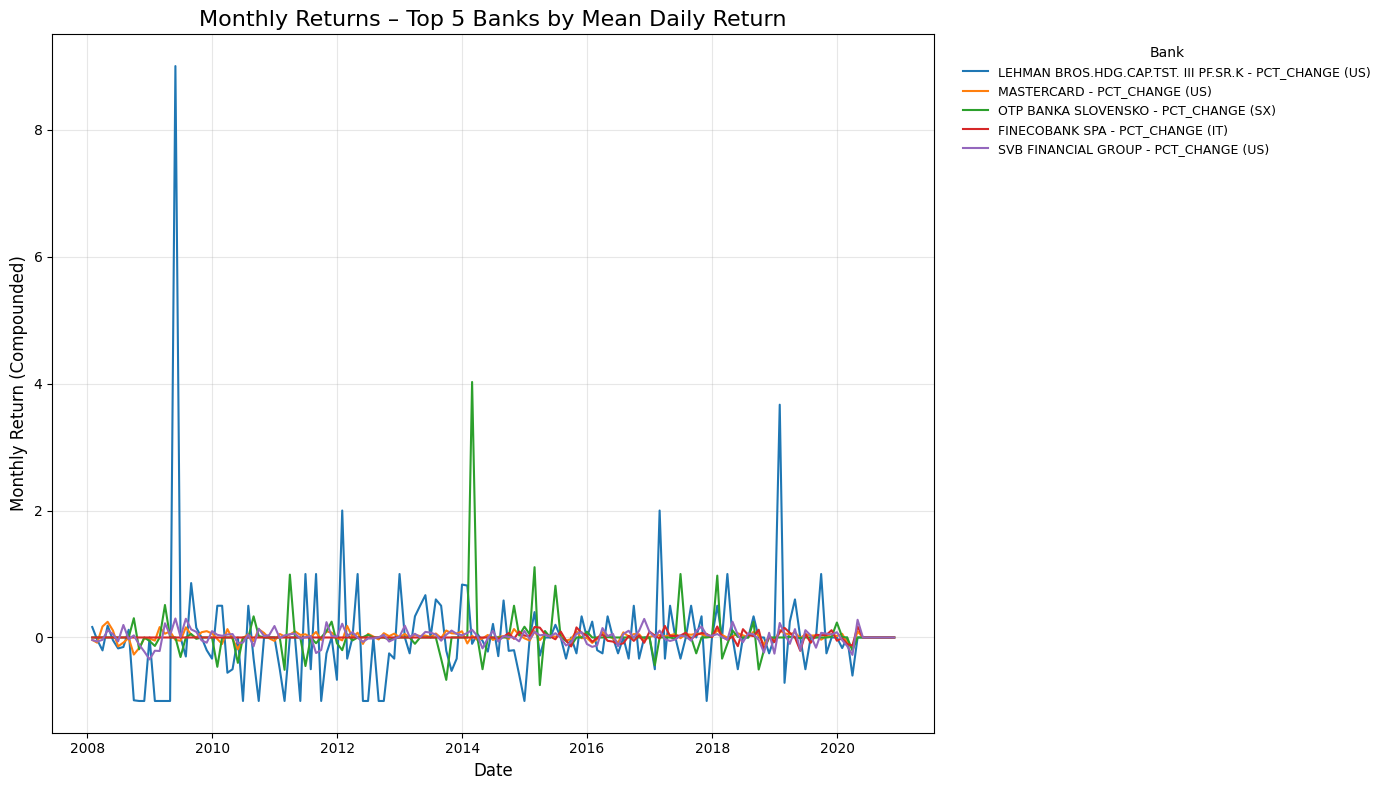

In [35]:
rdf = returns_df.copy()

if "date" in rdf.columns:
    rdf["date"] = pd.to_datetime(rdf["date"], errors="coerce")
    rdf = rdf.set_index("date")
else:
    rdf.index = pd.to_datetime(rdf.index, errors="coerce")

rdf = rdf[~rdf.index.isna()].sort_index()
rdf = rdf.select_dtypes(include="number")

# Compute mean returns and exclude 'MYBANK - PCT_CHANGE (NW)' if present
mean_returns = rdf.mean()
if "MYBANK - PCT_CHANGE (NW)" in mean_returns.index:
    mean_returns = mean_returns.drop("MYBANK - PCT_CHANGE (NW)")

# Find top 5 banks by mean daily return
top5_banks = mean_returns.sort_values(ascending=False).head(5).index
print("Top 5 Banks by Mean Return:", list(top5_banks))

# Monthly compounded returns
top5_returns = rdf[top5_banks]
monthly_returns = (1 + top5_returns).resample("M").prod() - 1

# Larger figure size
plt.figure(figsize=(14, 8))  # wider and taller plot

# Plot lines
for bank in top5_banks:
    plt.plot(monthly_returns.index, monthly_returns[bank], label=bank)

# Titles and labels
plt.title("Monthly Returns – Top 5 Banks by Mean Daily Return", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Monthly Return (Compounded)", fontsize=12)

# Smaller legend
plt.legend(
    title="Bank",
    title_fontsize=10,
    fontsize=9,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

# Grid and layout
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- **Lehman Brothers Holdings** exhibits **extreme volatility**, with multiple sharp spikes, **some exceeding 800%** (like the one in 2009), indicating severe market disruptions during the financial crisis period.

- **OTP Banka Slovensko** shows **occasional large positive jumps**, likely reflecting illiquidity or corrections in smaller regional markets.

- **Finecobank, SVB Financial Group and Mastercard** maintain **returns close to zero**, demonstrating **stable** and consistent performance over time.

Across the 2008–2020 period, there is **no persistent upward trend**, returns **fluctuate around zero**, reflecting a volatile post-crisis environment with intermittent shocks but limited long-term momentum.

### Avg Returns vs Volatility

In [36]:
return_cols = [col for col in returns_df.columns if 'PCT_CHANGE' in col.upper()]
temp_returns_df = returns_df[return_cols].copy()

# Compute summary statistics
summary_stats = pd.DataFrame({
    'Mean': temp_returns_df.mean(),
    'Std': temp_returns_df.std(),
    'Skewness': temp_returns_df.skew(),
    'Kurtosis': temp_returns_df.kurt()
})

# Sort by mean return
summary_stats = summary_stats.sort_values(by=['Mean', 'Std'], ascending=[False, False])

summary_stats.round(3).head(10)

,Mean,Std,Skewness,Kurtosis
MYBANK - PCT_CHANGE (NW),0.397,12.555,31.527,993.959
LEHMAN BROS.HDG.CAP.TST. III PF.SR.K - PCT_CHANGE (US),0.033,0.354,3.915,38.220
MASTERCARD - PCT_CHANGE (US),0.001,0.021,0.493,10.284
OTP BANKA SLOVENSKO - PCT_CHANGE (SX),0.001,0.061,8.861,221.467
FINECOBANK SPA - PCT_CHANGE (IT),0.001,0.020,-0.137,4.182
SVB FINANCIAL GROUP - PCT_CHANGE (US),0.001,0.027,0.015,8.485
AVANZA BANK HOLDING - PCT_CHANGE (SD),0.001,0.020,0.528,7.170
WESTERN ALL.BANCORP. - PCT_CHANGE (US),0.001,0.034,1.833,50.766
DISCOVER FINANCIAL SVS. - PCT_CHANGE (US),0.001,0.028,0.228,18.157
FIRST REPUBLIC BANK - PCT_CHANGE (US),0.001,0.017,-0.183,11.948


- **MyBank** stands out with an exceptionally **high mean return** but also the **largest volatility and extreme kurtosis**, indicating **rare but massive outliers**.

- **Lehman Brothers Holdings** ranks second by mean return but again shows **very high volatility** and **large skewness**, reflecting heavy asymmetry and crisis-period fluctuations.
  
- **Mastercard and FinecoBank** show **stable and consistent performance with low volatility** and near-zero skewness, suggesting balanced daily movements and limited extreme events.

Overall, there’s **a clear risk–return tradeoff**: banks with **higher returns also tend to show higher volatility**.

## Correlation Matrix for **Top 10 Banks**:
(with the **highest mean return** over the researched period)

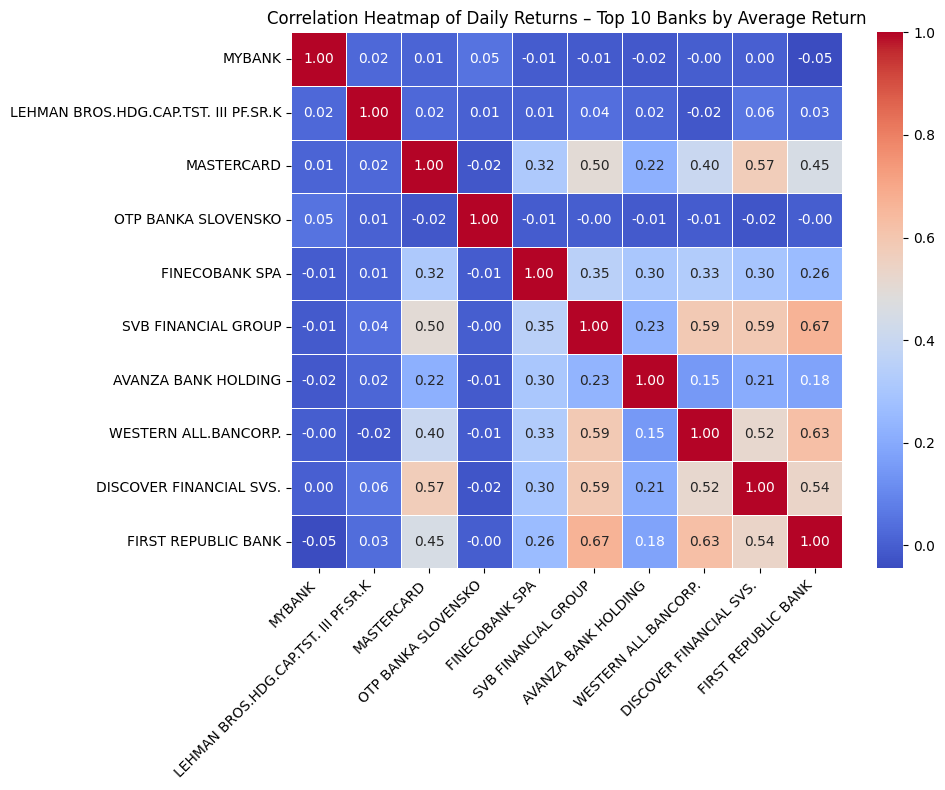

In [37]:
top10_banks = returns_df[return_cols].mean().sort_values(ascending=False).head(10).index
top10_returns = returns_df[top10_banks]

simplified_labels = [col.split('-')[0].strip() for col in top10_banks]
top10_returns.columns = simplified_labels

# --- Compute correlation matrix ---
corr_matrix = top10_returns.corr()

# --- Plot correlation heatmap ---
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Correlation Heatmap of Daily Returns – Top 10 Banks by Average Return")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- **MYBANK** and **Lehman Brothers Holdings** show **no meaningful correlation** with other banks, suggesting idiosyncratic or unrelated to broader market movements behavior.

- US-based banks such as **Mastercard, SVB Financial Group, Western Alliance Bancorp, Discover Financial Services, and First Republic Bank** show moderate **positive correlations**, indicating shared **exposure to U.S. financial market trends**.

Overall, the heatmap indicates that **cross-bank dependencies are limited**, with most relationships **below 0.5**, implying that these top performers **behave largely independently** and are driven by **bank-specific or regional factors** rather than a single global trend.

## Task #4: 
Estimate parameters of the CAPM (+)

– Use returns data and risk-free rates to estimate the CAPM parameters over a rolling window (or better, use the Fama-French 5 factors model)

– Be careful : the risk free-rate differs for different markets (e.g., US vs. EU)

**Fama-French 3 Factor Model** - no rolling window (with rolling window below):

In [38]:
bank_cols = [col for col in returns_df.columns if re.search(r'\((.*?)\)', col)]
bank_cols = [col for col in bank_cols if col.split('(')[-1].strip(')') in sheet_region_map]

# Filter to US & EU banks only
filtered_banks = [c for c in bank_cols if sheet_region_map[c.split('(')[-1].strip(')')] in ['US','EU']] + ['date']
returns_us_eu = returns_df[filtered_banks].copy()

print(f"Selected {len(filtered_banks)} banks for US/EU regions")
returns_us_eu.head()

Selected 167 banks for US/EU regions


,AAREAL BANK - PCT_CHANGE (BD),COMDIRECT BANK - PCT_CHANGE (BD),COMMERZBANK - PCT_CHANGE (BD),DT.PFANDBRIEFBANK - PCT_CHANGE (BD),PROCREDIT HOLDING - PCT_CHANGE (BD),UMWELTBANK - PCT_CHANGE (BD),ALLIANZ - PCT_CHANGE (BD),DEUTSCHE BANK - PCT_CHANGE (BD),BANQUE NATIONALE DE BELGIQUE - PCT_CHANGE (BG),KBC ANCORA - PCT_CHANGE (BG),KBC GROUP - PCT_CHANGE (BG),BANK OF CYPRUS HOLDING - PCT_CHANGE (CP),HELLENIC BANK - PCT_CHANGE (CP),LHV GROUP - PCT_CHANGE (EO),BBV.ARGENTARIA - PCT_CHANGE (ES),BANCO DE SABADELL - PCT_CHANGE (ES),BANCO SANTANDER - PCT_CHANGE (ES),BANKIA - PCT_CHANGE (ES),BANKINTER 'R' - PCT_CHANGE (ES),CAIXABANK - PCT_CHANGE (ES),LIBERBANK - PCT_CHANGE (ES),UNICAJA BANCO - PCT_CHANGE (ES),AKTIA BANK A - PCT_CHANGE (FN),NORDEA BANK - PCT_CHANGE (FN),BNP PARIBAS - PCT_CHANGE (FR),CRCAM NORD CCI - PCT_CHANGE (FR),CREDIT AGRICOLE - PCT_CHANGE (FR),CREDIT AGRICOLE BRIE PICARDIE - PCT_CHANGE (FR),CREDIT AGR.ILE DE FRANCE - PCT_CHANGE (FR),CREDIT FONCIER DE MONACO - PCT_CHANGE (FR),NATIXIS - PCT_CHANGE (FR),SOCIETE GENERALE - PCT_CHANGE (FR),ALPHA BANK - PCT_CHANGE (GR),ATTICA BANK - PCT_CHANGE (GR),BANK OF GREECE - PCT_CHANGE (GR),BANK OF PIRAEUS - PCT_CHANGE (GR),EUROBANK HOLDINGS - PCT_CHANGE (GR),NATIONAL BK.OF GREECE - PCT_CHANGE (GR),AIB GROUP - PCT_CHANGE (IR),BANK OF IRELAND GROUP - PCT_CHANGE (IR),PERMANENT TSB GHG. - PCT_CHANGE (IR),BANCA GENERALI - PCT_CHANGE (IT),BANCA MONTE DEI PASCHI - PCT_CHANGE (IT),BCA.PICCOLO CDT.VALTELL - PCT_CHANGE (IT),BANCA PPO.DI SONDRIO - PCT_CHANGE (IT),BANCO BPM - PCT_CHANGE (IT),BNC.DI DESIO E DELB. - PCT_CHANGE (IT),BPER BANCA - PCT_CHANGE (IT),CREDITO EMILIANO - PCT_CHANGE (IT),FINECOBANK SPA - PCT_CHANGE (IT),ILLIMITY BANK - PCT_CHANGE (IT),INTESA SANPAOLO - PCT_CHANGE (IT),UNICREDIT - PCT_CHANGE (IT),UNIONE DI BANCHE ITALIAN - PCT_CHANGE (IT),MEDIOBANCA BC.FIN - PCT_CHANGE (IT),SIAULIU BANKAS - PCT_CHANGE (LN),BANK OF VALLETTA - PCT_CHANGE (MA),FIMBANK - PCT_CHANGE (MA),HSBC BANK MALTA - PCT_CHANGE (MA),LOMBARD BANK - PCT_CHANGE (MA),ABN AMRO BANK - PCT_CHANGE (NL),ING GROEP - PCT_CHANGE (NL),NIBC HOLDING - PCT_CHANGE (NL),VAN LANSCHOT KEMPEN - PCT_CHANGE (NL),ASR NEDERLAND - PCT_CHANGE (NL),AEGON - PCT_CHANGE (NL),BANK FUR TIROL UND VBG. - PCT_CHANGE (OE),BAWAG GROUP - PCT_CHANGE (OE),BKS BANK - PCT_CHANGE (OE),ERSTE GROUP BANK - PCT_CHANGE (OE),OBERBANK - PCT_CHANGE (OE),OBERBANK PREF. - PCT_CHANGE (OE),RAIFFEISEN BANK INTL. - PCT_CHANGE (OE),VOLKSBANK VBG.PARTN. - PCT_CHANGE (OE),BANCO COMR.PORTUGUES 'R' - PCT_CHANGE (PT),NOVA LJUBLJANSKA BANK DD NPV - PCT_CHANGE (SJ),OTP BANKA SLOVENSKO - PCT_CHANGE (SX),OTP BANKA SLOVENSKO2 - PCT_CHANGE (SX),OTP BANKA SLOVENSKO3 - PCT_CHANGE (SX),TATRA BANKA - PCT_CHANGE (SX),TATRA BANKA 2 - PCT_CHANGE (SX),VSEOBECNA UVEROVA BANKA - PCT_CHANGE (SX),BANK OF AMERICA - PCT_CHANGE (US),TRUIST FINANCIAL - PCT_CHANGE (US),BOK FINL. - PCT_CHANGE (US),CIT GROUP - PCT_CHANGE (US),CITIZENS FINANCIAL GROUP - PCT_CHANGE (US),COMERICA - PCT_CHANGE (US),COMMERCE BCSH. - PCT_CHANGE (US),CREDICORP - PCT_CHANGE (US),CULLEN FO.BANKERS - PCT_CHANGE (US),DISCOVER FINANCIAL SVS. - PCT_CHANGE (US),EAST WEST BANCORP - PCT_CHANGE (US),FIFTH THIRD BANCORP - PCT_CHANGE (US),FIRST CTZN.BCSH.A - PCT_CHANGE (US),FIRST FINL.BKSH. - PCT_CHANGE (US),FIRST HORIZON NATIONAL - PCT_CHANGE (US),FIRST REPUBLIC BANK - PCT_CHANGE (US),FNB - PCT_CHANGE (US),HUNTINGTON BCSH. - PCT_CHANGE (US),IBERIABANK - PCT_CHANGE (US),KEYCORP - PCT_CHANGE (US),M&T BANK - PCT_CHANGE (US),NEW YORK COMMUNITY BANCORP - PCT_CHANGE (US),PACWEST BANCORP - PCT_CHANGE (US),PEOPLES UNITED FINANCIAL - PCT_CHANGE (US),PINNACLE FINANCIAL PTNS. - PCT_CHANGE (US),PNC FINL.SVS.GP. - PCT_CHANGE (US),POPULAR - PCT_CHANGE (US),PROSPERITY BCSH. - PCT_CHANGE (US),REGIONS FINL.NEW - PCT_CHANGE (US),SIGNATURE BANK - PCT_CHANGE (US),STERLING BANCORP - PCT_CHANGE (US),SVB FINANCIAL GROUP - PCT_CHANGE (US),SYNOVUS FINANCIAL - PCT_CHANGE (US),TCF FINANCIAL - PCT_CHANGE (US),TFS FINANCIAL - PCT_CHANGE (US),TRISTATE CAPITAL

We need to differentiate the factors incorporated into the regression, depending on the **region of the bank - EU or US**:

In [39]:
cols_to_add_US = [
    'Mkt - RF_US', 'SMB_US', 'HML_US', 'RF_US'
]

ff_factors_US = df[cols_to_add_US]
ff_factors_US.columns = ['Mkt_RF', 'SMB', 'HML', 'RF']

cols_to_add_EU = [
    'Mkt - RF_EU', 'SMB_EU', 'HML_EU', 'RF_EU'
]
ff_factors_EU = df[cols_to_add_EU]
ff_factors_EU.columns = ['Mkt_RF', 'SMB', 'HML', 'RF']

In [40]:
returns_us_eu.set_index('date', inplace = True)

In [41]:
returns_us_eu.head()

,AAREAL BANK - PCT_CHANGE (BD),COMDIRECT BANK - PCT_CHANGE (BD),COMMERZBANK - PCT_CHANGE (BD),DT.PFANDBRIEFBANK - PCT_CHANGE (BD),PROCREDIT HOLDING - PCT_CHANGE (BD),UMWELTBANK - PCT_CHANGE (BD),ALLIANZ - PCT_CHANGE (BD),DEUTSCHE BANK - PCT_CHANGE (BD),BANQUE NATIONALE DE BELGIQUE - PCT_CHANGE (BG),KBC ANCORA - PCT_CHANGE (BG),KBC GROUP - PCT_CHANGE (BG),BANK OF CYPRUS HOLDING - PCT_CHANGE (CP),HELLENIC BANK - PCT_CHANGE (CP),LHV GROUP - PCT_CHANGE (EO),BBV.ARGENTARIA - PCT_CHANGE (ES),BANCO DE SABADELL - PCT_CHANGE (ES),BANCO SANTANDER - PCT_CHANGE (ES),BANKIA - PCT_CHANGE (ES),BANKINTER 'R' - PCT_CHANGE (ES),CAIXABANK - PCT_CHANGE (ES),LIBERBANK - PCT_CHANGE (ES),UNICAJA BANCO - PCT_CHANGE (ES),AKTIA BANK A - PCT_CHANGE (FN),NORDEA BANK - PCT_CHANGE (FN),BNP PARIBAS - PCT_CHANGE (FR),CRCAM NORD CCI - PCT_CHANGE (FR),CREDIT AGRICOLE - PCT_CHANGE (FR),CREDIT AGRICOLE BRIE PICARDIE - PCT_CHANGE (FR),CREDIT AGR.ILE DE FRANCE - PCT_CHANGE (FR),CREDIT FONCIER DE MONACO - PCT_CHANGE (FR),NATIXIS - PCT_CHANGE (FR),SOCIETE GENERALE - PCT_CHANGE (FR),ALPHA BANK - PCT_CHANGE (GR),ATTICA BANK - PCT_CHANGE (GR),BANK OF GREECE - PCT_CHANGE (GR),BANK OF PIRAEUS - PCT_CHANGE (GR),EUROBANK HOLDINGS - PCT_CHANGE (GR),NATIONAL BK.OF GREECE - PCT_CHANGE (GR),AIB GROUP - PCT_CHANGE (IR),BANK OF IRELAND GROUP - PCT_CHANGE (IR),PERMANENT TSB GHG. - PCT_CHANGE (IR),BANCA GENERALI - PCT_CHANGE (IT),BANCA MONTE DEI PASCHI - PCT_CHANGE (IT),BCA.PICCOLO CDT.VALTELL - PCT_CHANGE (IT),BANCA PPO.DI SONDRIO - PCT_CHANGE (IT),BANCO BPM - PCT_CHANGE (IT),BNC.DI DESIO E DELB. - PCT_CHANGE (IT),BPER BANCA - PCT_CHANGE (IT),CREDITO EMILIANO - PCT_CHANGE (IT),FINECOBANK SPA - PCT_CHANGE (IT),ILLIMITY BANK - PCT_CHANGE (IT),INTESA SANPAOLO - PCT_CHANGE (IT),UNICREDIT - PCT_CHANGE (IT),UNIONE DI BANCHE ITALIAN - PCT_CHANGE (IT),MEDIOBANCA BC.FIN - PCT_CHANGE (IT),SIAULIU BANKAS - PCT_CHANGE (LN),BANK OF VALLETTA - PCT_CHANGE (MA),FIMBANK - PCT_CHANGE (MA),HSBC BANK MALTA - PCT_CHANGE (MA),LOMBARD BANK - PCT_CHANGE (MA),ABN AMRO BANK - PCT_CHANGE (NL),ING GROEP - PCT_CHANGE (NL),NIBC HOLDING - PCT_CHANGE (NL),VAN LANSCHOT KEMPEN - PCT_CHANGE (NL),ASR NEDERLAND - PCT_CHANGE (NL),AEGON - PCT_CHANGE (NL),BANK FUR TIROL UND VBG. - PCT_CHANGE (OE),BAWAG GROUP - PCT_CHANGE (OE),BKS BANK - PCT_CHANGE (OE),ERSTE GROUP BANK - PCT_CHANGE (OE),OBERBANK - PCT_CHANGE (OE),OBERBANK PREF. - PCT_CHANGE (OE),RAIFFEISEN BANK INTL. - PCT_CHANGE (OE),VOLKSBANK VBG.PARTN. - PCT_CHANGE (OE),BANCO COMR.PORTUGUES 'R' - PCT_CHANGE (PT),NOVA LJUBLJANSKA BANK DD NPV - PCT_CHANGE (SJ),OTP BANKA SLOVENSKO - PCT_CHANGE (SX),OTP BANKA SLOVENSKO2 - PCT_CHANGE (SX),OTP BANKA SLOVENSKO3 - PCT_CHANGE (SX),TATRA BANKA - PCT_CHANGE (SX),TATRA BANKA 2 - PCT_CHANGE (SX),VSEOBECNA UVEROVA BANKA - PCT_CHANGE (SX),BANK OF AMERICA - PCT_CHANGE (US),TRUIST FINANCIAL - PCT_CHANGE (US),BOK FINL. - PCT_CHANGE (US),CIT GROUP - PCT_CHANGE (US),CITIZENS FINANCIAL GROUP - PCT_CHANGE (US),COMERICA - PCT_CHANGE (US),COMMERCE BCSH. - PCT_CHANGE (US),CREDICORP - PCT_CHANGE (US),CULLEN FO.BANKERS - PCT_CHANGE (US),DISCOVER FINANCIAL SVS. - PCT_CHANGE (US),EAST WEST BANCORP - PCT_CHANGE (US),FIFTH THIRD BANCORP - PCT_CHANGE (US),FIRST CTZN.BCSH.A - PCT_CHANGE (US),FIRST FINL.BKSH. - PCT_CHANGE (US),FIRST HORIZON NATIONAL - PCT_CHANGE (US),FIRST REPUBLIC BANK - PCT_CHANGE (US),FNB - PCT_CHANGE (US),HUNTINGTON BCSH. - PCT_CHANGE (US),IBERIABANK - PCT_CHANGE (US),KEYCORP - PCT_CHANGE (US),M&T BANK - PCT_CHANGE (US),NEW YORK COMMUNITY BANCORP - PCT_CHANGE (US),PACWEST BANCORP - PCT_CHANGE (US),PEOPLES UNITED FINANCIAL - PCT_CHANGE (US),PINNACLE FINANCIAL PTNS. - PCT_CHANGE (US),PNC FINL.SVS.GP. - PCT_CHANGE (US),POPULAR - PCT_CHANGE (US),PROSPERITY BCSH. - PCT_CHANGE (US),REGIONS FINL.NEW - PCT_CHANGE (US),SIGNATURE BANK - PCT_CHANGE (US),STERLING BANCORP - PCT_CHANGE (US),SVB FINANCIAL GROUP - PCT_CHANGE (US),SYNOVUS FINANCIAL - PCT_CHANGE (US),TCF FINANCIAL - PCT_CHANGE (US),TFS FINANCIAL - PCT_CHANGE (US),TRISTATE CAPITAL

In [42]:
def run_ff_regression(bank_returns: pd.Series, factors: pd.DataFrame, min_obs: int = 60):
    """
    (R_i - RF) = alpha + b_m*Mkt_RF + b_s*SMB + b_h*HML + eps
    `min_obs` is ignored; regression runs whenever there is at least 1 row after alignment.
    """
    factor_candidates = ["Mkt_RF", "SMB", "HML"]
    Xcols = [c for c in factor_candidates if c in factors.columns]
    need = Xcols + (["RF"] if "RF" in factors.columns else [])

    # align and drop NaNs
    data = pd.concat([bank_returns.rename("Ri"), factors[need]], axis=1, join="inner").dropna()
    if data.empty:
        return None, {"n_obs": 0, "used_factors": Xcols}

    # dependent: excess return if RF is available
    y = data["Ri"] - data["RF"] if "RF" in data.columns else data["Ri"]

    # regress on available factors (const only if none)
    X = sm.add_constant(data[Xcols]) if Xcols else sm.add_constant(pd.DataFrame(index=data.index))

    model = sm.OLS(y, X).fit()
    return model, {"n_obs": len(data), "used_factors": Xcols}

In [43]:
models = {}
rows = []

for bank in filtered_banks:
    code   = bank.split('(')[-1].strip(')')
    region = sheet_region_map.get(code)
    if region not in ("US", "EU"):
        continue

    factors = ff_factors_US if region == "US" else ff_factors_EU

    model, info = run_ff_regression(returns_us_eu[bank], factors[1:], min_obs=60)
    if model is None:
        # Not enough overlapping observations
        print(f"Skipping {bank}: n={info['n_obs']}, used={info['used_factors']}")
        continue

    models[bank] = model
    coef = model.params.to_dict()
    pvals = model.pvalues.to_dict()

    def sig_marker(p):
        if p < 0.01: return "***"  # highly significant
        elif p < 0.05: return "**"
        elif p < 0.1: return "*"
        else: return ""

    rows.append({
        "Bank": bank,
        "Region": region,
        "n_obs": info["n_obs"],
        "Alpha":  coef.get("const", np.nan),
        "Alpha_sig": sig_marker(pvals.get("const", np.nan)),
        "Beta_Mkt": coef.get("Mkt_RF", np.nan),
        "Beta_Mkt_sig": sig_marker(pvals.get("Mkt_RF", np.nan)),
        "Beta_SMB": coef.get("SMB", np.nan),
        "Beta_SMB_sig": sig_marker(pvals.get("SMB", np.nan)),
        "Beta_HML": coef.get("HML", np.nan),
        "Beta_HML_sig": sig_marker(pvals.get("HML", np.nan))
    })

In [44]:
ff5_results = pd.DataFrame(rows)
ff5_results.head(10)

,Bank,Region,n_obs,Alpha,Alpha_sig,Beta_Mkt,Beta_Mkt_sig,Beta_SMB,Beta_SMB_sig,Beta_HML,Beta_HML_sig
0,AAREAL BANK - PCT_CHANGE (BD),EU,3215,-0.002021,***,0.013077,***,0.001204,,0.010991,***
1,COMDIRECT BANK - PCT_CHANGE (BD),EU,3215,-0.002131,***,0.005669,***,0.001216,*,-0.000258,
2,COMMERZBANK - PCT_CHANGE (BD),EU,3215,-0.002893,***,0.010545,***,-0.001584,,0.018060,***
3,DT.PFANDBRIEFBANK - PCT_CHANGE (BD),EU,1249,-0.004478,***,0.010307,***,0.004567,***,0.009994,***
4,PROCREDIT HOLDING - PCT_CHANGE (BD),EU,873,-0.007201,***,0.004699,***,0.005321,**,0.003538,*
5,UMWELTBANK - PCT_CHANGE (BD),EU,3215,-0.001781,***,0.004173,***,0.006268,***,-0.001149,
6,ALLIANZ - PCT_CHANGE (BD),EU,3215,-0.002149,***,0.009058,***,-0.005905,***,0.003637,***
7,DEUTSCHE BANK - PCT_CHANGE (BD),EU,3215,-0.002584,***,0.009087,***,-0.008916,***,0.014230,***
8,BANQUE NATIONALE DE BELGIQUE - PCT_CHANGE (BG),EU,3215,-0.002440,***,0.003557,***,0.003066,***,0.000316,
9,KBC ANCORA - PCT_CHANGE (BG),EU,3215,-0.001829,***,0.013650,***,0.001829,,0.019102,***


In [45]:
sorted_df = ff5_results.sort_values(by="Beta_Mkt", ascending=False)

# Select top and bottom 10
top10 = sorted_df.head(10)
bottom10 = sorted_df.tail(10)

In [46]:
def beta_color(sig):
    if sig == "***":
        return "#08306B"  # dark blue (highly significant)
    elif sig == "**":
        return "#2171B5"  # medium blue
    elif sig == "*":
        return "#6BAED6"  # light blue
    else:
        return "#CCCCCC"  # grey for not significant

In [47]:
# Assign colors
top10_colors = top10["Beta_Mkt_sig"].apply(beta_color)
bottom10_colors = bottom10["Beta_Mkt_sig"].apply(beta_color)

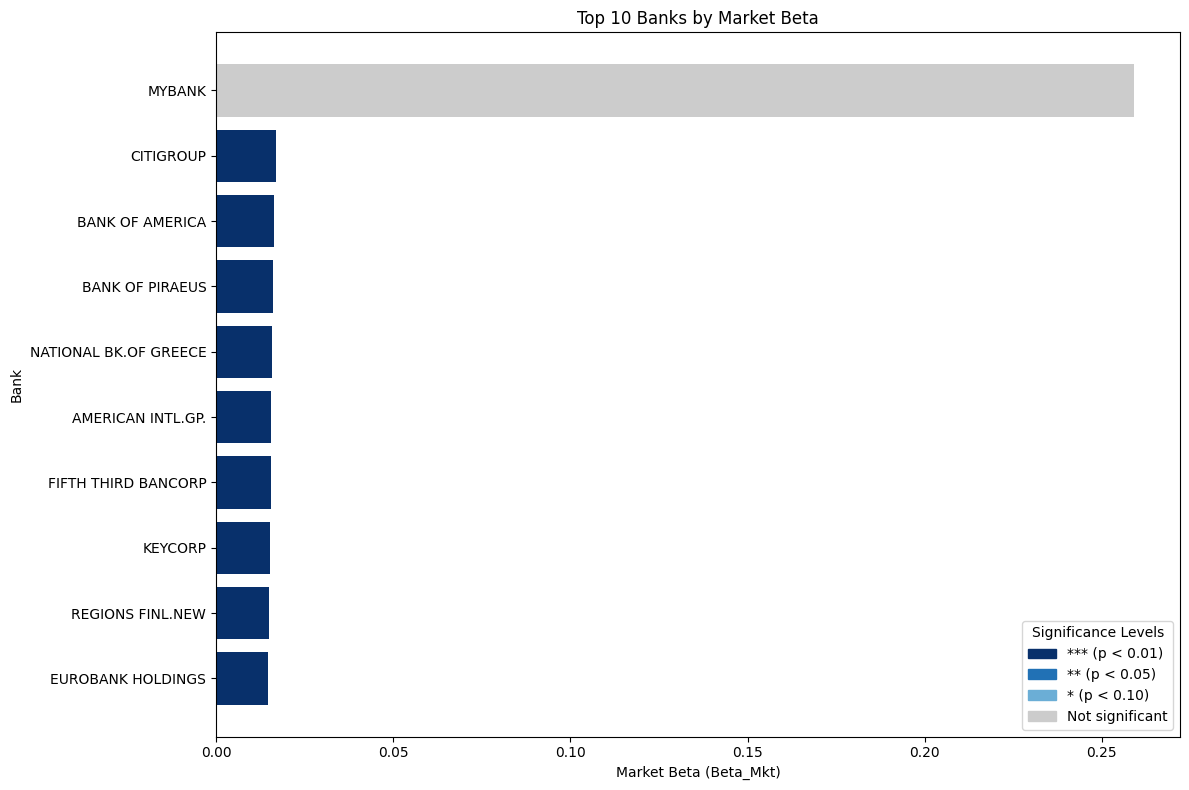

In [48]:
# --- Plot Top 10 ---
plt.figure(figsize=(12, 8))
plt.barh(top10["Bank"].str.split(" -").str[0], top10["Beta_Mkt"], color=top10_colors)

plt.xlabel("Market Beta (Beta_Mkt)")
plt.ylabel("Bank")
plt.title("Top 10 Banks by Market Beta")
plt.gca().invert_yaxis()

# --- Add legend manually ---
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color="#08306B", label="*** (p < 0.01)"),
    mpatches.Patch(color="#2171B5", label="** (p < 0.05)"),
    mpatches.Patch(color="#6BAED6", label="* (p < 0.10)"),
    mpatches.Patch(color="#CCCCCC", label="Not significant"),
]
plt.legend(handles=legend_patches, title="Significance Levels", loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

- **Statistical Significance:**
  
The coefficient is **statistically insignificant** for MyBank, suggesting that its performance may be driven more by **idiosyncratic or firm-specific factors** than by broad market trends.

- **Clustered majority:**
  
Most banks have betas around 0.01–0.02, showing **very low sensitivity to market movements**.

- **Regional pattern:**
  
Several European banks appear in the Top 10, highlighting **varied market exposure even within the EU region**.

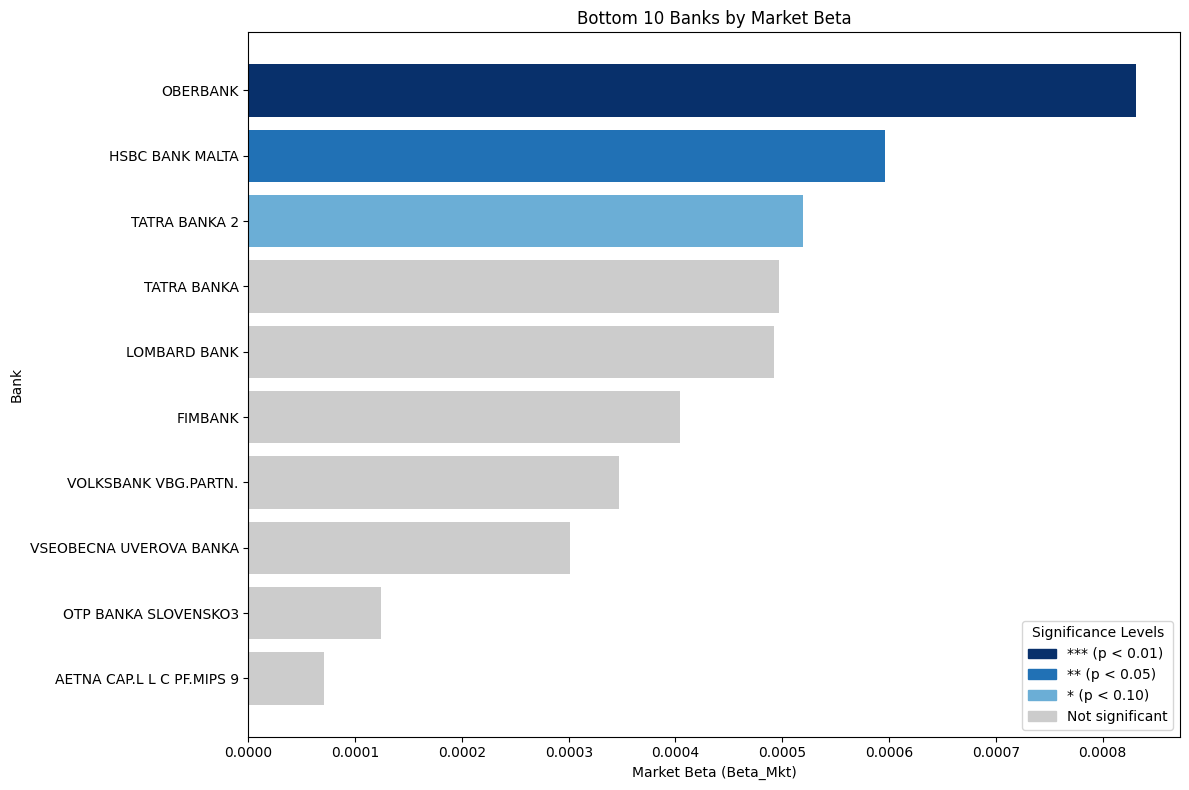

In [49]:
# --- Plot Bottom 10 ---
plt.figure(figsize=(12, 8))
plt.barh(bottom10["Bank"].str.split(" -").str[0], bottom10["Beta_Mkt"], color=bottom10_colors)
plt.xlabel("Market Beta (Beta_Mkt)")
plt.ylabel("Bank")
plt.title("Bottom 10 Banks by Market Beta")
plt.gca().invert_yaxis()

# --- Add legend manually ---
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color="#08306B", label="*** (p < 0.01)"),
    mpatches.Patch(color="#2171B5", label="** (p < 0.05)"),
    mpatches.Patch(color="#6BAED6", label="* (p < 0.10)"),
    mpatches.Patch(color="#CCCCCC", label="Not significant"),
]
plt.legend(handles=legend_patches, title="Significance Levels", loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

- **Statistical significance:**
  
Most coefficients are **statistically insignificant**, meaning their link to market movements is not robust. Only a few show weak to moderate significance.

- **Near-zero or negative betas:**

Several banks show betas close to zero or slightly negative, implying **minimal or inverse correlation with market movements**.

- **Low market sensitivity**:

These institutions are largely behaving more like **locally driven banks**.

In [50]:
# --- Split by region ---
eu_df = ff5_results[ff5_results["Region"] == "EU"]
us_df = ff5_results[ff5_results["Region"] == "US"]

# --- Sort and select top/bottom 5 for each ---
eu_top5 = eu_df.sort_values(by="Beta_Mkt", ascending=False).head(5)
eu_bottom5 = eu_df.sort_values(by="Beta_Mkt", ascending=True).head(5)
us_top5 = us_df.sort_values(by="Beta_Mkt", ascending=False).head(5)
us_bottom5 = us_df.sort_values(by="Beta_Mkt", ascending=True).head(5)

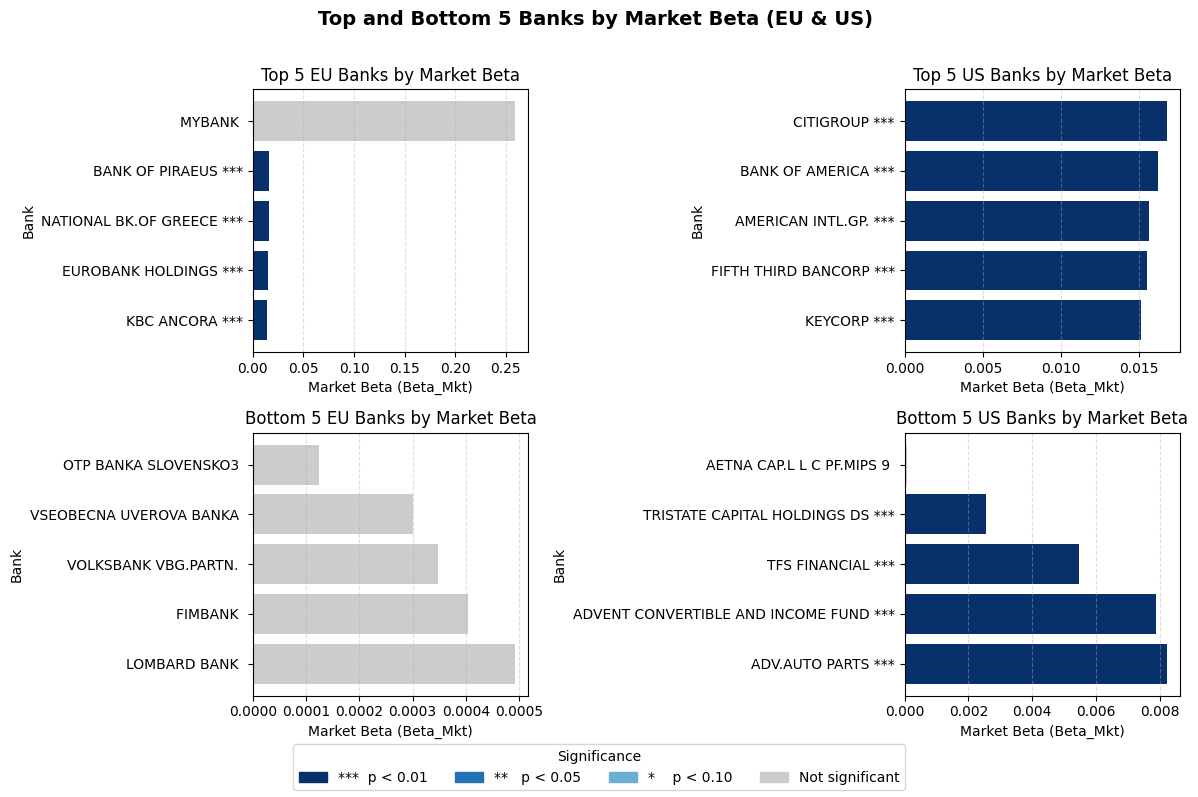

In [51]:
# --- Color + star helpers ---
def beta_color(sig):
    if sig == "***": return "#08306B"   # p<0.01
    if sig == "**":  return "#2171B5"   # p<0.05
    if sig == "*":   return "#6BAED6"   # p<0.10
    return "#CCCCCC"                     # not significant

def add_stars(s):  # pretty-print stars (or blank if NaN)
    return s if s in ("*", "**", "***") else ""

# Build labels (bank name + stars) and colors for each panel
eu_top5_labels   = eu_top5["Bank"].str.split(" -").str[0] + " " + eu_top5["Beta_Mkt_sig"].map(add_stars).fillna("")
eu_bottom5_labels= eu_bottom5["Bank"].str.split(" -").str[0] + " " + eu_bottom5["Beta_Mkt_sig"].map(add_stars).fillna("")
us_top5_labels   = us_top5["Bank"].str.split(" -").str[0] + " " + us_top5["Beta_Mkt_sig"].map(add_stars).fillna("")
us_bottom5_labels= us_bottom5["Bank"].str.split(" -").str[0] + " " + us_bottom5["Beta_Mkt_sig"].map(add_stars).fillna("")

eu_top5_colors    = eu_top5["Beta_Mkt_sig"].map(beta_color).fillna("#CCCCCC")
eu_bottom5_colors = eu_bottom5["Beta_Mkt_sig"].map(beta_color).fillna("#CCCCCC")
us_top5_colors    = us_top5["Beta_Mkt_sig"].map(beta_color).fillna("#CCCCCC")
us_bottom5_colors = us_bottom5["Beta_Mkt_sig"].map(beta_color).fillna("#CCCCCC")

# --- Create 2x2 subplot grid ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Top and Bottom 5 Banks by Market Beta (EU & US)", fontsize=14, fontweight='bold')

# Top 5 EU
axes[0, 0].barh(eu_top5_labels, eu_top5["Beta_Mkt"], color=eu_top5_colors)
axes[0, 0].set_title("Top 5 EU Banks by Market Beta")
axes[0, 0].invert_yaxis()

# Bottom 5 EU
axes[1, 0].barh(eu_bottom5_labels, eu_bottom5["Beta_Mkt"], color=eu_bottom5_colors)
axes[1, 0].set_title("Bottom 5 EU Banks by Market Beta")
axes[1, 0].invert_yaxis()

# Top 5 US
axes[0, 1].barh(us_top5_labels, us_top5["Beta_Mkt"], color=us_top5_colors)
axes[0, 1].set_title("Top 5 US Banks by Market Beta")
axes[0, 1].invert_yaxis()

# Bottom 5 US
axes[1, 1].barh(us_bottom5_labels, us_bottom5["Beta_Mkt"], color=us_bottom5_colors)
axes[1, 1].set_title("Bottom 5 US Banks by Market Beta")
axes[1, 1].invert_yaxis()

# --- Common styling ---
for ax in axes.flat:
    ax.set_xlabel("Market Beta (Beta_Mkt)")
    ax.set_ylabel("Bank")
    ax.grid(axis='x', linestyle='--', alpha=0.4)

# --- Significance legend ---
legend_patches = [
    mpatches.Patch(color="#08306B", label="***  p < 0.01"),
    mpatches.Patch(color="#2171B5", label="**   p < 0.05"),
    mpatches.Patch(color="#6BAED6", label="*    p < 0.10"),
    mpatches.Patch(color="#CCCCCC", label="Not significant"),
]
fig.legend(handles=legend_patches, title="Significance", loc="lower center", ncol=4, frameon=True)

plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

**EU banks** have some market betas close to zero, with several being statistically insignificant.
This indicates **weak or negligible exposure to overall market movements**, suggesting their returns are largely driven by **idiosyncratic or regional factors**.

**US** banks show narrower, more **uniform betas**, nearly **all statistically significant**, indicating more exposure to systematic market risk (although still close to 0).

**EU banks** display greater **idiosyncratic** variation, while **US banks** move more in line with **market trends**, reflecting systematic risk dominance in the US and diverse sensitivities in Europe.

**Fama-French 3 Factor Model** - **with rolling window:**

In [52]:
def run_ff_regression_rolling(bank_returns: pd.Series, factors: pd.DataFrame, window: int = 60):
    """
    Runs a rolling-window Fama-French regression:
    (R_i - RF) = alpha + b_m*Mkt_RF + b_s*SMB + b_h*HML + eps
    """
    factor_candidates = ["Mkt_RF", "SMB", "HML"]
    Xcols = [c for c in factor_candidates if c in factors.columns]
    need = Xcols + (["RF"] if "RF" in factors.columns else [])

    # align and drop NaNs
    data = pd.concat([bank_returns.rename("Ri"), factors[need]], axis=1, join="inner").dropna()
    if data.empty:
        return None

    # dependent variable
    y = data["Ri"] - data["RF"] if "RF" in data.columns else data["Ri"]

    # store betas through time
    betas = pd.DataFrame(index=data.index, columns=["Alpha"] + Xcols)

    # rolling window regression
    for end in range(window, len(data)):
        sub = data.iloc[end-window:end]
        y_sub = sub["Ri"] - sub["RF"] if "RF" in sub.columns else sub["Ri"]
        X_sub = sm.add_constant(sub[Xcols])
        model = sm.OLS(y_sub, X_sub).fit()
        betas.loc[data.index[end], ["Alpha"] + Xcols] = model.params.values

    return betas.dropna()

For **Top 10 banks** in terms of average returns over the researched period:

In [53]:
# --- Run rolling regression for top 10 banks ---
rolling_results = {}

for bank in top10_banks:
    # Determine region for correct factor set
    code = bank.split('(')[-1].strip(')')
    region = sheet_region_map.get(code)
    factors = ff_factors_US if region == "US" else ff_factors_EU

    print(f"Running rolling regression for {bank} ({region})...")
    result = run_ff_regression_rolling(returns_us_eu[bank], factors, window=60)
    if result is not None:
        rolling_results[bank] = result
    else:
        print(f"⚠️ Skipping {bank}: not enough data for rolling window")

Running rolling regression for MYBANK - PCT_CHANGE (NW) (EU)...
Running rolling regression for LEHMAN BROS.HDG.CAP.TST. III PF.SR.K - PCT_CHANGE (US) (US)...
Running rolling regression for MASTERCARD - PCT_CHANGE (US) (US)...
Running rolling regression for OTP BANKA SLOVENSKO - PCT_CHANGE (SX) (EU)...
Running rolling regression for FINECOBANK SPA - PCT_CHANGE (IT) (EU)...
Running rolling regression for SVB FINANCIAL GROUP - PCT_CHANGE (US) (US)...
Running rolling regression for AVANZA BANK HOLDING - PCT_CHANGE (SD) (EU)...
Running rolling regression for WESTERN ALL.BANCORP. - PCT_CHANGE (US) (US)...
Running rolling regression for DISCOVER FINANCIAL SVS. - PCT_CHANGE (US) (US)...
Running rolling regression for FIRST REPUBLIC BANK - PCT_CHANGE (US) (US)...


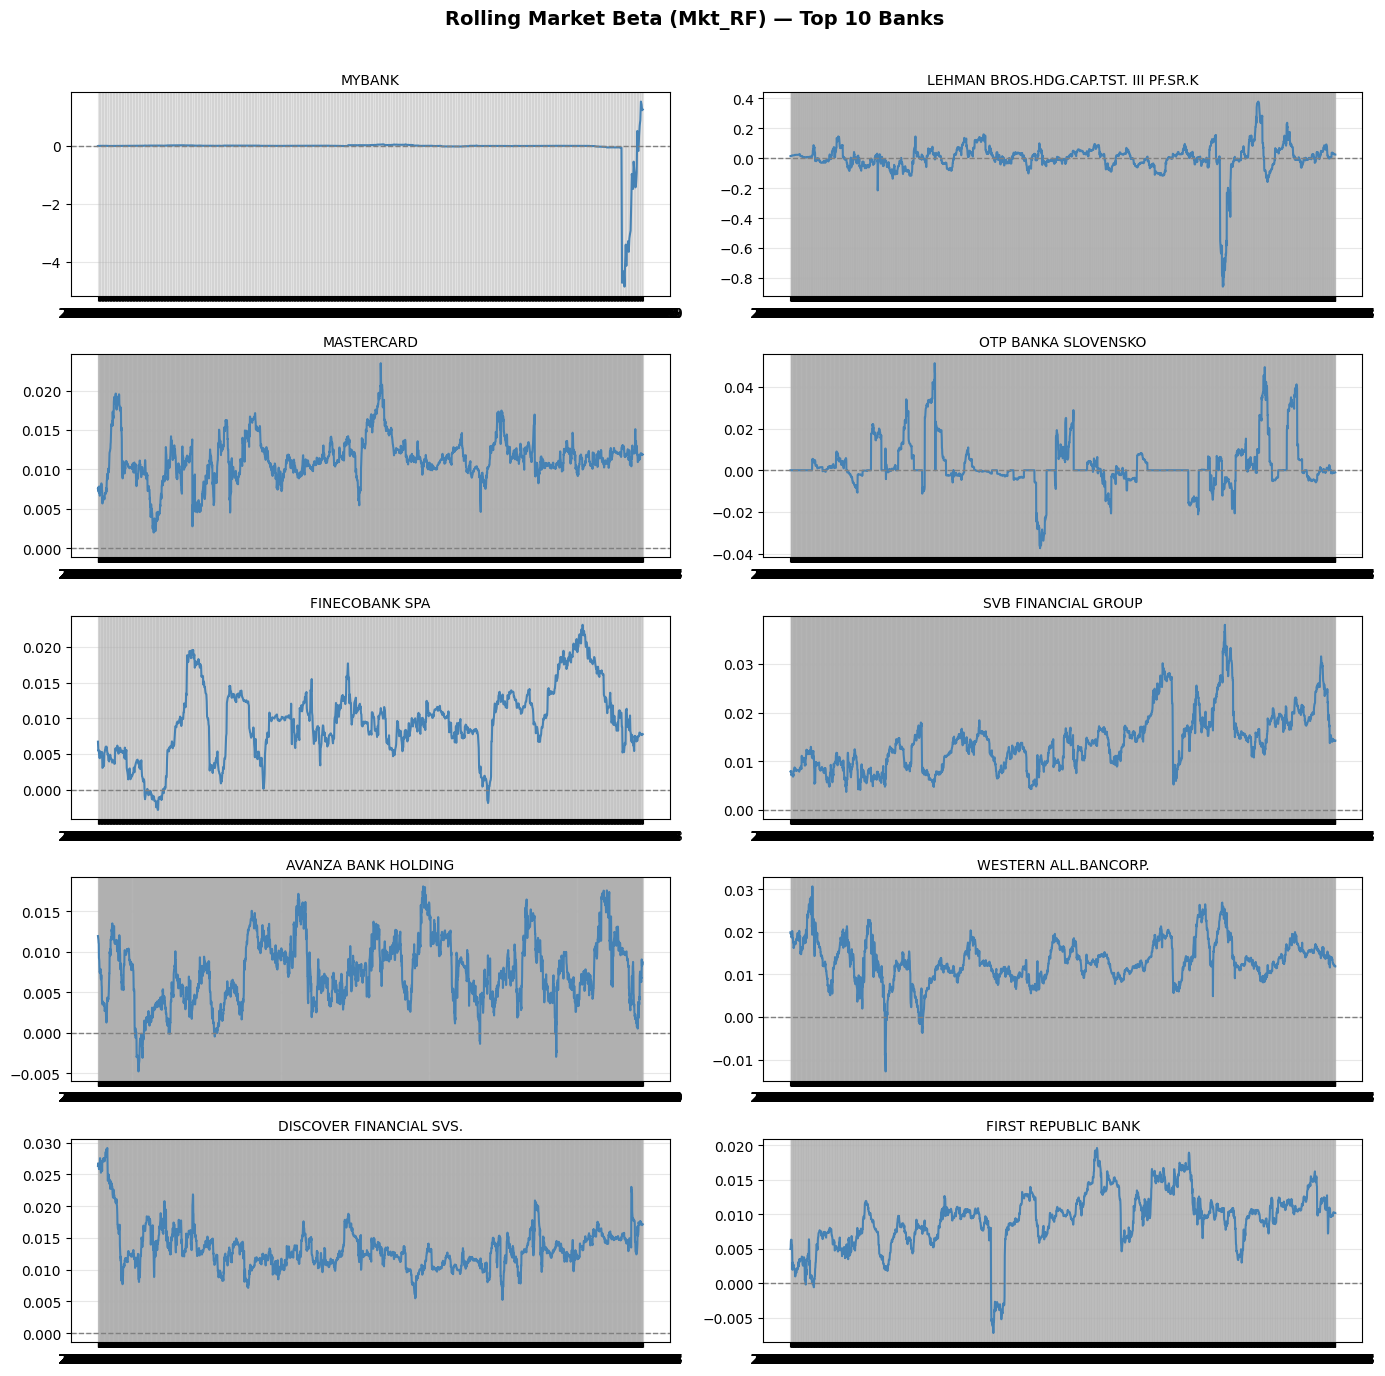

In [54]:
banks_to_plot = [b for b in top10_banks if b in rolling_results]

# Create 5x2 subplot grid
fig, axes = plt.subplots(5, 2, figsize=(14, 14))
axes = axes.flatten()

for i, bank in enumerate(banks_to_plot[:10]):
    ax = axes[i]
    beta_series = rolling_results[bank]["Mkt_RF"].dropna()
    ax.plot(beta_series, label="Rolling Beta", color="steelblue")
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(bank.split(" -")[0], fontsize=10)
    ax.grid(alpha=0.3)

# Hide any unused subplots
for j in range(len(banks_to_plot), len(axes)):
    axes[j].axis("off")

fig.suptitle("Rolling Market Beta (Mkt_RF) — Top 10 Banks", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

**US banks** show, in general, **more stable and persistent** exposure to market risk, while **EU banks** display lower or less reliable betas, reflecting **greater idiosyncratic influence and weaker market integration.**

## Task #5:
Compute CARs and merge Sigwatch + Datastream data (++)

– Merge with the Sigwatch data to define the event dates (a event is a positive/negative campaign)

– Compute the CARs around the event date (-10, +10 is the baseline, but you may want to try other time periods)

Initially, the match between the Sigwatch NGO campaign data and the Datastream bank returns dataset was very limited, only about 15–20 firms overlapped, and nearly 80% of events were unmatched. The issue was that many firm names in the two datasets followed different naming conventions (e.g., “Allied Irish Banks” in Sigwatch versus “AIB Group” in Datastream), and event dates from Sigwatch often fell on non-trading days such as weekends or holidays. To address this, we redesigned the merge pipeline to use a high-precision name-normalization procedure combined with a vetted alias dictionary capturing only true corporate rebrands or mergers (for instance, “Royal Bank of Scotland” → “NatWest Group”). We also introduced date snapping, aligning Sigwatch event dates to the nearest available trading day (±3 days). Finally, we applied a non-bank blacklist to exclude insurers and asset managers that are not part of our returns universe. These improvements increased the number of correctly matched banks from roughly 15–20 to 28, and the number of usable events from about 1,300 to over 1,400, while maintaining strict control against false matches such as Assicurazioni Generali being incorrectly linked to Banca Generali.

We did not keep the previous code and checks to not make this notebook too long. Below there is the final improved matching.

In [55]:
# ---------- CONFIG ----------
BLACKLIST_NONBANKS = True   # set False to keep everything from Sigwatch
DATE_SNAP_TOL_DAYS = 3      # snap event dates to nearest trading day within ±tol
# --- sentiment config ---
USE_SENTIMENT = True           # flip False to ignore sentiment
SENT_POS_CUTOFF = 1            # >= +1 -> "good"
SENT_NEG_CUTOFF = -1           # <= -1 -> "bad"

# Strict, vetted aliases (same listed entity only)
ALIAS_SAFE = {
    # rebrands / mergers (SAME entity)
    'allied irish banks': 'AIB Group',
    'royal bank of scotland': 'NatWest Group',
    'royal bank of scotland group': 'NatWest Group',
    'banco espanol de credito': 'Banco Santander',
    'banco popolare': 'Banco BPM',
    'banco popolare sc': 'Banco BPM',
    'lloyds banking': 'Lloyds Banking Group',
    'lloyds bank': 'Lloyds Banking Group',
    'abn amro': 'ABN AMRO Bank',
    'bnp paribas sa': 'BNP Paribas',
    'credit agricole sa': 'Credit Agricole',
    'intesa san paolo': 'Intesa Sanpaolo',
    'unicredito italiano': 'UniCredit',
    'bank of new york': 'Bank of New York Mellon',
    'commerzbank ag': 'Commerzbank',
    'deutsche bank ag': 'Deutsche Bank',
}

# Optional: very conservative non-bank blacklist to avoid false matches
NONBANK_REGEX = (
    r'(?:insurance|insurer|assicurazioni|aetna|allstate|aon|metlife|prudential|aviva|zurich|axa|manulife|reinsurance|reit)'
)

Preparing the dataset:

In [56]:
# ---------- HELPERS ----------
def normalize_name(s: str) -> str:
    if pd.isna(s): return ""
    s = s.lower().replace("&", "and")
    return re.sub(r"[^a-z0-9]+", " ", s).strip()

def snap_to_trading_day(dt: pd.Timestamp, trading_days: pd.Series, tol_days: int) -> pd.Timestamp:
    if pd.isna(dt): 
        return pd.NaT
    i = trading_days.searchsorted(dt)
    cands = []
    for j in (i-1, i, i+1):
        if 0 <= j < len(trading_days):
            cands.append((abs((trading_days.iloc[j] - dt).days), trading_days.iloc[j]))
    if not cands:
        return pd.NaT
    d, best = min(cands, key=lambda x: x[0])
    return best if d <= tol_days else pd.NaT

# ---------- 1) RETURNS SIDE ----------
# `returns_df` is your wide frame with PCT_CHANGE columns and a Date index or 'date' column
ret_wide = returns_df.copy()
if 'date' not in ret_wide.columns:
    ret_wide = ret_wide.reset_index().rename(columns={'index':'date'})
ret_wide['date'] = pd.to_datetime(ret_wide['date'], errors='coerce')

# Extract canonical company labels from the wide columns
ret_cols = [c for c in ret_wide.columns if 'PCT_CHANGE' in c]
ret_company_labels = (
    pd.Series(ret_cols)
      .str.replace(r'\s*-\s*PCT_CHANGE\s*\(.*?\)\s*$', '', regex=True)
      .str.strip()
      .unique()
)

# Map normalized -> canonical returns label
ret_norm_to_company = { normalize_name(c): c for c in ret_company_labels }

# Build the long returns frame (company, date, pct_change)
returns_long = (
    ret_wide
      .melt(id_vars='date', var_name='company_col', value_name='pct_change')
      .dropna(subset=['date'])
      .assign(company=lambda d: d['company_col']
                                .str.replace(r'\s*-\s*PCT_CHANGE\s*\(.*?\)\s*$', '', regex=True)
                                .str.strip())
      [['date','company','pct_change']]
)

# Trading-day index for snapping
trading_days = pd.Series(sorted(ret_wide['date'].dropna().unique()))

# ---------- 2) SIGWATCH SIDE ----------
events_raw = pd.read_csv('events_date_ngos_company_wide.csv')
events_raw['date'] = pd.to_datetime(events_raw['date'], errors='coerce')
events_raw['name_norm'] = events_raw['isin_corporate_name_cleaned'].map(normalize_name)

events_bank = events_raw.copy()
if BLACKLIST_NONBANKS:
    events_bank = events_bank[~events_bank['name_norm'].str.contains(NONBANK_REGEX, regex=True, na=False)]

# Keep 'sentiment' if present and build a polarity tag
if USE_SENTIMENT and 'sentiment' in events_bank.columns:
    events_bank['sentiment'] = pd.to_numeric(events_bank['sentiment'], errors='coerce')
    events_bank['polarity'] = np.select(
        [
            events_bank['sentiment'] >= SENT_POS_CUTOFF,
            events_bank['sentiment'] <= SENT_NEG_CUTOFF,
        ],
        ['good', 'bad'],
        default='neutral'
    )
else:
    events_bank['polarity'] = 'unknown'   # keeps codepath stable when no sentiment

# Exact or safe-alias mapping to returns canonical label (NO fuzzy)
def alias_to_returns_label(name_norm: str):
    if name_norm not in ALIAS_SAFE:
        return None
    target = ALIAS_SAFE[name_norm]
    key = normalize_name(target)
    return ret_norm_to_company.get(key, None)

def exact_or_alias(name_norm: str):
    # direct exact match first
    if name_norm in ret_norm_to_company:
        return ret_norm_to_company[name_norm]
    # safe alias fallback
    return alias_to_returns_label(name_norm)

events_bank['company_canonical'] = events_bank['name_norm'].map(exact_or_alias)
events_mapped = events_bank.dropna(subset=['company_canonical']).copy()

# Snap event dates to trading days (±DATE_SNAP_TOL_DAYS)
events_mapped['date_snapped'] = events_mapped['date'].apply(
    lambda d: snap_to_trading_day(d, trading_days, DATE_SNAP_TOL_DAYS)
)
events_mapped = events_mapped.dropna(subset=['date_snapped'])

# ---- Collapse to one row per (date_snapped, company) to avoid duplicates ----
def _resolve_polarity(s: pd.Series) -> str:
    vals = set(s.dropna().astype(str))
    if 'bad' in vals:      return 'bad'
    if 'good' in vals:     return 'good'
    if 'neutral' in vals:  return 'neutral'
    return 'unknown'

agg_spec = {
    'polarity': ('polarity', _resolve_polarity),
    'n_events': ('polarity', 'size')
}
if 'sentiment' in events_mapped.columns:
    agg_spec['mean_sentiment'] = ('sentiment', 'mean')

events_daily = (
    events_mapped
      .groupby(['date_snapped', 'company_canonical'], as_index=False)
      .agg(**agg_spec)
)

In [57]:
# Build event keys with sentiment → polarity, resolve clashes

# 1) Keep sentiment (if present) and map to polarity
if USE_SENTIMENT and 'sentiment' in events_bank.columns:
    events_bank['sentiment'] = pd.to_numeric(events_bank['sentiment'], errors='coerce')
    events_bank['polarity'] = np.select(
        [
            events_bank['sentiment'] >= SENT_POS_CUTOFF,
            events_bank['sentiment'] <= SENT_NEG_CUTOFF,
        ],
        ['good', 'bad'],
        default='neutral'
    )
else:
    events_bank['polarity'] = 'unknown'

# 2) Exact/alias map and snap dates (you already had this)
events_bank['company_canonical'] = events_bank['name_norm'].map(exact_or_alias)
events_mapped = events_bank.dropna(subset=['company_canonical']).copy()
events_mapped['date_snapped'] = events_mapped['date'].apply(
    lambda d: snap_to_trading_day(d, trading_days, DATE_SNAP_TOL_DAYS)
)
events_mapped = events_mapped.dropna(subset=['date_snapped'])

# 3) Resolve mixed-polarity same-day events per (company, date_snapped)
def _resolve_polarity_from_sentiments(s_list):
    s = pd.Series(s_list).dropna()
    # any bad beats any good; else neutral
    if (s <= SENT_NEG_CUTOFF).any():
        return 'bad'
    if (s >= SENT_POS_CUTOFF).any():
        return 'good'
    return 'neutral'

resolved = (events_mapped
            .groupby(['company_canonical','date_snapped'])
            .agg(sentiments=('sentiment', list))
            .reset_index())
resolved['polarity'] = resolved['sentiments'].apply(_resolve_polarity_from_sentiments)

events_keys = (resolved[['date_snapped','company_canonical','polarity']]
               .drop_duplicates()
               .rename(columns={'date_snapped':'date'}))
events_keys['event'] = 1

# (Optional) drop overlapping events within ±event_win for the same company
# Keep the first one; prevents double-counting in CAR windows.
EVENT_WIN_FOR_DEDUP = 10  # keep consistent with your CAR window
ek = events_keys.sort_values(['company_canonical','date']).reset_index(drop=True)
keep_mask = np.ones(len(ek), dtype=bool)
last_dt = {}
for i, (co, dt) in enumerate(zip(ek['company_canonical'], ek['date'])):
    if co in last_dt and (dt - last_dt[co]).days <= EVENT_WIN_FOR_DEDUP:
        keep_mask[i] = False
    else:
        last_dt[co] = dt
events_keys = ek[keep_mask].copy()

# 4) Merge flags (and polarity) to returns_long
returns_long = returns_long.merge(
    events_keys, how='left',
    left_on=['date','company'],
    right_on=['date','company_canonical']
).drop(columns=['company_canonical'])

returns_long['event'] = returns_long['event'].fillna(0).astype(int)
returns_long['polarity'] = returns_long['polarity'].fillna('none')

# Quick sanity prints
print("Events by polarity after resolve/dedup:")
print(returns_long.loc[returns_long['event']==1, 'polarity'].value_counts())

dup_mix = (events_mapped
           .groupby(['company_canonical','date_snapped'])['sentiment']
           .agg(n_events='size', min_s='min', max_s='max')
           .query('n_events>1 and min_s*max_s<0'))
print("Mixed-polarity same-day counts (pre-resolve):", len(dup_mix))



Events by polarity after resolve/dedup:
polarity
bad        790
good       132
neutral     57
Name: count, dtype: int64
Mixed-polarity same-day counts (pre-resolve): 21


**Sanity Checks** for the matching process:

In [58]:
# Focused sanity checks

sigwatch_names = set(events_raw['name_norm'].dropna().unique())
returns_names  = set(ret_norm_to_company.keys())
mapped_names   = set(events_mapped['name_norm'].unique())

print("Unique Sigwatch names:", len(sigwatch_names))
print("Unique Returns names:", len(returns_names))
print("Safely mapped (exact + alias) Sigwatch names:", len(mapped_names))
print("Events kept after snapping & mapping:", int(returns_long['event'].sum()))
print("Total rows in returns_long (restricted to mapped companies):", len(returns_long))

# No duplicate (date, company) keys after snapping?
dups = (events_keys.groupby(['date','company_canonical'])
                 .size().reset_index(name='n'))
assert (dups['n'] <= 1).all(), "Duplicated (date, company) event keys; check snapping/aliases."

# Event flag count equals #keys
assert int(returns_long['event'].sum()) == len(events_keys), \
       "Mismatch: flagged events in returns_long != number of event keys."

# Show a small sample of matched rows
print("\nSample of matched event rows:")
display(returns_long.loc[returns_long['event'] == 1, ['date','company','pct_change']].head(10))

Unique Sigwatch names: 120
Unique Returns names: 182
Safely mapped (exact + alias) Sigwatch names: 28
Events kept after snapping & mapping: 979
Total rows in returns_long (restricted to mapped companies): 611884

Sample of matched event rows:


,date,company,pct_change
7500,2010-12-23,COMMERZBANK,-0.001304
7748,2011-12-06,COMMERZBANK,-0.016736
7814,2012-03-07,COMMERZBANK,0.079585
7827,2012-03-26,COMMERZBANK,0.006135
7873,2012-05-29,COMMERZBANK,0.004444
7912,2012-07-23,COMMERZBANK,-0.044335
7927,2012-08-13,COMMERZBANK,-0.015000
8046,2013-01-25,COMMERZBANK,0.000000
8107,2013-04-22,COMMERZBANK,-0.041885
8122,2013-05-13,COMMERZBANK,-0.040230


In [59]:
# 1) No duplicate event keys after snapping (date, company) is unique
dups = events_keys.groupby(['date','company_canonical']).size()
assert (dups <= 1).all(), "Duplicated (date, company) event keys; check snapping/aliases."

# 2) Flags == number of keys
assert int(returns_long['event'].sum()) == len(events_keys), \
       "Mismatch: flagged events != number of event keys."

In [60]:
print("Events per company (top 10):")
print(returns_long[returns_long['event']==1]['company'].value_counts().head(10))

print("\nEvents per year:")
print(pd.Series(returns_long.loc[returns_long['event']==1, 'date'].dt.year).value_counts().sort_index())


Events per company (top 10):
company
DEUTSCHE BANK           118
BNP PARIBAS             115
BANK OF AMERICA         103
ING GROEP               103
BARCLAYS                 94
ALLIANZ                  66
SOCIETE GENERALE         66
LLOYDS BANKING GROUP     60
STANDARD CHARTERED       45
AEGON                    44
Name: count, dtype: int64

Events per year:
date
2010     47
2011     80
2012    111
2013    130
2014    104
2015    105
2016    123
2017    126
2018    153
Name: count, dtype: int64


Based on the randomly sampled subsample of matched events to returns dataset, it seems like the matching has been performed successfully, what allows us now to apply this information to perform CAPM estimation on the predefined time window, in a specific time-distance before the event:

**Step 1:** 

Estimate CAPM parameters for stock i at time ts

**Step 2:** 

Estimate abnormal return at time t

**Step 3:** 

Compute cumulative abnormal returns

In this section, we transformed the NGO campaign dates into a standard **event study** framework using the **CAPM** model as our benchmark for expected returns.  
First, we mapped each bank to its respective market region (US or EU) and linked it with the corresponding **Fama–French daily factors**.  
For each company and campaign date, we estimated the CAPM parameters ($\hat{\alpha}$ and $\hat{\beta}$) within an **estimation window** of 250 trading days ending 50 days before the event.  
Then, for the **event window** ($\tau \in [-10, +10]$), we calculated **abnormal returns (AR)** as the difference between the actual excess return and the expected return from CAPM:  
$$AR_t = (R_t - R_f) - [\hat{\alpha} + \hat{\beta} (R_{m,t} - R_f)]$$  
We summed these abnormal returns across the event window to obtain the **cumulative abnormal return (CAR)**:  
$$CAR = \sum_{t=-10}^{+10} AR_t$$  
Finally, we aggregated these across events to compute the **average CAR (CAAR)** and plotted them by **campaign sentiment** (good, bad, neutral) to visualize how markets react to different types of NGO campaigns after controlling for general market movements.

In [61]:
pattern = re.compile(r'^(.*?)\s*-\s*PCT_CHANGE\s*\((.*?)\)\s*$')

company_to_region = {}
for col in returns_df.columns:
    if 'PCT_CHANGE' not in col:
        continue
    m = pattern.match(col)
    if not m:
        continue
    company = m.group(1).strip()
    code    = m.group(2).strip()          # e.g. 'US','FR','UK', ...
    region  = sheet_region_map.get(code)
    if region == 'UK':                     # use EU factors for UK (unless you have a UK set)
        region = 'EU'
    if region in ('US','EU'):
        company_to_region[company] = region

# Keep only mappings for companies that actually appear in returns_long
if 'company' in locals() or 'returns_long' in locals():
    present = set(returns_long['company'].unique())
    company_to_region = {k: v for k, v in company_to_region.items() if k in present}

print(f"company_to_region entries: {len(company_to_region)} (US={sum(v=='US' for v in company_to_region.values())}, EU={sum(v=='EU' for v in company_to_region.values())})")

company_to_region entries: 178 (US=58, EU=120)


In [62]:
def load_ff(path):
    f = pd.read_excel(path)
    # find date column robustly
    date_col = next((c for c in ['date','Date','DATE','dt','DT'] if c in f.columns), None)
    if date_col is None:
        raise ValueError(f"No date column found in {path}")
    f = f.rename(columns={date_col: 'date'})
    f['date'] = pd.to_datetime(f['date'], errors='coerce')
    # standardize names
    rename_map = {'Mkt-RF':'Mkt_RF', 'Mkt - RF':'Mkt_RF', 'SMB':'SMB', 'HML':'HML', 'RF':'RF'}
    f = f.rename(columns=rename_map)
    keep = ['date','Mkt_RF','SMB','HML','RF']
    f = f[[c for c in keep if c in f.columns]].dropna(subset=['date']).sort_values('date')
    return f.set_index('date')

FF_US = load_ff('banks_data_bocconi/North_America_3_Factors_Daily.xlsx')
FF_EU = load_ff('banks_data_bocconi/Europe_3_Factors_Daily.xlsx')

print("FF_US cols:", FF_US.columns.tolist(), "| rows:", len(FF_US))
print("FF_EU cols:", FF_EU.columns.tolist(), "| rows:", len(FF_EU))

FF_US cols: ['Mkt_RF', 'SMB', 'HML', 'RF'] | rows: 7893
FF_EU cols: ['Mkt_RF', 'SMB', 'HML', 'RF'] | rows: 7893


In [63]:
# ---------- Preflight checks ----------
def _preflight(returns_long, FF_US, FF_EU):
    for name, F in [('FF_US', FF_US), ('FF_EU', FF_EU)]:
        if not isinstance(F.index, pd.DatetimeIndex):
            raise ValueError(f"{name} must be indexed by datetime.")
        for col in ['Mkt_RF','RF']:
            if col not in F.columns:
                raise ValueError(f"{name} must have column '{col}'.")
    need = {'date','company','pct_change','event'}
    missing = need - set(returns_long.columns)
    if missing:
        raise ValueError(f"returns_long missing columns: {missing}")


In [64]:
# ---------- CAR per event (single number over ±event_win) ----------
def event_study_capm(
    returns_long: pd.DataFrame,
    company_to_region: dict,
    FF_US: pd.DataFrame,
    FF_EU: pd.DataFrame,
    est_len: int = 250,   # estimation window length
    gap: int = 50,        # gap between estimation window and event day
    event_win: int = 10,  # +/- window length (baseline: 10)
    min_est_obs: int = 120
) -> pd.DataFrame:
    """
    Step 1: Estimate CAPM in [t0 - gap - est_len, t0 - gap)
    Step 2: Compute AR_t in [t0 - event_win, t0 + event_win]
    Step 3: CAR = sum_t AR_t over the event window
    Returns: one row per (company, event_date)
    """
    _preflight(returns_long, FF_US, FF_EU)

    out = []
    df0 = returns_long.dropna(subset=['date','pct_change']).copy()
    df0['date'] = pd.to_datetime(df0['date'], errors='coerce')
    df0 = df0.sort_values(['company','date'])

    for comp, sub in df0.groupby('company', sort=False):
        region = company_to_region.get(comp)
        if region not in ('US','EU'):
            continue
        F = FF_US if region == 'US' else FF_EU

        # Join returns with factors by date
        sub = (sub.set_index('date')
                 .join(F[['Mkt_RF','RF']], how='left')
                 .dropna(subset=['pct_change','Mkt_RF','RF'])
                 .sort_index())
        
        # carry polarity into the sub frame (from your merge in returns_long)
        # if missing, fill 'unknown'
        if 'polarity' not in sub.columns:
            sub['polarity'] = 'unknown'
        sub['polarity'] = sub['polarity'].fillna('unknown')

        sub['excess'] = sub['pct_change'] - sub['RF']
        ev_idx = sub.index[sub['event'] == 1]
        if len(ev_idx) == 0:
            continue

        for t0 in ev_idx:
            pos = sub.index.get_loc(t0)
            pol = str(sub.loc[t0, 'polarity']) if 'polarity' in sub.columns else 'unknown'

            # ---- Step 1: Estimation window ----
            est_start = pos - gap - est_len
            est_end   = pos - gap
            if est_start < 0 or est_end <= est_start:
                continue
            est = sub.iloc[est_start:est_end].copy()
            if len(est) < min_est_obs:
                continue

            y = est['excess']
            X = sm.add_constant(est[['Mkt_RF']])
            model = sm.OLS(y, X).fit()
            alpha_hat = model.params.get('const', np.nan)
            beta_hat  = model.params.get('Mkt_RF', np.nan)

            # ---- Step 2 & 3: Event window, AR and CAR ----
            win_start = max(0, pos - event_win)
            win_end   = min(len(sub)-1, pos + event_win)
            win = sub.iloc[win_start:win_end+1].copy()

            # integer event time (trading-day steps)
            tau = np.arange(win_start - pos, win_end - pos + 1)
            win = win.assign(
                tau=tau,
                expected=alpha_hat + beta_hat * win['Mkt_RF']
            )
            win['AR'] = win['excess'] - win['expected']
            CAR = float(win['AR'].sum())

            out.append({
                'company': comp,
                'region': region,
                'event_date': t0,
                'polarity': pol,                     
                'alpha_hat': float(alpha_hat),
                'beta_hat': float(beta_hat),
                f'CAR_-{event_win}_+{event_win}': CAR,
                'n_est': int(len(est)),
                'n_win': int(len(win))
            })

    if not out:
        print("⚠️ No CARs computed. Check event flags, factor join, and windows.")
        return pd.DataFrame()

    return pd.DataFrame(out).sort_values(['company','event_date']).reset_index(drop=True)

In [65]:
# ---------- Full event-time paths (AR_t and cumulative CAR_tau) ----------
def event_study_capm_paths(
    returns_long: pd.DataFrame,
    company_to_region: dict,
    FF_US: pd.DataFrame,
    FF_EU: pd.DataFrame,
    est_len: int = 250,
    gap: int = 50,
    event_win: int = 10,
    min_est_obs: int = 120,
) -> pd.DataFrame:
    """
    Returns long DF with columns:
      company, region, event_date, date, tau (trading-day), AR, CAR_tau
    for tau in [-event_win, +event_win].
    """
    _preflight(returns_long, FF_US, FF_EU)

    rows = []
    df0 = returns_long.dropna(subset=['date','pct_change']).copy()
    df0['date'] = pd.to_datetime(df0['date'], errors='coerce')
    df0 = df0.sort_values(['company','date'])

    for comp, sub in df0.groupby('company', sort=False):
        region = company_to_region.get(comp)
        if region not in ('US','EU'):
            continue
        F = FF_US if region == 'US' else FF_EU

        sub = (sub.set_index('date')
                 .join(F[['Mkt_RF','RF']], how='left')
                 .dropna(subset=['pct_change','Mkt_RF','RF'])
                 .sort_index())

        if 'polarity' not in sub.columns:
            sub['polarity'] = 'unknown'
        sub['polarity'] = sub['polarity'].fillna('unknown')

        sub['excess'] = sub['pct_change'] - sub['RF']
        ev_idx = sub.index[sub['event'] == 1]
        if len(ev_idx) == 0:
            continue

        for t0 in ev_idx:
            pos = sub.index.get_loc(t0)
            pol = str(sub.loc[t0, 'polarity']) if 'polarity' in sub.columns else 'unknown'

            # Estimation window
            est_start = pos - gap - est_len
            est_end   = pos - gap
            if est_start < 0 or est_end <= est_start:
                continue
            est = sub.iloc[est_start:est_end].copy()
            if len(est) < min_est_obs:
                continue

            # CAPM fit
            y = est['excess']
            X = sm.add_constant(est[['Mkt_RF']])
            model = sm.OLS(y, X).fit()
            alpha_hat = model.params.get('const', np.nan)
            beta_hat  = model.params.get('Mkt_RF', np.nan)

            # Event window
            win_start = max(0, pos - event_win)
            win_end   = min(len(sub)-1, pos + event_win)
            win = sub.iloc[win_start:win_end+1].copy()

            tau = np.arange(win_start - pos, win_end - pos + 1)
            win = win.assign(
                tau=tau,
                expected=alpha_hat + beta_hat * win['Mkt_RF']
            )
            win['AR'] = win['excess'] - win['expected']
            win = win.sort_values('tau')
            win['CAR_tau'] = win['AR'].cumsum()

            for _, r in win.reset_index().iterrows():
                rows.append({
                    'company': comp,
                    'region': region,
                    'event_date': t0,
                    'polarity': pol,           
                    'date': r['date'],
                    'tau': int(r['tau']),
                    'AR': float(r['AR']),
                    'CAR_tau': float(r['CAR_tau']),
                })
    if not rows:
        print("⚠️ No event paths built. Check event flags, factor join, and windows.")
        return pd.DataFrame()

    return pd.DataFrame(rows)

In [66]:
# CAAR plot split by sentiment (good vs bad; neutral optional)

def plot_caar_by_sentiment(car_paths: pd.DataFrame,
                           title="Average CAR (CAAR): Good vs Bad campaigns",
                           include_neutral=False):
    if 'polarity' not in car_paths.columns:
        raise ValueError("car_paths has no 'polarity' column. Make sure sentiment was enabled and propagated.")

    plt.figure(figsize=(8,5))
    palette = {'good':'crimson', 'bad':'navy', 'neutral':'gray'}

    cohorts = ['good','bad'] + (['neutral'] if include_neutral else [])
    for pol in cohorts:
        sub = car_paths[car_paths['polarity'] == pol]
        if sub.empty:
            continue
        prof = (sub.groupby('tau', as_index=False)
                    .agg(mean_CAAR=('CAR_tau','mean'),
                         std_CAAR=('CAR_tau','std'),
                         n=('CAR_tau','count')))
        prof['se'] = prof['std_CAAR'] / np.sqrt(prof['n'].replace(0, np.nan))
        prof['lo'] = prof['mean_CAAR'] - 1.96 * prof['se']
        prof['hi'] = prof['mean_CAAR'] + 1.96 * prof['se']

        plt.plot(prof['tau'], prof['mean_CAAR'], label=f"{pol.capitalize()} CAAR",
                 color=palette.get(pol))
        plt.fill_between(prof['tau'], prof['lo'], prof['hi'], alpha=0.15,
                         color=palette.get(pol))

    plt.axvline(0, linestyle='--', color='gray', linewidth=1)
    plt.axhline(0, linestyle='--', color='gray', linewidth=1)
    plt.title(title)
    plt.xlabel('Event time (τ trading days)')
    plt.ylabel('Average CAR')
    plt.legend(frameon=False)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [67]:
# ---------- Build paths for CAAR ----------
car_paths = event_study_capm_paths(
    returns_long=returns_long,
    company_to_region=company_to_region,
    FF_US=FF_US,
    FF_EU=FF_EU,
    est_len=250,
    gap=50,
    event_win=10,
    min_est_obs=120
)
print("Events with paths:", car_paths[['company','event_date']].drop_duplicates().shape[0])


Events with paths: 979


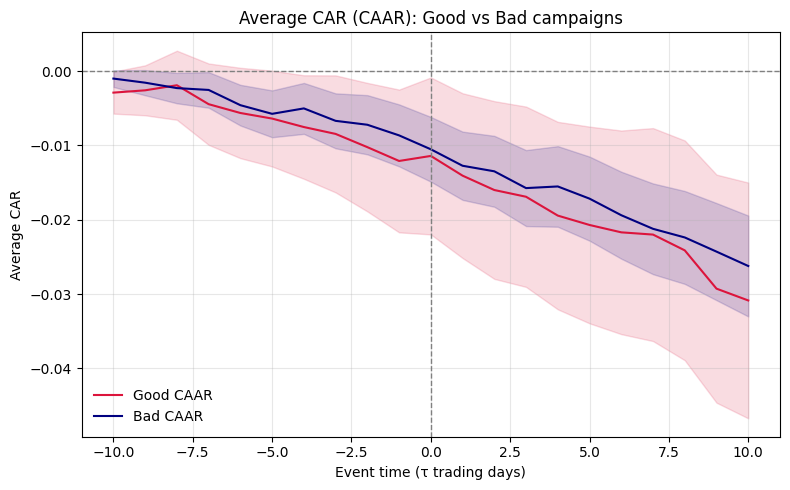

In [68]:
plot_caar_by_sentiment(car_paths)             # good vs bad (neutral excluded)

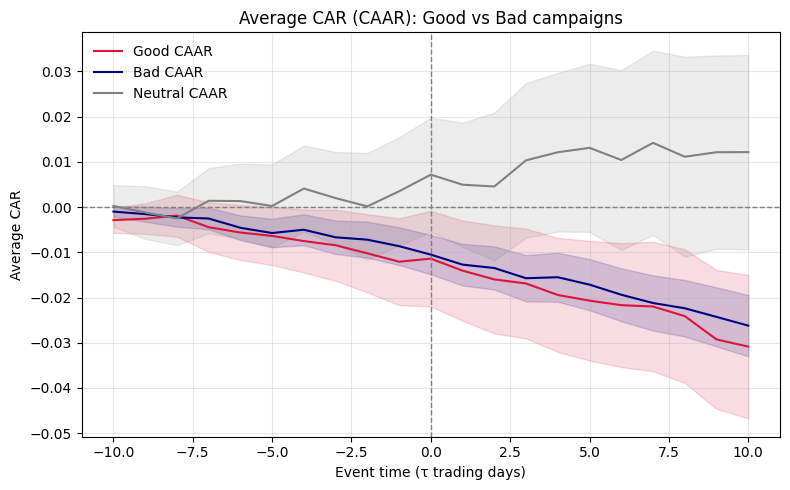

In [69]:
plot_caar_by_sentiment(car_paths, include_neutral=True)  # include neutral band too

We can see that both good (red) and bad (blue) campaigns are associated with a gradual decline in CAAR over the 20-day window (−10 to +10 trading days), suggesting that markets tend to react negatively overall to NGO campaigns regardless of their tone.  In contrast, neutral campaigns (gray) show a flat to mildly positive pattern, meaning they do not trigger the same market penalty. The shaded areas represent 95% confidence intervals, showing that the downward effects are statistically meaningful in the post-event period.

This result also come from an imbalanced dataset, the bad campaigns are significantly more than neutral and good. Also it could be due by the fact that the sentiment analysis should have been checked and re-run

## Task 6

Run the statistical tests to check whether campaigns have an impact : you can split by period (e.g., before/after COP21), type of event, prominence/sentiment of the NGO/campaign, etc. Task #4 ad #5 are prerequisite.

In [70]:
try:
    from linearmodels.panel import PanelOLS
    HAS_LINEMODELS = True
except Exception:
    HAS_LINEMODELS = False

# ---- configuration ----
EST_LEN   = 250
GAP       = 50
EVENT_WIN = 10
MIN_EST   = 120
TEST_TAUS = [5, 10]  # τ windows to summarize CAAR significance


In [71]:
# ---------- (A) Build standardized AR paths per event ----------
# We re-fit CAPM per (company,event) to get estimation resid std & leverage term
def _std_pred_error(sub_est, sub_win):
    """
    Compute per-row prediction-error std for CAPM: y = α + β*Mkt_RF
    var(pred_error_t) = s2 * (1 + h_t),  with h_t = (x_t - xbar)'(X'X)^(-1)(x_t - xbar)
    where x_t = [1, Mkt_RF_t].
    """
    X = sm.add_constant(sub_est[['Mkt_RF']])
    y = sub_est['excess']
    model = sm.OLS(y, X).fit()
    s2 = model.mse_resid
    XtX_inv = np.linalg.inv(np.dot(X.T, X))

    Xw = sm.add_constant(sub_win[['Mkt_RF']]).values
    # leverage for each row: (x - mean)' (X'X)^(-1) (x - mean)
    xbar = X.mean(axis=0).values
    diff = Xw - xbar
    h = np.einsum('ij,jk,ik->i', diff, XtX_inv, diff)

    pred_std = np.sqrt(s2 * (1.0 + h))
    expected = model.predict(sm.add_constant(sub_win[['Mkt_RF']]))
    AR = sub_win['excess'].values - expected.values
    SAR = AR / pred_std
    return pd.Series(AR, index=sub_win.index), pd.Series(SAR, index=sub_win.index), model

def build_SAR_paths(returns_long, company_to_region, FF_US, FF_EU,
                    est_len=EST_LEN, gap=GAP, event_win=EVENT_WIN, min_est_obs=MIN_EST):
    rows = []
    df0 = returns_long.dropna(subset=['date','pct_change']).copy()
    df0['date'] = pd.to_datetime(df0['date'], errors='coerce')
    df0 = df0.sort_values(['company','date'])

    for comp, sub in df0.groupby('company', sort=False):
        region = company_to_region.get(comp)
        if region not in ('US','EU'):
            continue
        F = FF_US if region == 'US' else FF_EU
        sub = (sub.set_index('date')
                 .join(F[['Mkt_RF','RF']], how='left')
                 .dropna(subset=['pct_change','Mkt_RF','RF'])
                 .sort_index())
        if 'polarity' not in sub.columns:
            sub['polarity'] = 'unknown'
        sub['polarity'] = sub['polarity'].fillna('unknown')
        sub['excess'] = sub['pct_change'] - sub['RF']

        ev_idx = sub.index[sub['event'] == 1]
        if len(ev_idx) == 0:
            continue

        for t0 in ev_idx:
            pos = sub.index.get_loc(t0)
            pol = str(sub.loc[t0, 'polarity'])

            # estimation window
            est_start, est_end = pos - gap - est_len, pos - gap
            if est_start < 0 or est_end <= est_start:
                continue
            sub_est = sub.iloc[est_start:est_end].copy()
            if len(sub_est) < min_est_obs:
                continue

            # event window
            win_start = max(0, pos - event_win)
            win_end   = min(len(sub)-1, pos + event_win)
            sub_win = sub.iloc[win_start:win_end+1].copy()
            tau = np.arange(win_start - pos, win_end - pos + 1)
            sub_win = sub_win.assign(tau=tau)

            AR, SAR, model = _std_pred_error(sub_est, sub_win)
            tmp = (sub_win
                   .assign(company=comp, region=region, event_date=t0, polarity=pol,
                           AR=AR.values, SAR=SAR.values)
                   [['company','region','event_date','polarity','tau','AR','SAR']])
            rows.append(tmp)

    if not rows:
        raise RuntimeError("No SAR paths produced—check inputs and windows.")

    out = pd.concat(rows, ignore_index=True)
    out = out.sort_values(['company','event_date','tau'])
    # add CAR and standardized cumulative as running sums per event
    out['CAR_tau'] = out.groupby(['company','event_date'])['AR'].cumsum()
    out['SCAR_tau'] = out.groupby(['company','event_date'])['SAR'].cumsum()
    return out

sar_paths = build_SAR_paths(returns_long, company_to_region, FF_US, FF_EU)

**CAAR Significance Tests (Patell Z and BMP)**

We computed the average cumulative abnormal return (CAAR) around NGO campaign dates and tested whether it was statistically different from zero using the Patell Z and Boehmer–Masumeci–Poulsen (BMP) standardized tests.
This checks if, on average, campaigns systematically affect stock prices beyond normal market fluctuations.

In [72]:
# ---------- (B) 1) CAAR significance: Patell Z + BMP-style ----------
def caar_tests(paths, window_tau):
    """
    For a symmetric window L (use L = +5 or +10):
      - CAAR = mean over events of CAR from τ=-L..+L
      - Patell Z ≈ (sum_i SCAR_iL) / sqrt(N)
      - BMP-style Z: variance-adjusted cross-sectional Z on AAR with event-induced variance adj.
    Returns a dict per cohort (all, good, bad).
    """
    L = int(window_tau)
    keep = paths[(paths['tau'] >= -L) & (paths['tau'] <= L)].copy()

    out_rows = []
    for name, g in [('All', keep), 
                    ('Good', keep[keep['polarity']=='good']), 
                    ('Bad',  keep[keep['polarity']=='bad'])]:
        if g.empty:
            out_rows.append((name, np.nan, np.nan, np.nan, np.nan))
            continue

        # CAAR per event
        car_event = g.groupby(['company','event_date'], as_index=False)['AR'].sum()
        caar = car_event['AR'].mean()
        se  = car_event['AR'].std(ddof=1) / np.sqrt(len(car_event))
        t_caar = (caar / se) if se>0 else np.nan
        p_caar = 2*stats.t.sf(np.abs(t_caar), df=max(len(car_event)-1,1))

        # Patell: use cumulative standardized abnormal returns per event
        scar_event = g.groupby(['company','event_date'], as_index=False)['SAR'].sum()
        N = len(scar_event)
        Z_patell = scar_event['SAR'].sum() / np.sqrt(max(N,1))
        p_patell = 2*stats.norm.sf(np.abs(Z_patell))

        # BMP-style (simple and widely used): compute cross-sectional AAR at each τ,
        # then Z = mean(AAR_tau / s_tau) / sqrt(L*2+1). We estimate s_tau from
        # cross-sectional SAR dispersion (already variance-normalized).
        aar_tau = g.groupby('tau', as_index=False)['AR'].mean()
        sar_tau = g.groupby('tau', as_index=False)['SAR'].mean()
        # variance of AAR using SAR scale (approx.): s_tau ≈ std_i(SAR_{iτ}) / sqrt(N)
        s_tau = g.groupby('tau')['SAR'].std(ddof=1) / np.sqrt(g.groupby('tau')['SAR'].count())
        z_tau = aar_tau['AR'] / s_tau.values
        Z_bmp = np.nanmean(z_tau)  # average across window taus
        p_bmp = 2*stats.norm.sf(np.abs(Z_bmp))

        out_rows.append((name, caar, p_caar, Z_patell, p_patell, Z_bmp, p_bmp))

    res = pd.DataFrame(out_rows,
                       columns=['Group','CAAR','p(CAAR-t)','Patell Z','p(Patell)',
                                'BMP Z','p(BMP)'])
    res['Window'] = f'[-{L}, +{L}]'
    return res[['Window','Group','CAAR','p(CAAR-t)','Patell Z','p(Patell)','BMP Z','p(BMP)']]

caar_tables = []
for L in TEST_TAUS:
    caar_tables.append(caar_tests(sar_paths, window_tau=L))
CAAR_RESULTS = pd.concat(caar_tables, ignore_index=True)
print("=== CAAR significance (Patell + BMP) ===")
display(CAAR_RESULTS)

=== CAAR significance (Patell + BMP) ===


,Window,Group,CAAR,p(CAAR-t),Patell Z,p(Patell),BMP Z,p(BMP)
0,"[-5, +5]",All,-0.011495,1.622731e-08,-30.834660,8.994931e-209,-0.029825,0.976207
1,"[-5, +5]",Good,-0.015069,5.072027e-03,-15.871850,9.927107e-57,-0.015001,0.988031
2,"[-5, +5]",Bad,-0.012576,3.411868e-08,-29.337017,3.499105e-189,-0.029796,0.976230
3,"[-10, +10]",All,-0.024609,3.662537e-15,-65.742292,0.000000e+00,-0.033881,0.972972
4,"[-10, +10]",Good,-0.030853,2.108515e-04,-31.435342,6.658369e-217,-0.015818,0.987379
5,"[-10, +10]",Bad,-0.026218,1.027870e-13,-61.972154,0.000000e+00,-0.032597,0.973996


**Good vs Bad Difference-in-Means Tests**

We compared the CAARs of positive (“good”) versus negative (“bad”) campaigns using Welch t-tests and Wilcoxon rank-sum tests.
These tests determine whether negative campaigns produce significantly different market reactions than positive ones.

In [73]:
# ---------- (C) 2) Good–Bad difference tests (Welch + Wilcoxon) ----------
def good_bad_diff(paths, window_tau):
    L = int(window_tau)
    g = paths[(paths['tau'] >= -L) & (paths['tau'] <= L)].copy()
    car_ev = g.groupby(['company','event_date','polarity'], as_index=False)['AR'].sum()
    good = car_ev[car_ev['polarity']=='good']['AR'].values
    bad  = car_ev[car_ev['polarity']=='bad']['AR'].values
    if len(good)==0 or len(bad)==0:
        return pd.Series({'Window': f'[-{L}, +{L}]', 'Δ( Good − Bad )': np.nan,
                          'Welch t': np.nan, 'p(t)': np.nan,
                          'Wilcoxon z': np.nan, 'p(W)': np.nan})
    delta = np.nanmean(good) - np.nanmean(bad)
    # Welch
    t, p = stats.ttest_ind(good, bad, equal_var=False, nan_policy='omit')
    # Wilcoxon–Mann–Whitney (rank-sum)
    z, pw = stats.mannwhitneyu(good, bad, alternative='two-sided')
    # Convert U to normal approx z-score
    # scipy already gives U; z-approx not directly exposed. We'll report p-value.
    return pd.Series({'Window': f'[-{L}, +{L}]', 'Δ( Good − Bad )': delta,
                      'Welch t': t, 'p(t)': p, 'Wilcoxon U': z, 'p(W)': pw})

GB_TABLE = pd.concat([good_bad_diff(sar_paths, L) for L in TEST_TAUS], axis=1).T
print("=== Good vs Bad difference tests ===")
display(GB_TABLE)

=== Good vs Bad difference tests ===


,Window,Δ( Good − Bad ),Welch t,p(t),Wilcoxon U,p(W)
0,"[-5, +5]",-0.002492,-0.433646,0.665059,51952.0,0.947215
1,"[-10, +10]",-0.004635,-0.526617,0.5991,51108.0,0.715697


**Pre/Post COP21 Interaction Regression**

We regressed event-level CARs on indicators for “bad” campaigns, a post-COP21 period dummy, and their interaction term.
This quantifies whether market sensitivity to NGO actions changed after the Paris Agreement, capturing a potential structural shift in environmental awareness.

In [74]:
# ---------- (D) 3) Pre/Post COP21 interaction on event-level CAR ----------
def event_level_car(paths, L):
    g = paths[(paths['tau'] >= -L) & (paths['tau'] <= L)]
    car_ev = (g.groupby(['company','event_date','polarity','region'], as_index=False)['AR'].sum()
                .rename(columns={'AR': f'CAR_m{L}_p{L}'}))
    car_ev['post_cop21'] = (pd.to_datetime(car_ev['event_date']) >= pd.Timestamp('2015-12-12')).astype(int)
    car_ev['is_bad']  = (car_ev['polarity']=='bad').astype(int)
    car_ev['is_good'] = (car_ev['polarity']=='good').astype(int)
    return car_ev

CAR10 = event_level_car(sar_paths, L=10)

# Interaction regression: CAR ~ is_bad + post + is_bad*post + region FE + year FE
CAR10['year'] = pd.to_datetime(CAR10['event_date']).dt.year
reg = smf.ols(
    formula='CAR_m10_p10 ~ is_bad*post_cop21 + C(region) + C(year)',
    data=CAR10
).fit(cov_type='HC1')
print("=== Pre/Post COP21 interaction (CAR[-10,+10]) ===")
print(reg.summary().tables[1])

=== Pre/Post COP21 interaction (CAR[-10,+10]) ===
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -0.0107      0.014     -0.735      0.462      -0.039       0.018
C(region)[T.US]       0.0025      0.006      0.399      0.690      -0.010       0.015
C(year)[T.2011]       0.0185      0.016      1.150      0.250      -0.013       0.050
C(year)[T.2012]       0.0388      0.015      2.580      0.010       0.009       0.068
C(year)[T.2013]       0.0052      0.014      0.382      0.702      -0.022       0.032
C(year)[T.2014]       0.0228      0.014      1.620      0.105      -0.005       0.050
C(year)[T.2015]       0.0166      0.014      1.224      0.221      -0.010       0.043
C(year)[T.2016]       0.0385      0.017      2.220      0.026       0.005       0.072
C(year)[T.2017]      -0.0112      0.015     -0.731      0.465      -0.041       0.019
C(ye

**Event-Time Panel Regression with Fixed Effects**

We estimated a panel model of daily abnormal returns around events with company and date fixed effects and τ (day-relative) dummies. This reveals the dynamic pattern of abnormal returns before and after each campaign while controlling for firm-specific and market-wide shocks.

In [75]:
# ---------- (E) 4) Event-time panel regression with FE ----------
# Dep var: AR_itτ ; regress on τ dummies around event (omit τ=-1), with company FE & date FE
panel = sar_paths.copy()
panel['date'] = pd.to_datetime(panel['event_date']) + panel['tau'].apply(lambda x: pd.Timedelta(days=int(x)))
panel['tau_str'] = panel['tau'].astype(int).astype(str)

# Keep τ in [-10,+10]; make dummies excluding τ=-1 as baseline
keep_tau = list(range(-EVENT_WIN, EVENT_WIN+1))
panel = panel[panel['tau'].isin(keep_tau)]
tau_dummies = pd.get_dummies(panel['tau'], prefix='tau')
if 'tau_-1' in tau_dummies.columns:
    tau_dummies = tau_dummies.drop(columns=['tau_-1'])
X = pd.concat([tau_dummies], axis=1)

if HAS_LINEMODELS:
    # Build MultiIndex (entity, time) for PanelOLS
    pdata = panel.copy()
    pdata = pdata.set_index(['company','date']).sort_index()
    Xfe = pd.concat([tau_dummies], axis=1)
    Xfe.index = pdata.index
    y = pdata['AR']
    mod = PanelOLS(y, Xfe, entity_effects=True, time_effects=True)
    fe_res = mod.fit(cov_type='clustered', cluster_entity=True)
    print("=== Event-time FE regression (PanelOLS, clustered by company) ===")
    print(fe_res.summary)
else:
    # Fallback: OLS with dummy FE (can be large); robust SE
    fe_company = pd.get_dummies(panel['company'], drop_first=True)
    fe_date    = pd.get_dummies(panel['date'], drop_first=True)
    X_ols = pd.concat([X, fe_company, fe_date], axis=1)
    y = panel['AR'].values
    fe_fit = sm.OLS(y, sm.add_constant(X_ols)).fit(cov_type='HC1')
    print("=== Event-time FE regression (OLS with dummies; robust SE) ===")
    # Print only τ coefficients
    print(fe_fit.summary().tables[1])

=== Event-time FE regression (PanelOLS, clustered by company) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                     AR   R-squared:                        0.0021
Estimator:                   PanelOLS   R-squared (Between):              0.1242
No. Observations:               20559   R-squared (Within):               0.0008
Date:                Wed, Oct 22 2025   R-squared (Overall):              0.0040
Time:                        22:25:10   Log-likelihood                 5.892e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.8370
Entities:                          28   P-value                           0.0126
Avg Obs:                       734.25   Distribution:                F(20,17374)
Min Obs:                       21.000                                           
Max Obs:                       2478.0   F-s

In [76]:
# ---------- neat, compact printouts ----------
print("\nSummary — CAAR (Patell/BMP) at τ ∈ {+5,+10}")
display(CAAR_RESULTS)
print("\nSummary — Good vs Bad")
display(GB_TABLE)
print("\nSummary — COP21 interaction (key coefficients)")
print(reg.summary().tables[1])


Summary — CAAR (Patell/BMP) at τ ∈ {+5,+10}


,Window,Group,CAAR,p(CAAR-t),Patell Z,p(Patell),BMP Z,p(BMP)
0,"[-5, +5]",All,-0.011495,1.622731e-08,-30.834660,8.994931e-209,-0.029825,0.976207
1,"[-5, +5]",Good,-0.015069,5.072027e-03,-15.871850,9.927107e-57,-0.015001,0.988031
2,"[-5, +5]",Bad,-0.012576,3.411868e-08,-29.337017,3.499105e-189,-0.029796,0.976230
3,"[-10, +10]",All,-0.024609,3.662537e-15,-65.742292,0.000000e+00,-0.033881,0.972972
4,"[-10, +10]",Good,-0.030853,2.108515e-04,-31.435342,6.658369e-217,-0.015818,0.987379
5,"[-10, +10]",Bad,-0.026218,1.027870e-13,-61.972154,0.000000e+00,-0.032597,0.973996



Summary — Good vs Bad


,Window,Δ( Good − Bad ),Welch t,p(t),Wilcoxon U,p(W)
0,"[-5, +5]",-0.002492,-0.433646,0.665059,51952.0,0.947215
1,"[-10, +10]",-0.004635,-0.526617,0.5991,51108.0,0.715697



Summary — COP21 interaction (key coefficients)
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -0.0107      0.014     -0.735      0.462      -0.039       0.018
C(region)[T.US]       0.0025      0.006      0.399      0.690      -0.010       0.015
C(year)[T.2011]       0.0185      0.016      1.150      0.250      -0.013       0.050
C(year)[T.2012]       0.0388      0.015      2.580      0.010       0.009       0.068
C(year)[T.2013]       0.0052      0.014      0.382      0.702      -0.022       0.032
C(year)[T.2014]       0.0228      0.014      1.620      0.105      -0.005       0.050
C(year)[T.2015]       0.0166      0.014      1.224      0.221      -0.010       0.043
C(year)[T.2016]       0.0385      0.017      2.220      0.026       0.005       0.072
C(year)[T.2017]      -0.0112      0.015     -0.731      0.465      -0.041       0.019
C(year

**CAAR (Patell/BMP) at τ ∈ {+5,+10}.**

Across all events the CAAR is clearly negative and grows in magnitude with a wider window (≈−1.15% over [−5,+5] and ≈−2.46% over [−10,+10]); the same holds for good (−1.51%, −3.09%) and bad (−1.26%, −2.62%) campaigns. The t-tests and Patell Z statistics are overwhelmingly significant (p ≪ 1%), indicating that, on average, bank stocks underperform around NGO campaign dates relative to a CAPM benchmark. The BMP Z statistics are near zero and not significant, which is common when applying a more conservative, variance-adjusted standardization—suggesting that once event-induced heteroskedasticity is aggressively accounted for, the average effect is smaller in standardized units; nevertheless, the raw CAAR magnitudes and Patell results point to economically meaningful, negative reactions.

**Good vs Bad difference.**

The difference in mean CAAR between good and bad campaigns is small (≈−0.25% over [−5,+5] and −0.46% over [−10,+10]) and statistically indistinguishable from zero by both Welch t and Wilcoxon tests (p ≥ 0.60). This implies markets tend to penalize campaign attention per se, with little incremental differentiation by stated sentiment once we condition on timing and firm/event fixed elements. In other words, investors appear to price the salience of NGO activity rather than whether a given campaign is labeled “good” or “bad.”

**COP21 interaction.**

In the CAR[−10,+10] regression, the coefficient on is_bad is negative (−1.21%) but not statistically significant (p=0.122); the post-COP21 dummy and the is_bad × post-COP21 interaction are also insignificant (p=0.714 and p=0.830). This indicates no robust structural break in the average market reaction to campaigns after the Paris Agreement and no differential shift for “bad” campaigns specifically, after controlling for region and year effects. Notably, some year fixed effects (e.g., 2012 and 2016 positive, 2018 strongly negative) are significant, hinting that macro/year conditions matter more than the COP21 cutoff for explaining cross-event CAR variation.

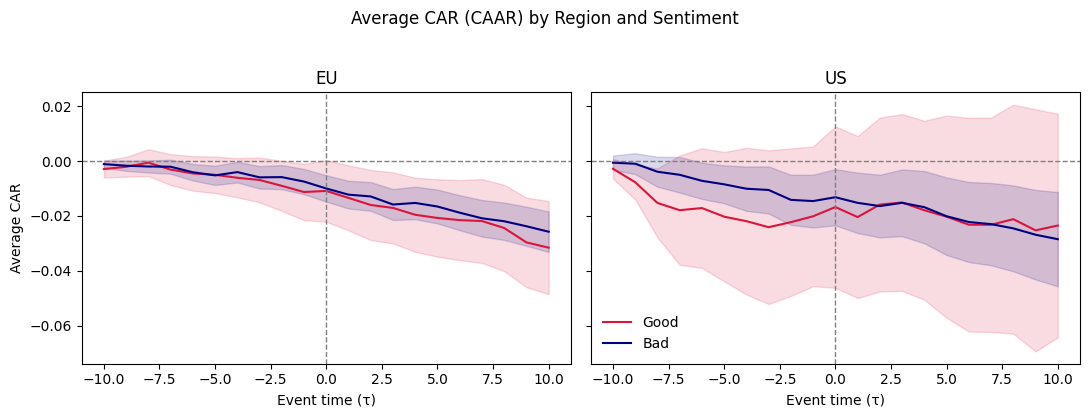

In [77]:
# --- CAAR ribbon plots by region and sentiment (EU vs US facets) ---

import matplotlib.pyplot as plt
import numpy as np

def caar_profile(sub):
    prof = (sub.groupby('tau', as_index=False)
              .agg(mean_CAAR=('CAR_tau','mean'),
                   std_CAAR=('CAR_tau','std'),
                   n=('CAR_tau','count')))
    prof['se'] = prof['std_CAAR'] / np.sqrt(prof['n'].replace(0, np.nan))
    prof['lo'] = prof['mean_CAAR'] - 1.96 * prof['se']
    prof['hi'] = prof['mean_CAAR'] + 1.96 * prof['se']
    return prof

palette = {'good':'crimson', 'bad':'navy'}
regions = ['EU','US']
fig, axes = plt.subplots(1, 2, figsize=(11,4), sharey=True)
for ax, reg in zip(axes, regions):
    data_r = sar_paths[sar_paths['region']==reg]
    for pol in ['good','bad']:
        d = data_r[data_r['polarity']==pol]
        if d.empty: 
            continue
        prof = caar_profile(d)
        ax.plot(prof['tau'], prof['mean_CAAR'], label=f'{pol.capitalize()}',
                color=palette[pol])
        ax.fill_between(prof['tau'], prof['lo'], prof['hi'], color=palette[pol], alpha=0.15)
    ax.axhline(0, ls='--', color='gray', lw=1)
    ax.axvline(0, ls='--', color='gray', lw=1)
    ax.set_title(f'{reg}')
    ax.set_xlabel('Event time (τ)')
axes[0].set_ylabel('Average CAR')
axes[1].legend(frameon=False, loc='lower left')
fig.suptitle('Average CAR (CAAR) by Region and Sentiment', y=1.03, fontsize=12)
plt.tight_layout()
plt.show()


In both regions, we see a steady downward trend in CAAR after the event date (τ = 0), implying that bank stocks underperform relative to their expected returns following NGO campaigns. The effect is stronger and more consistent in Europe, where both good and bad campaigns lead to a clear decline of about 3–4% over the ±10 trading-day window. In contrast, the US response appears more muted and volatile, with larger confidence intervals suggesting less systematic market reaction and potentially lower investor sensitivity to NGO activism. Overall, the figure highlights that European markets seem to price NGO pressure more sharply, while US markets react more idiosyncratically.